# 把单日INP浓度放到更长的时间序列中

## 先确定每天各种温度的INP浓度只会测量一次吗?

以2025年1月为例

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

27


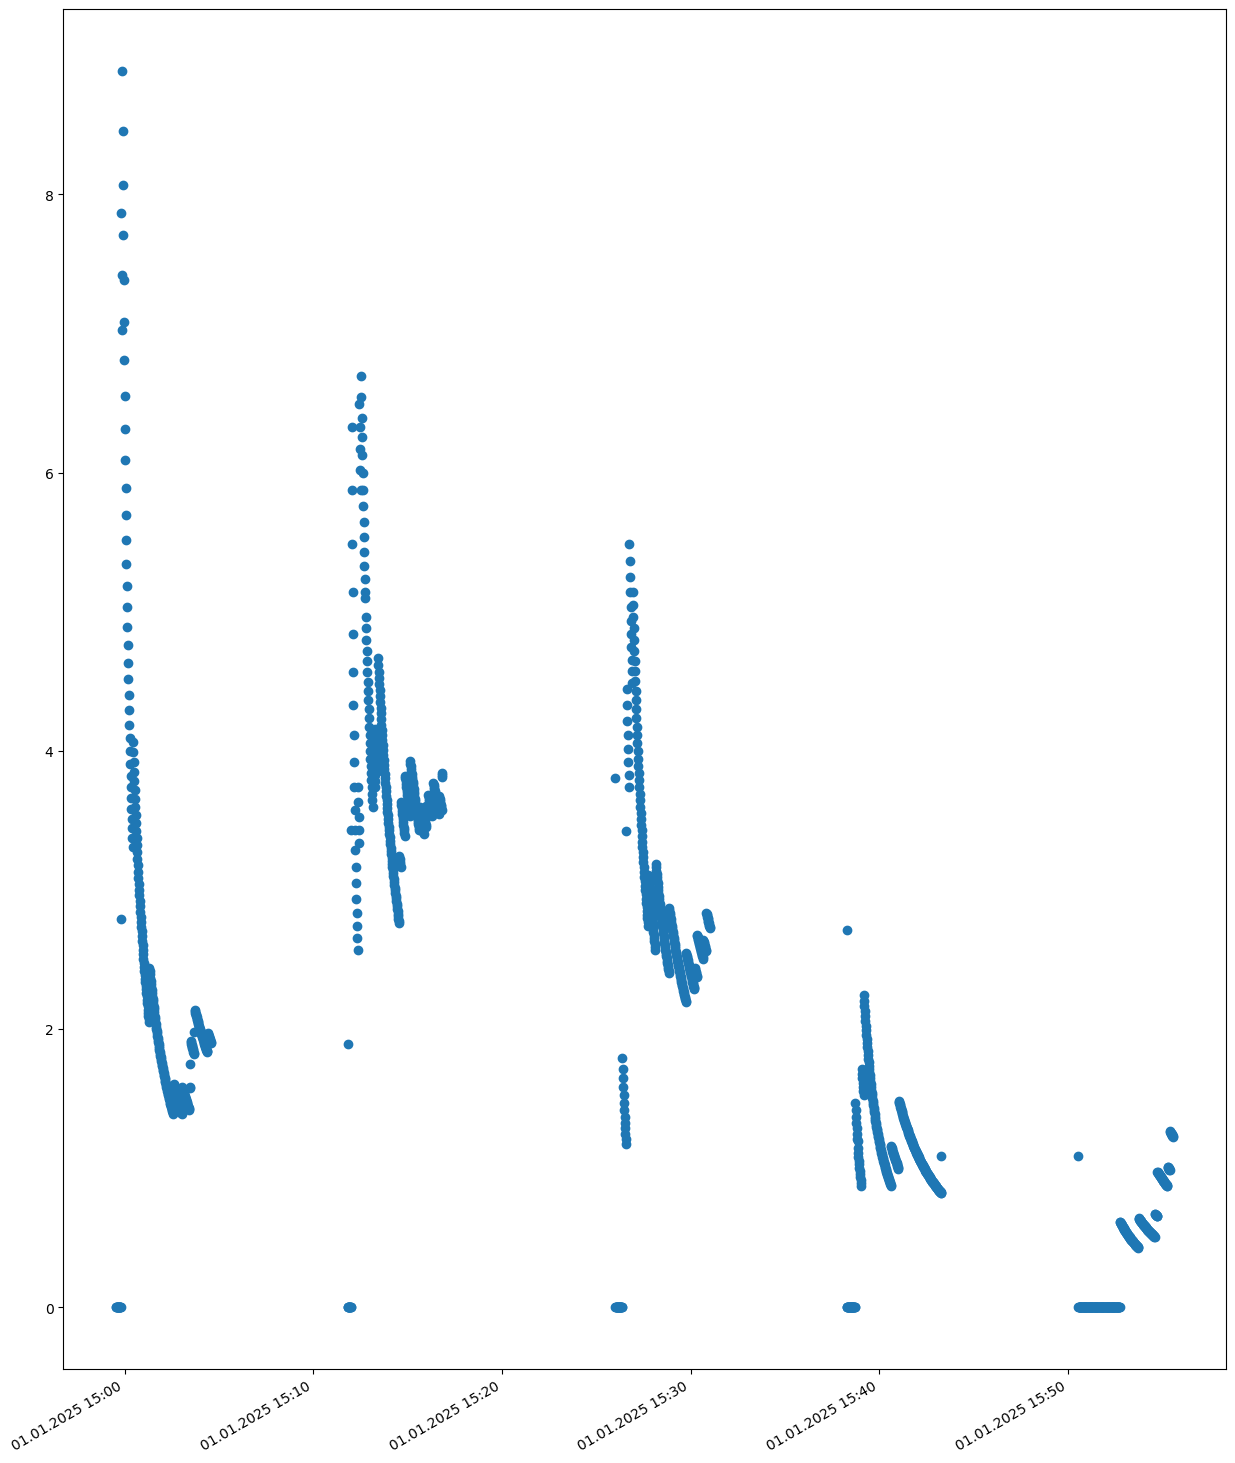

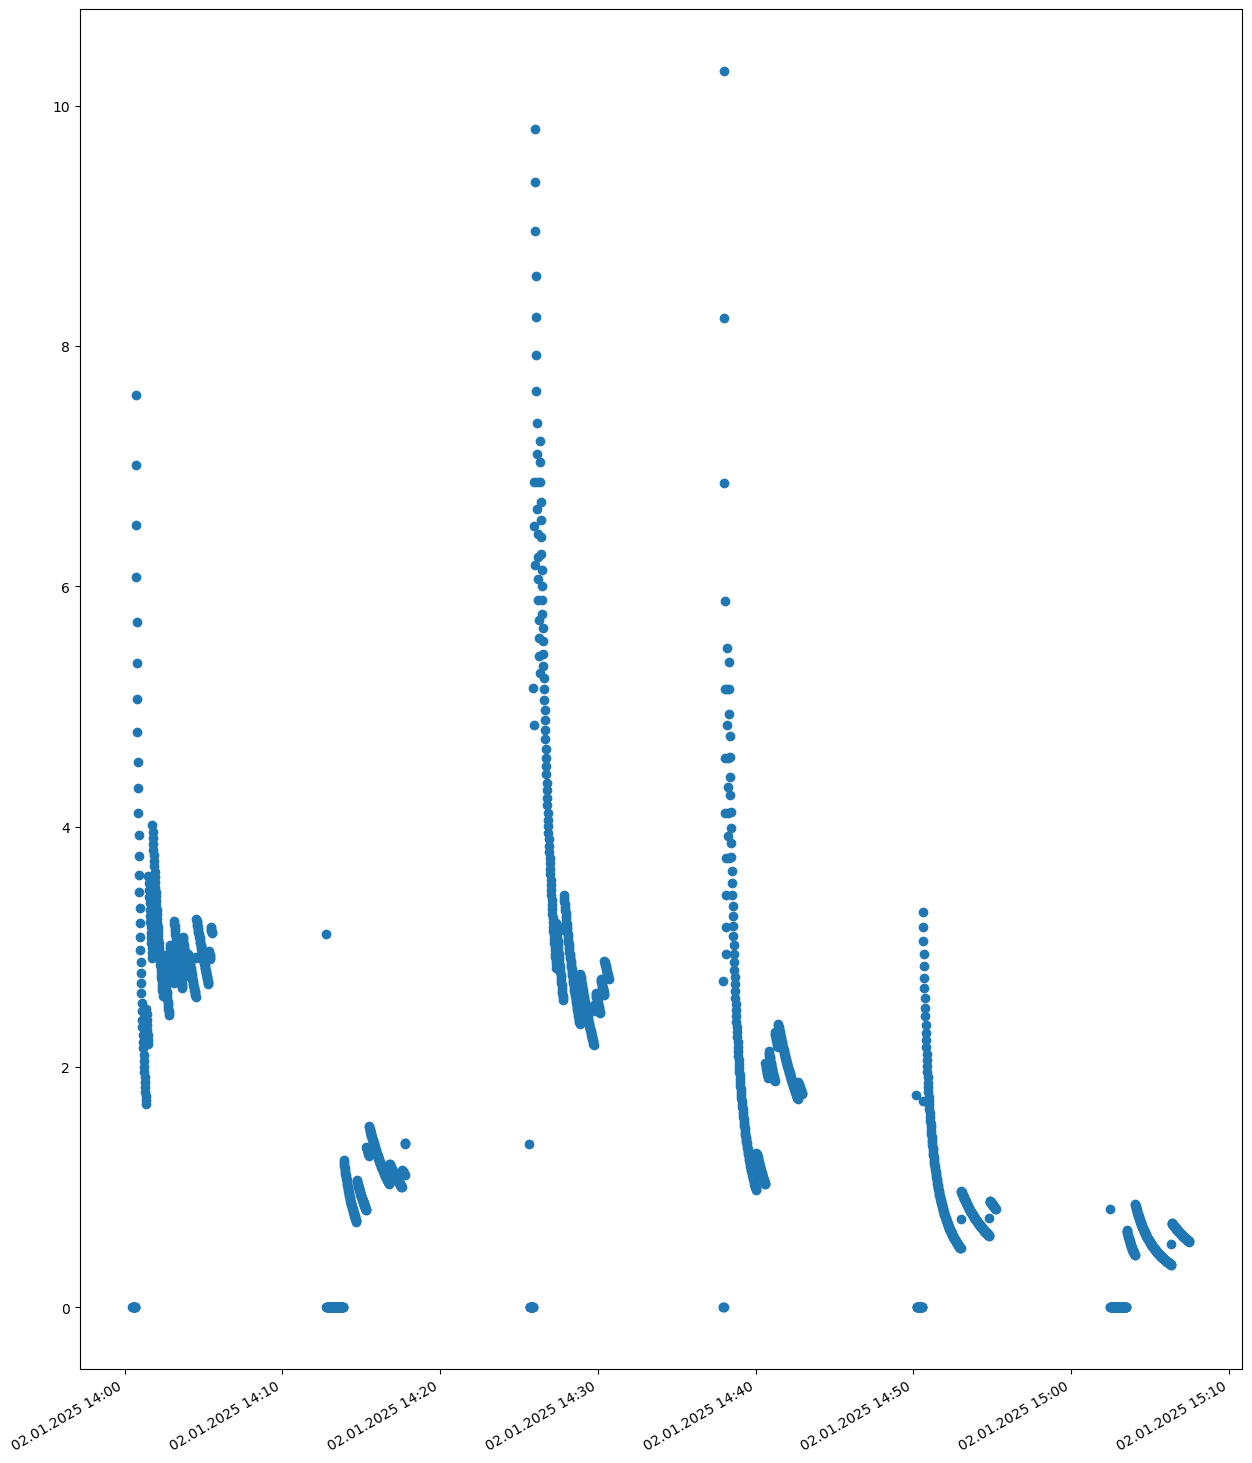

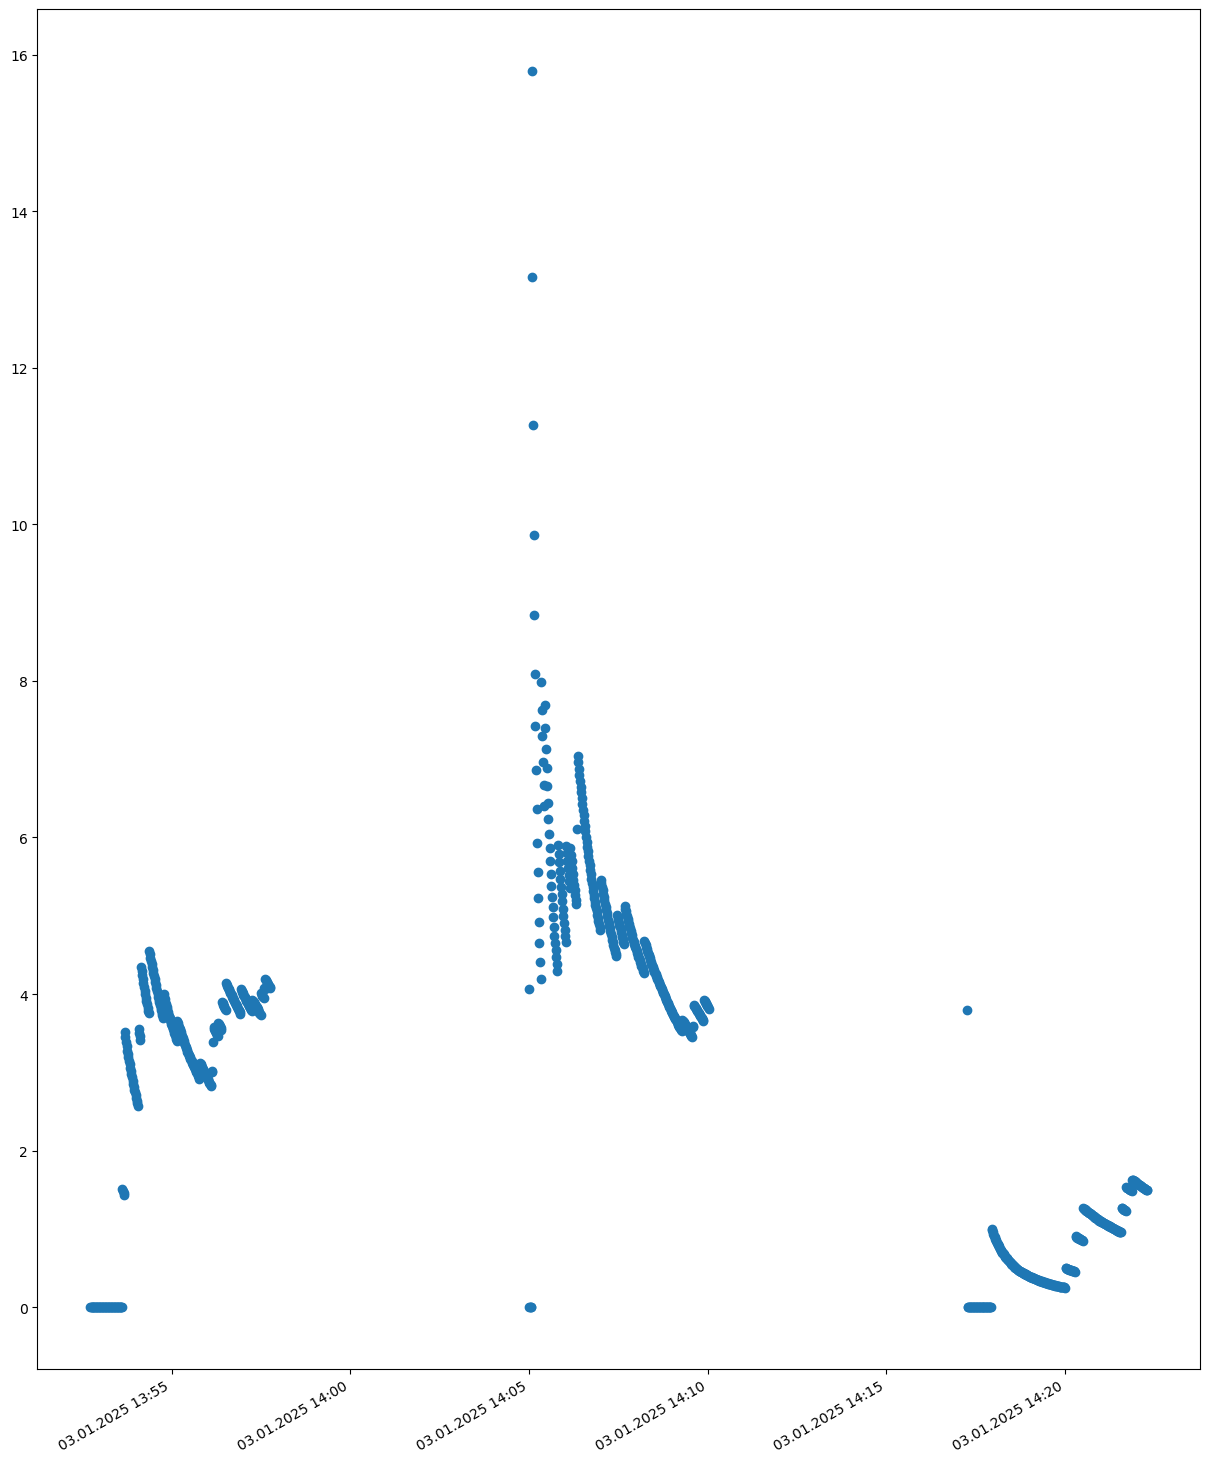

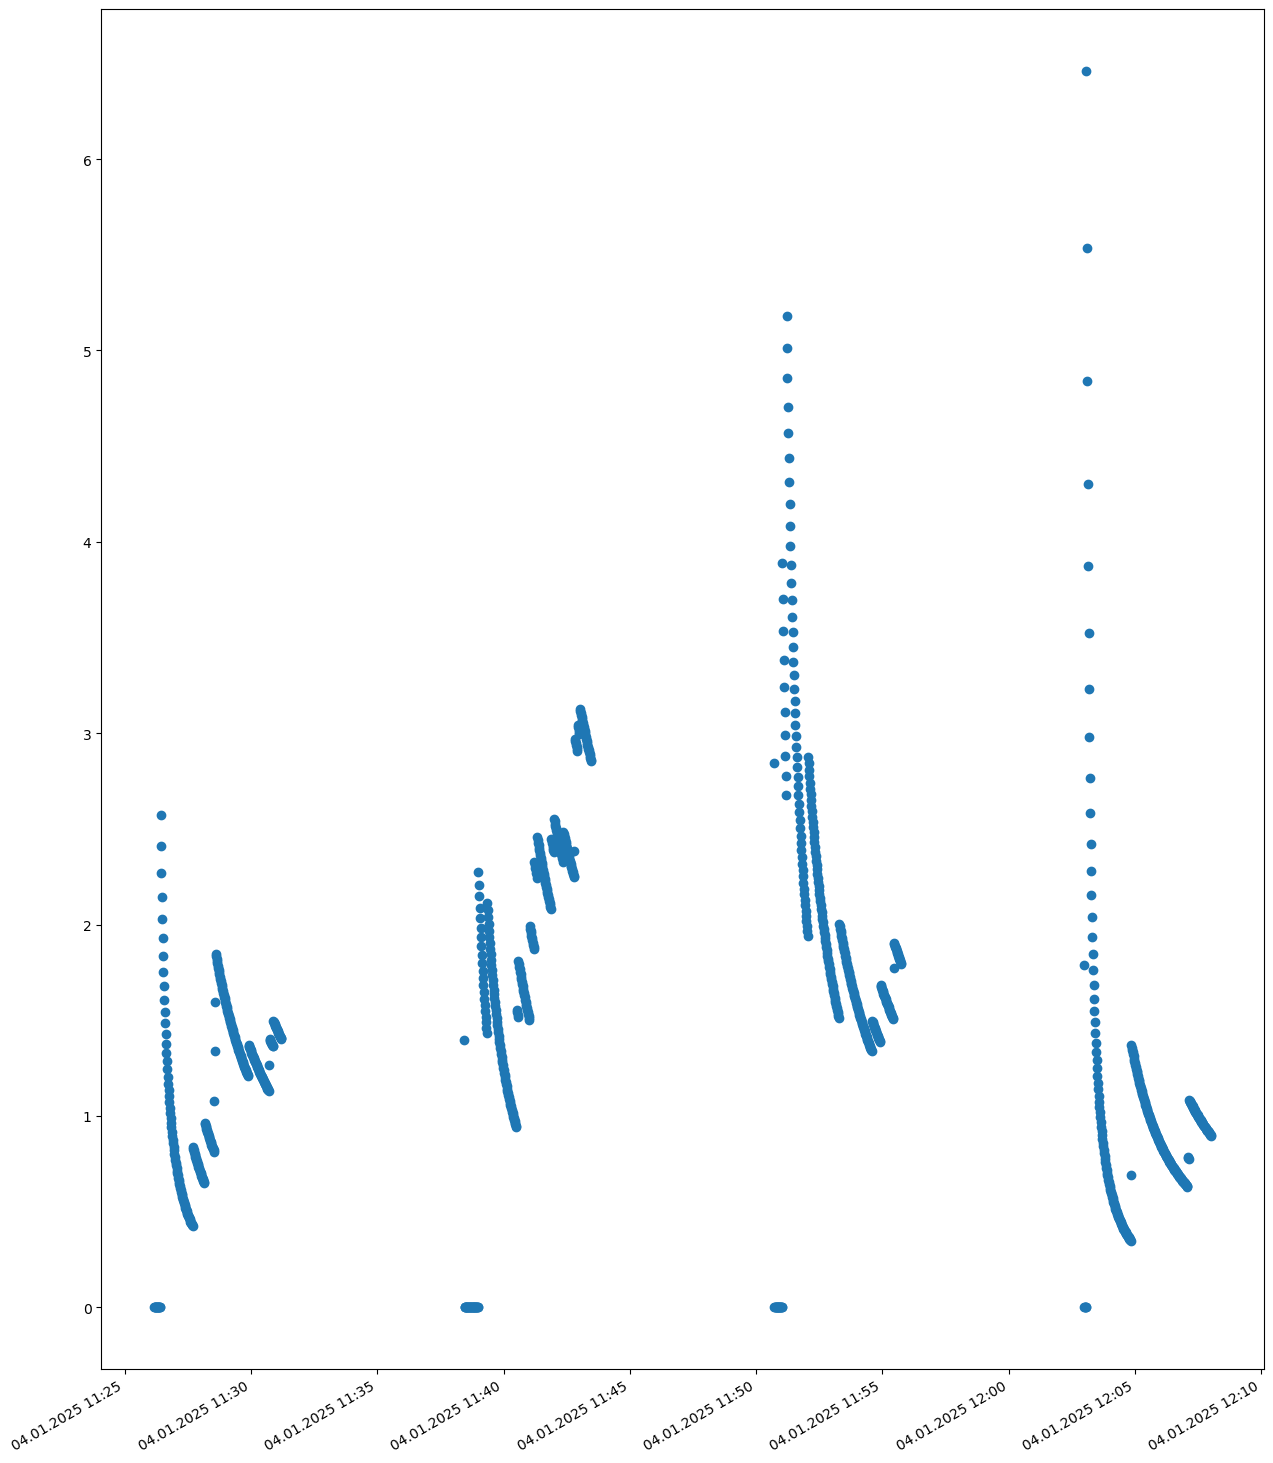

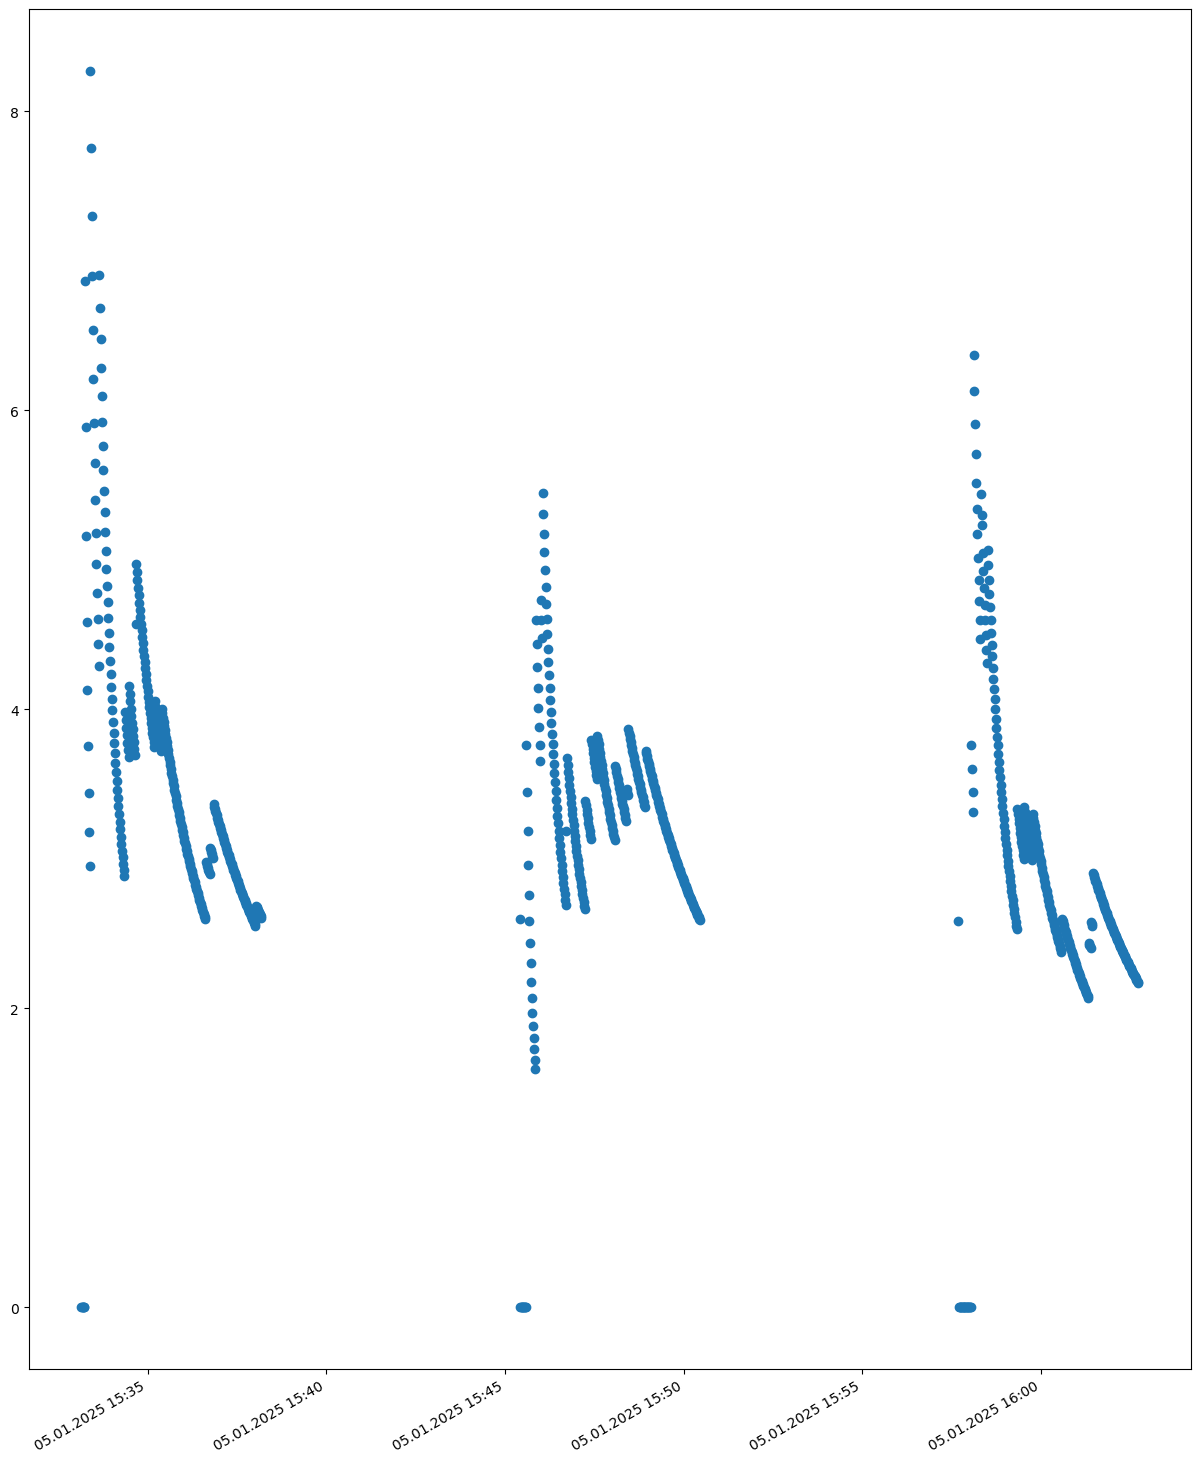

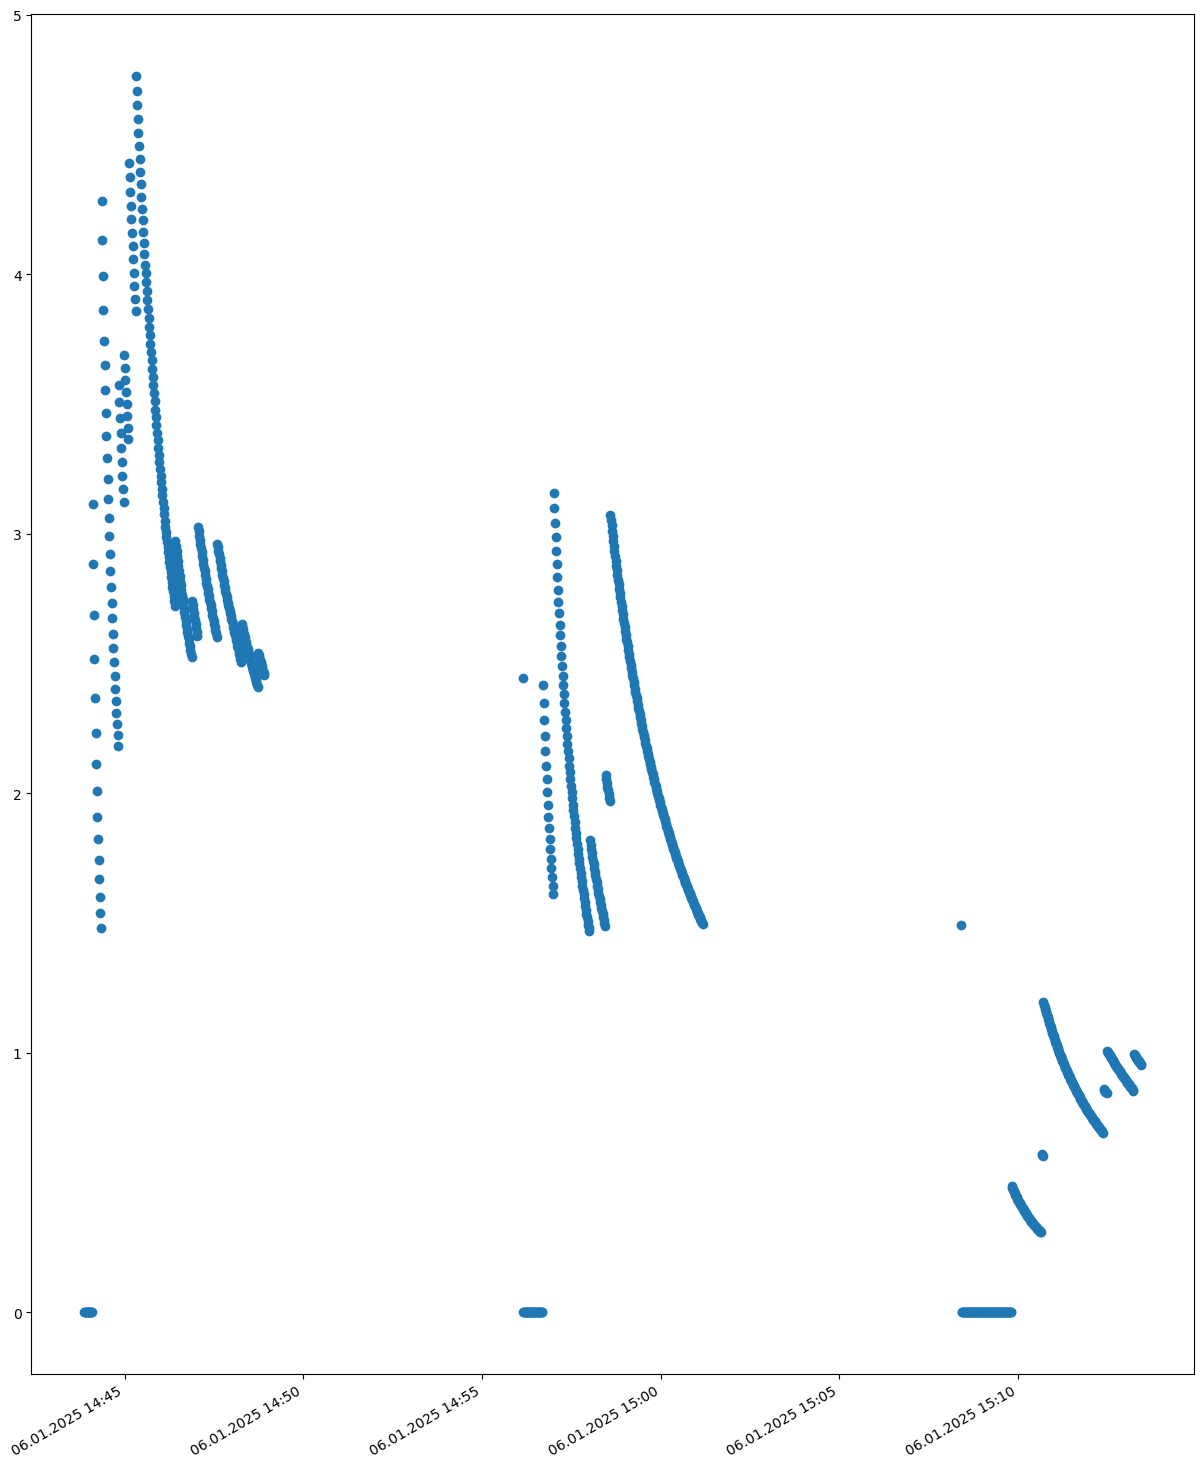

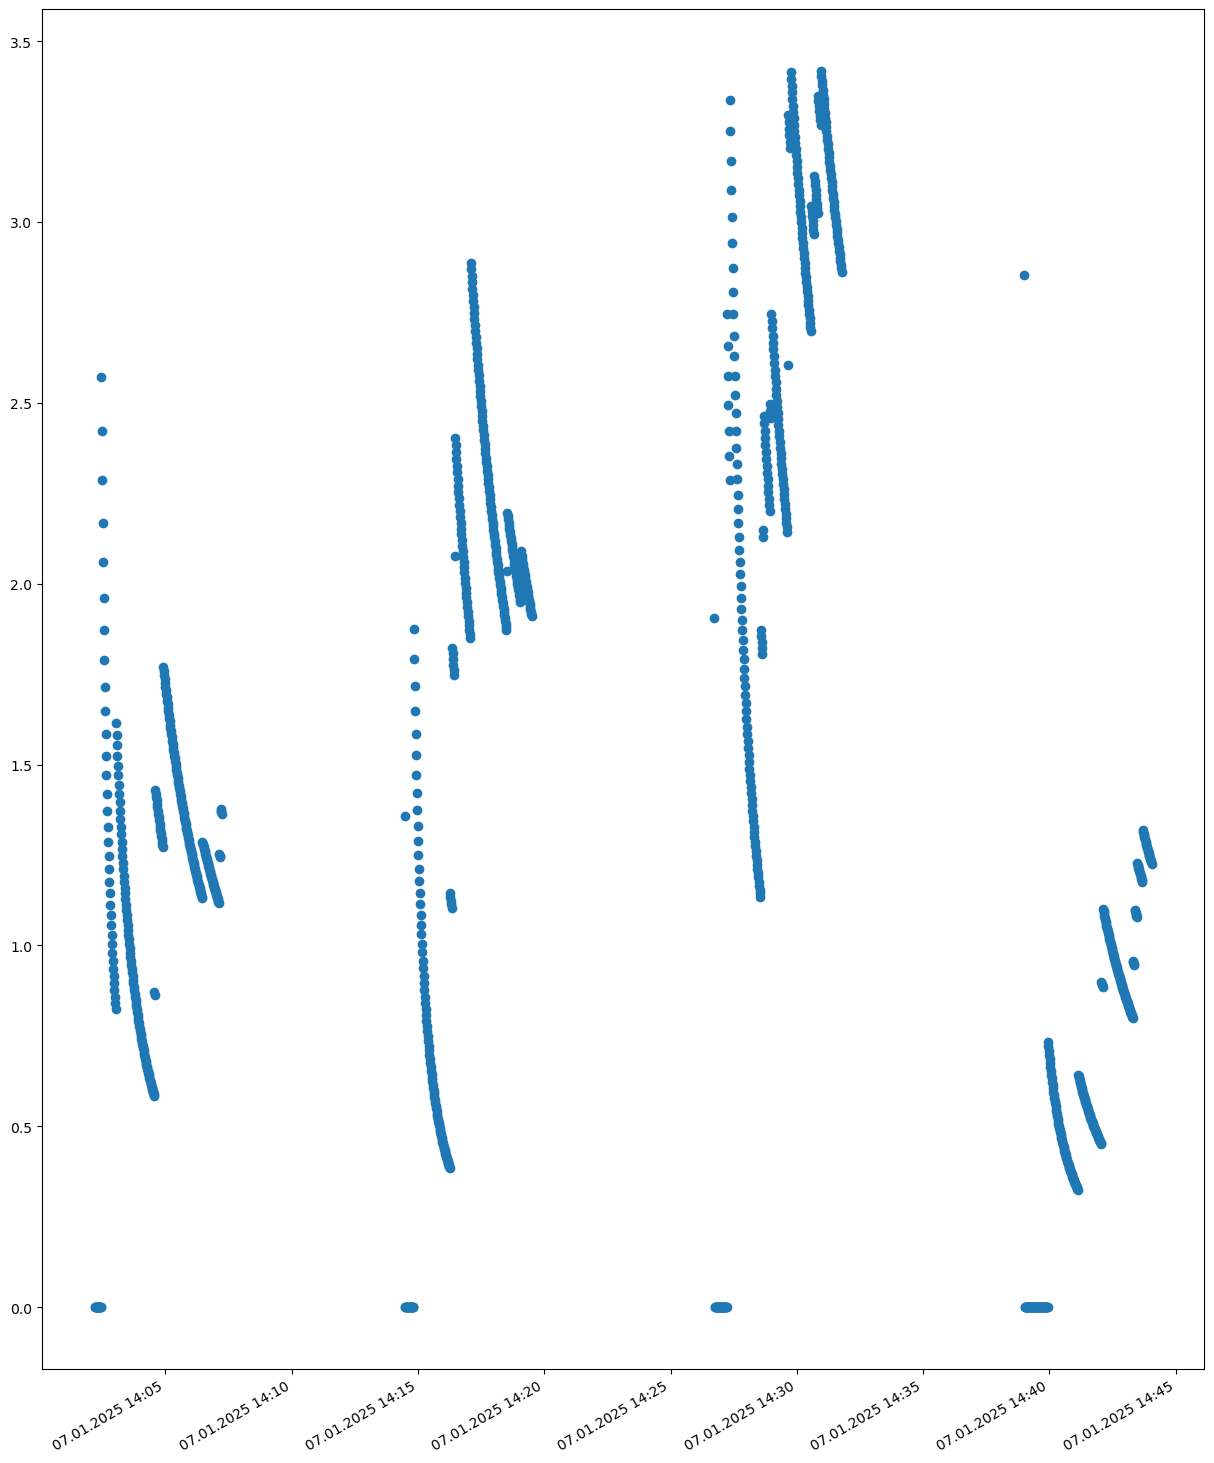

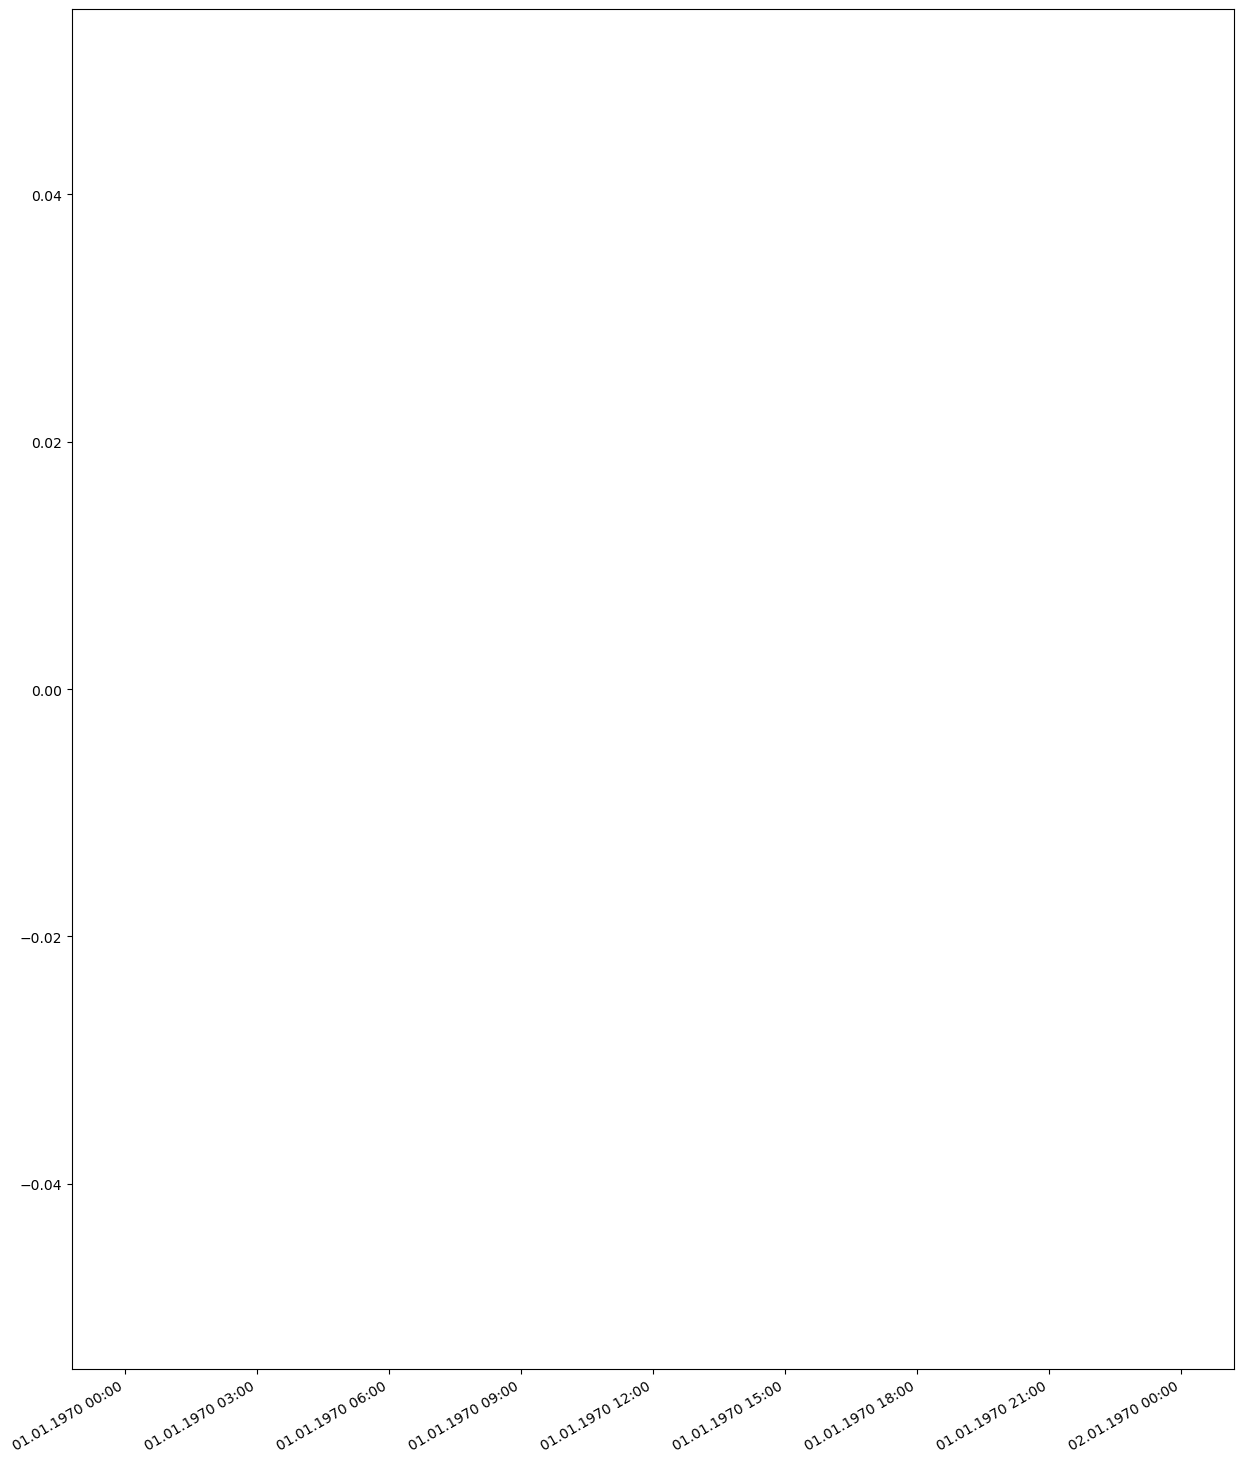

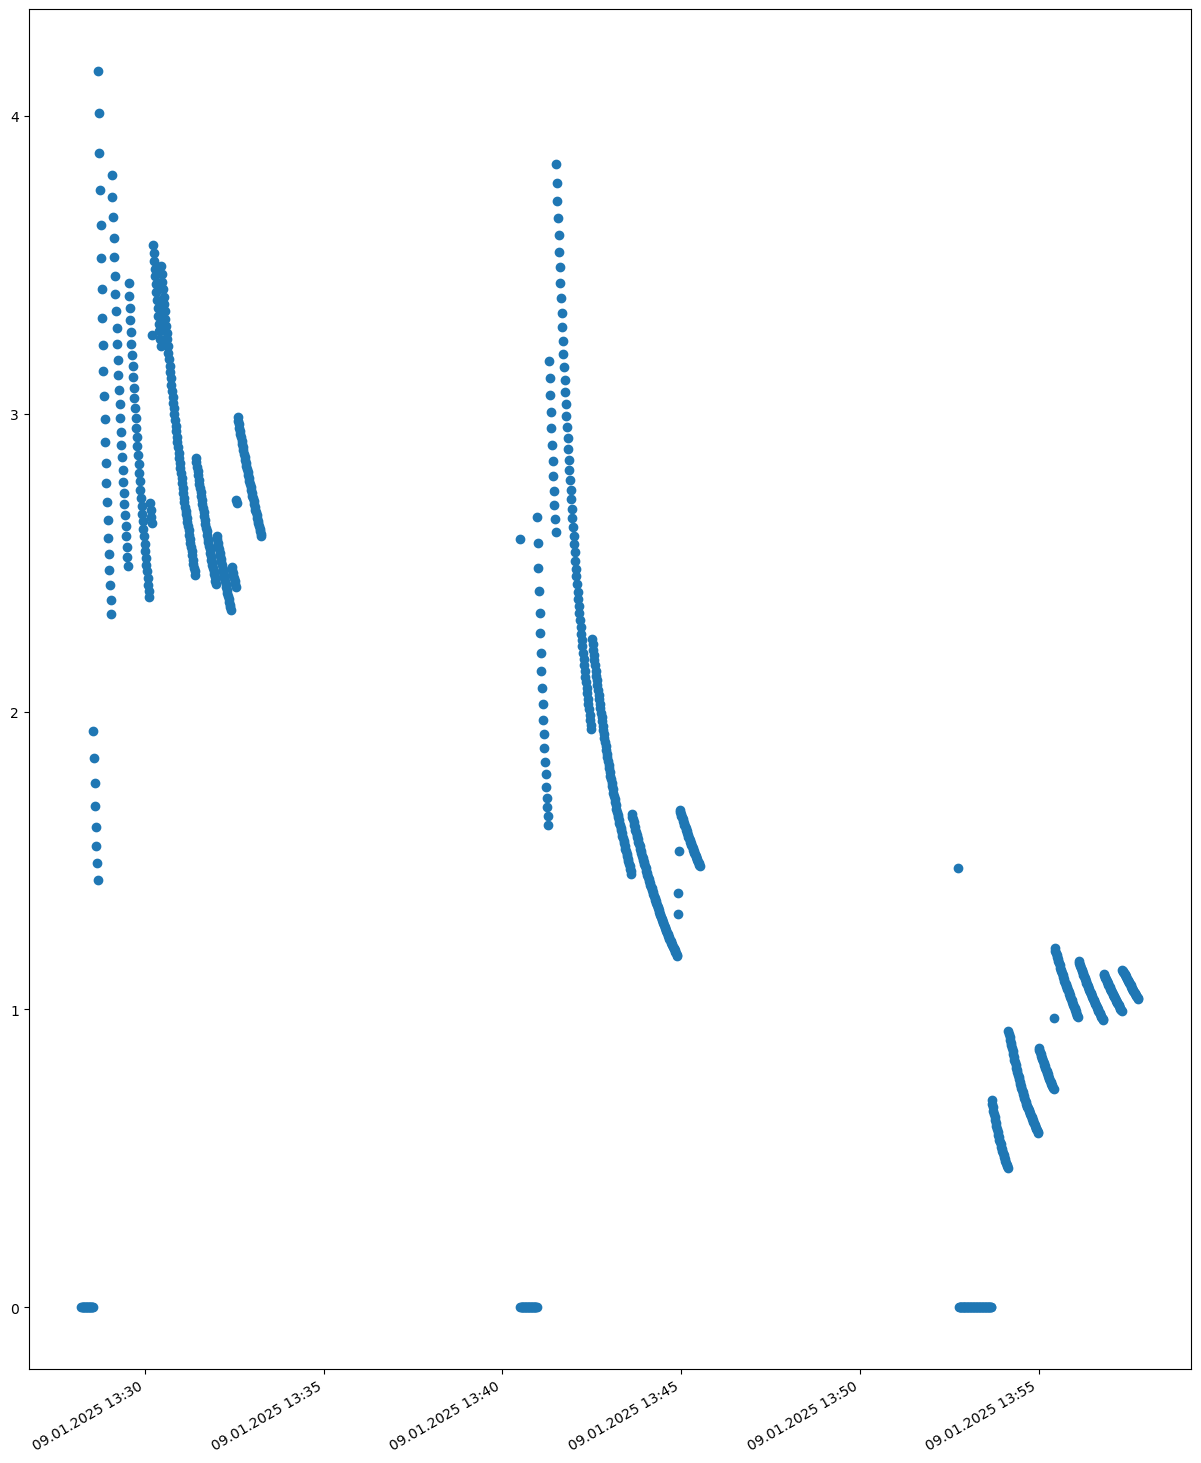

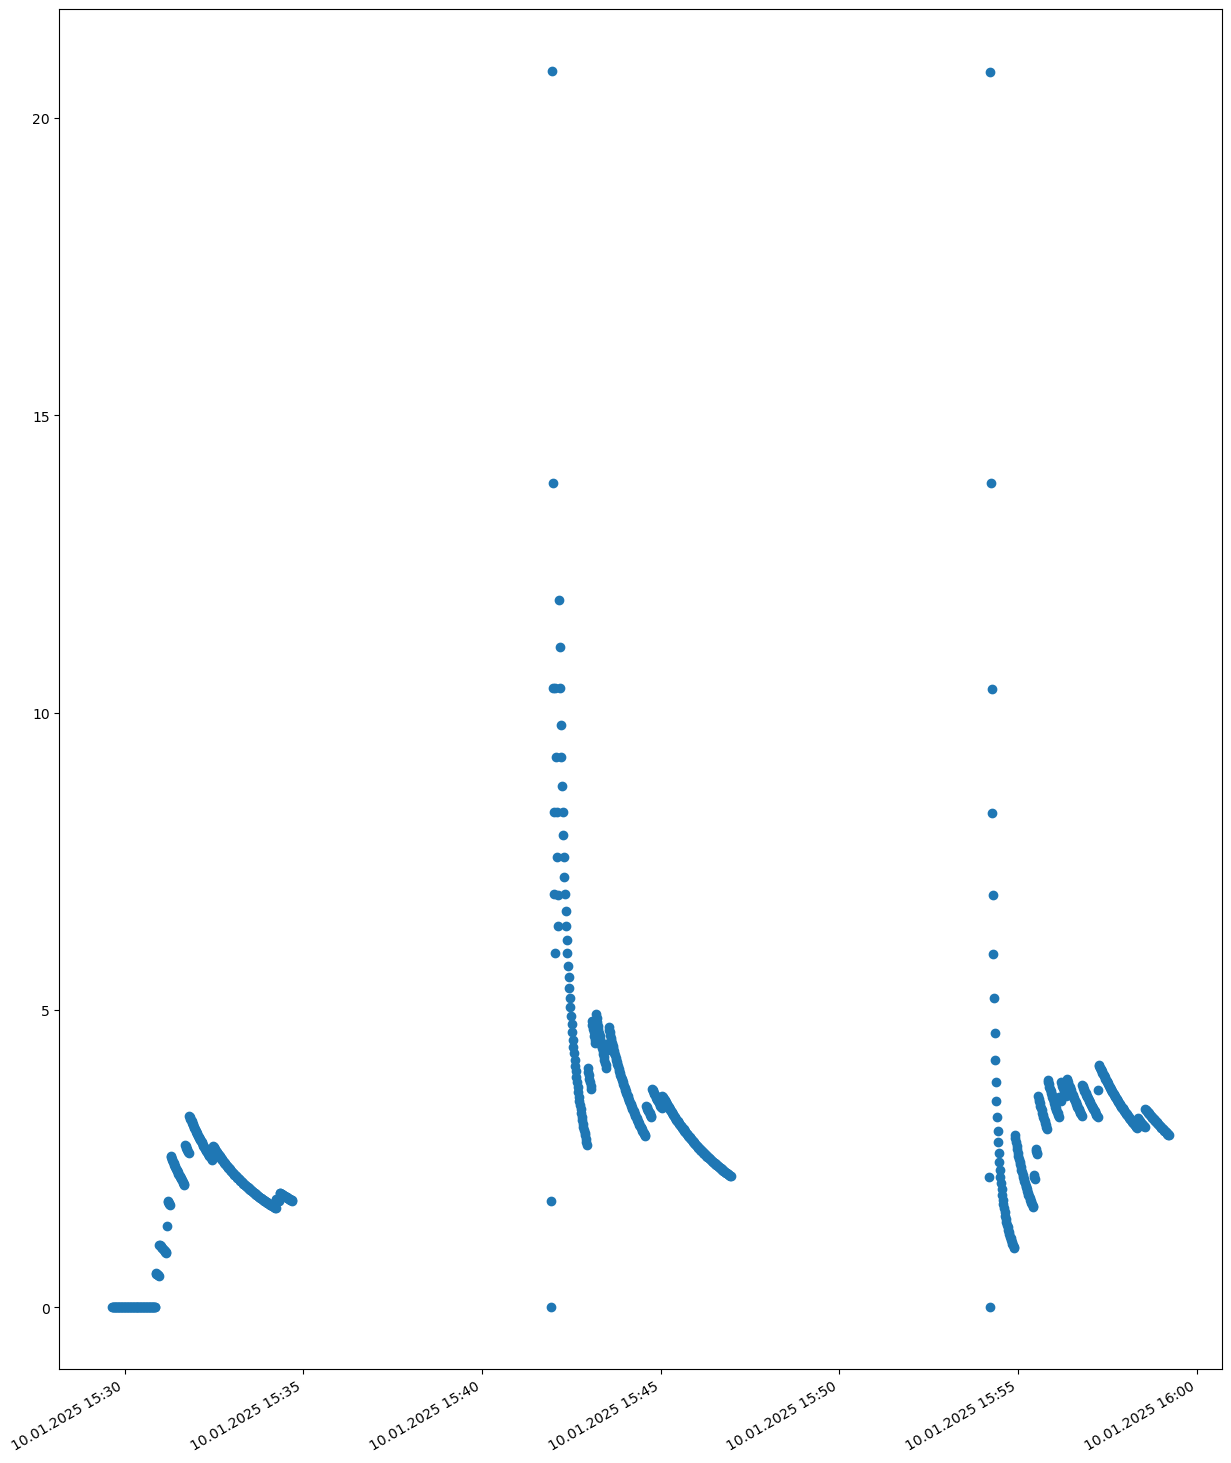

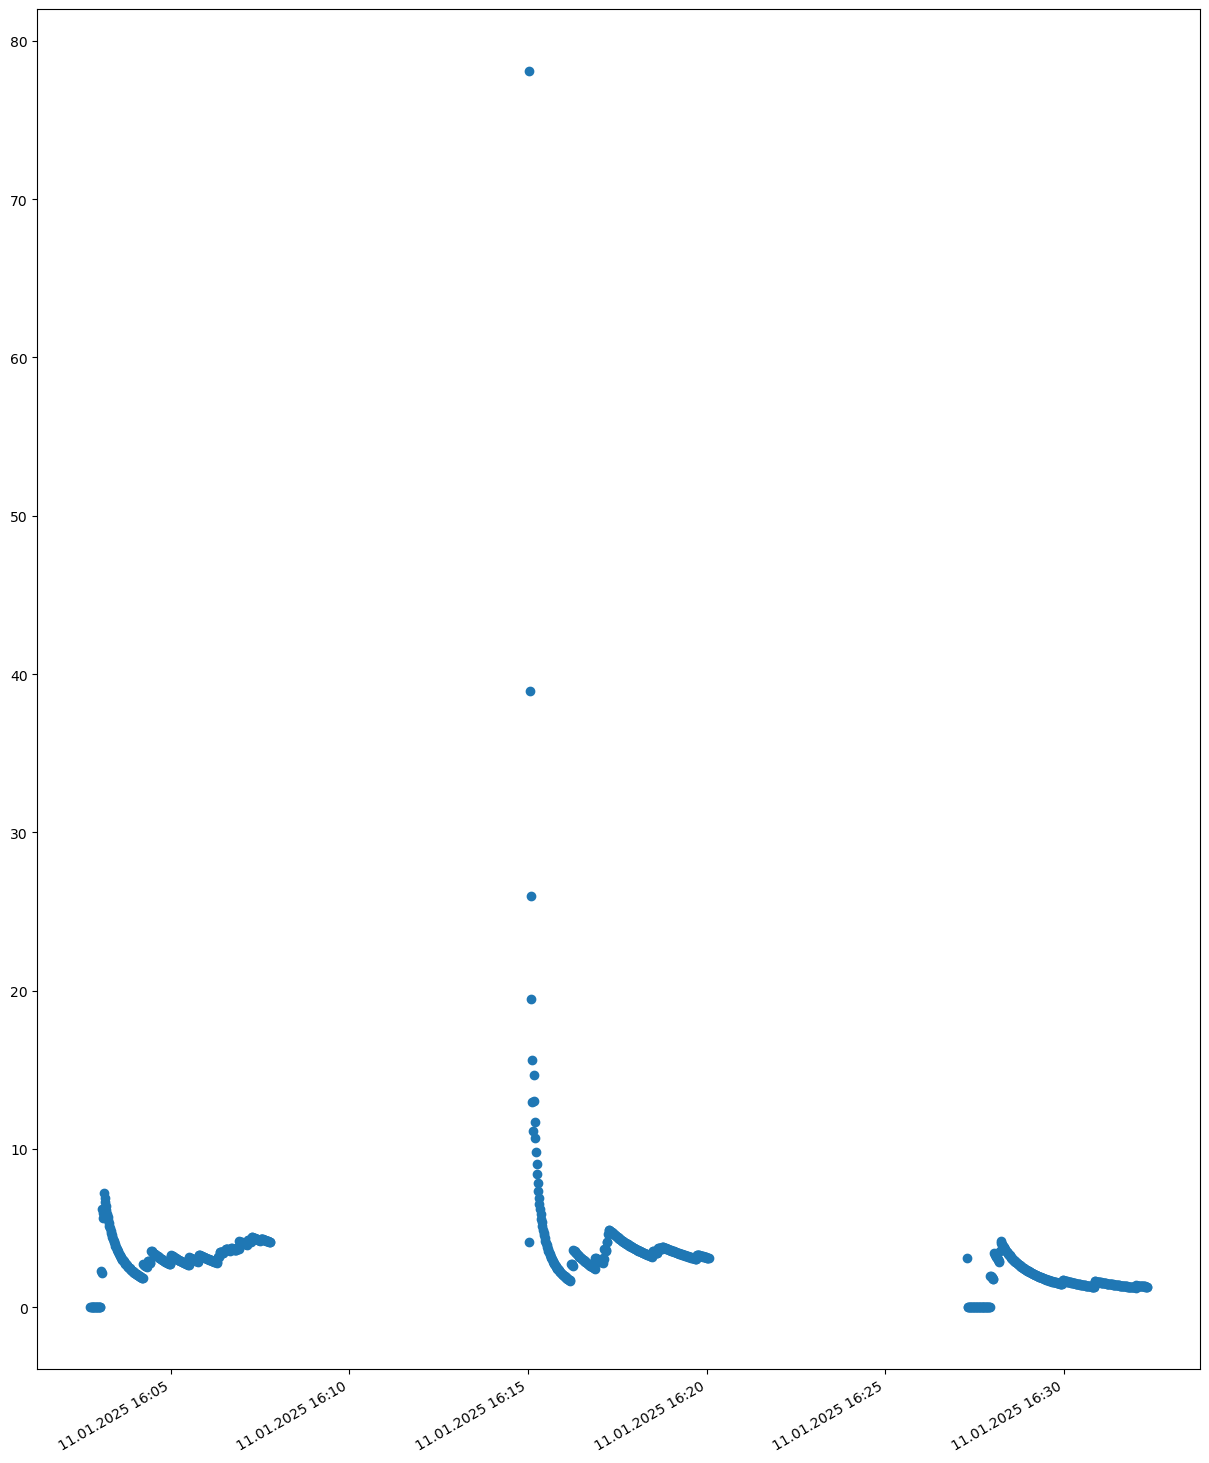

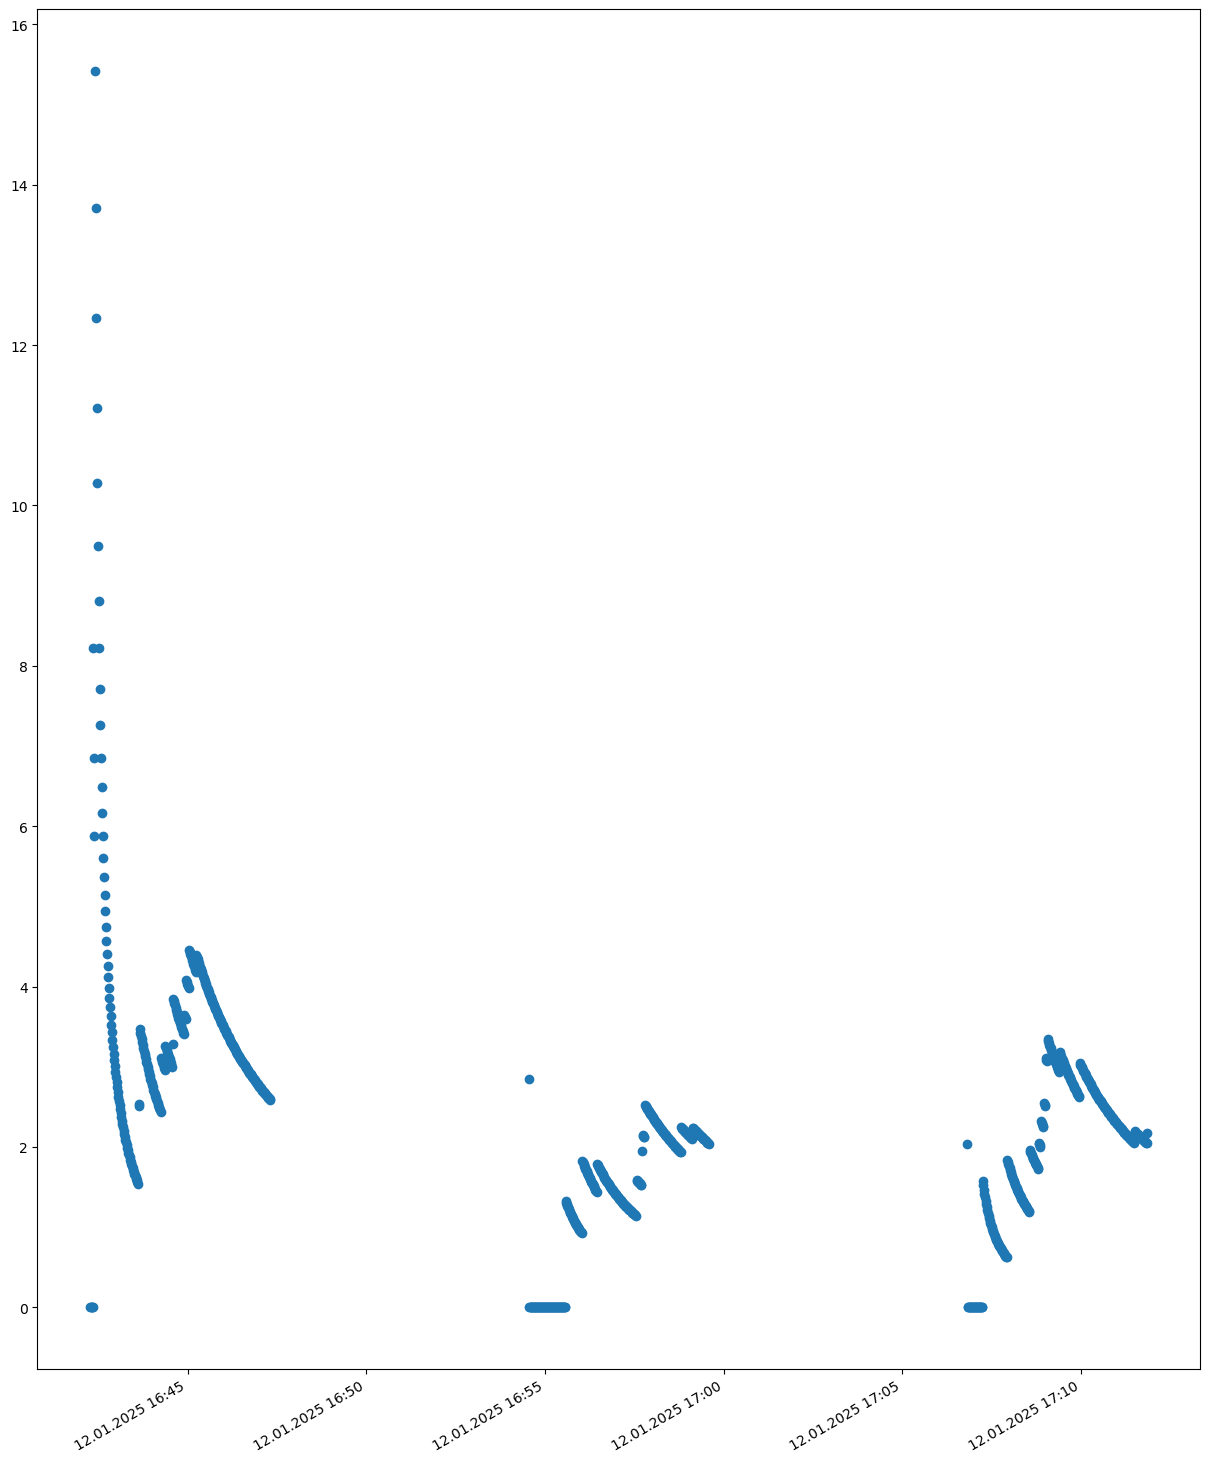

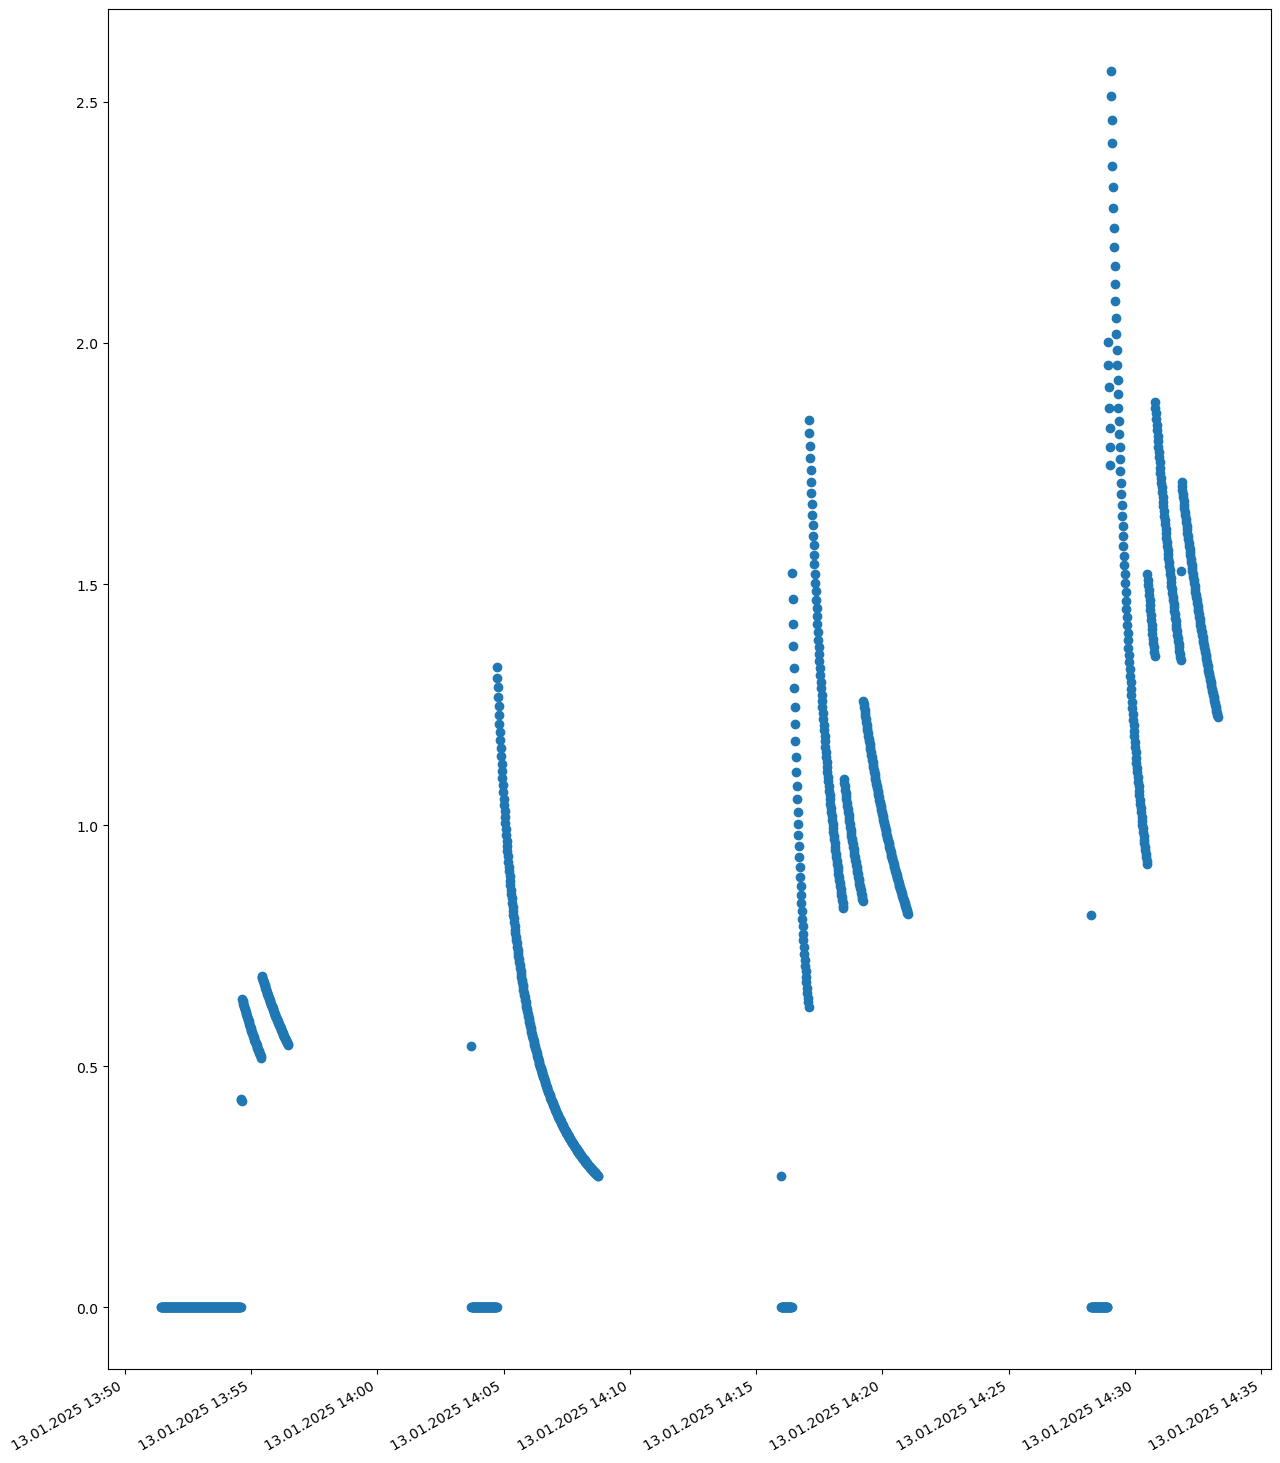

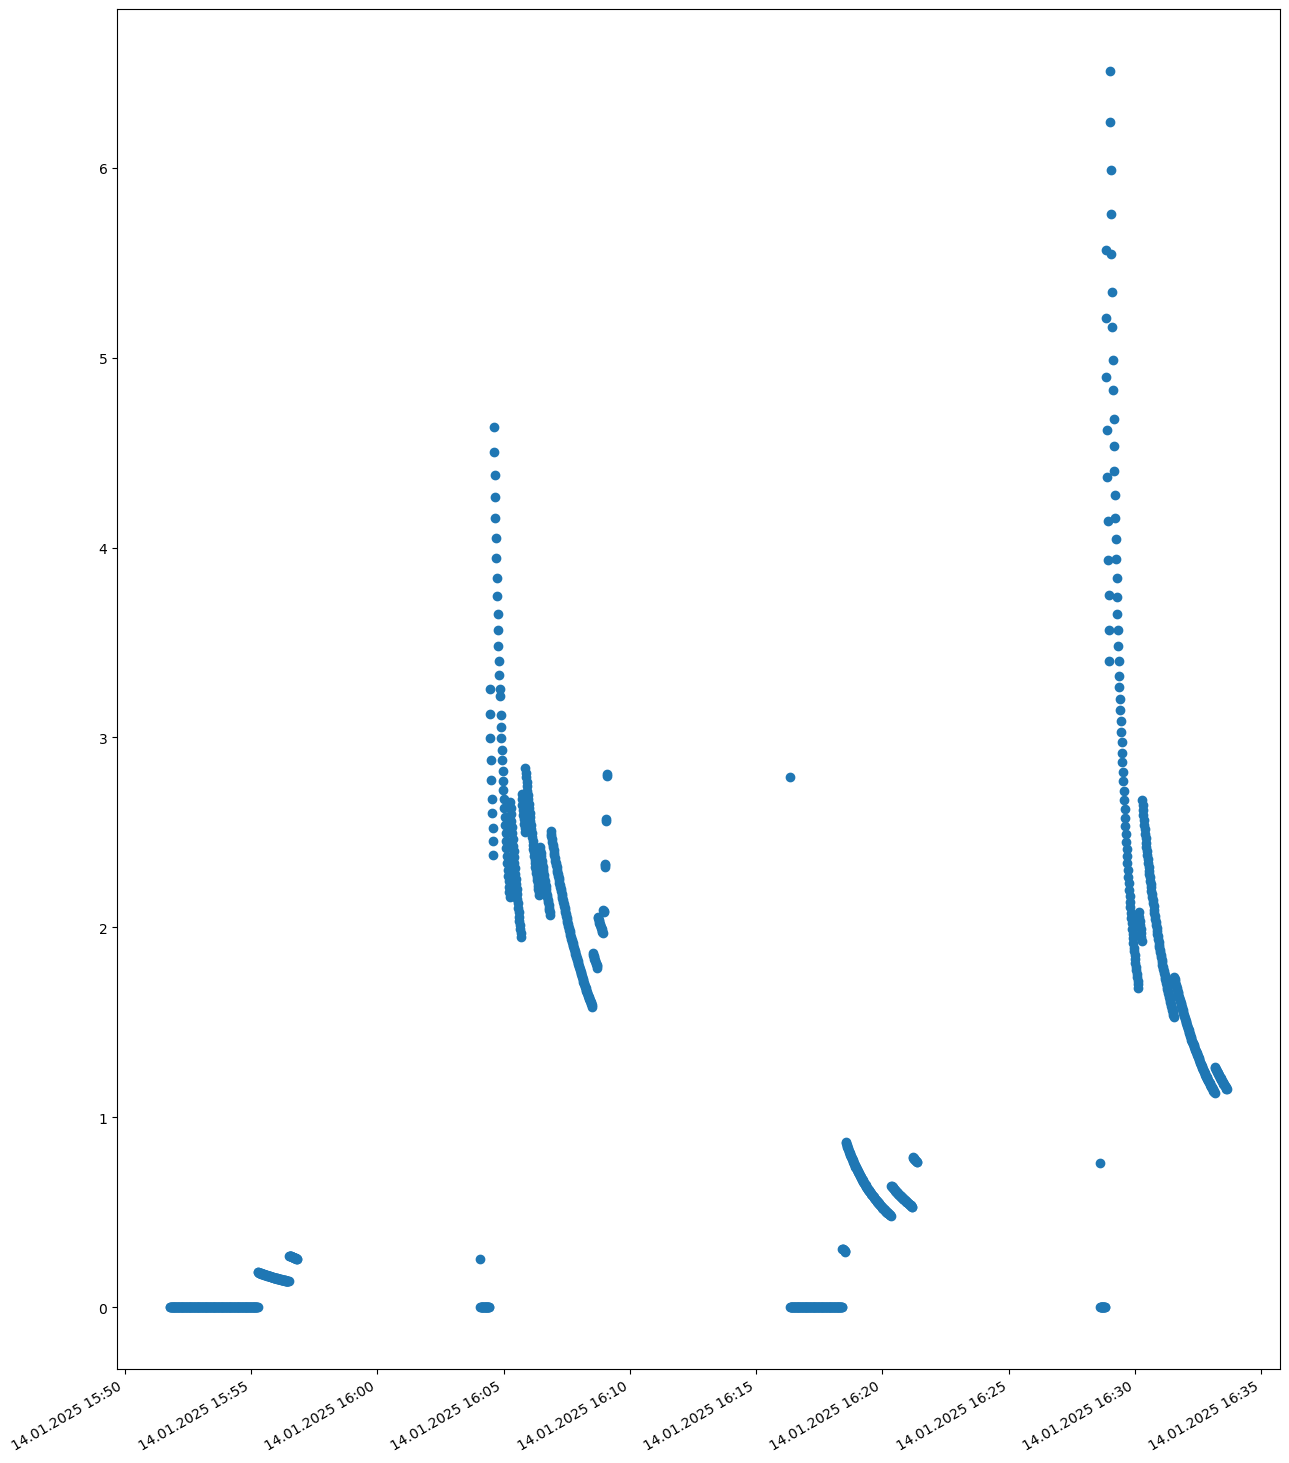

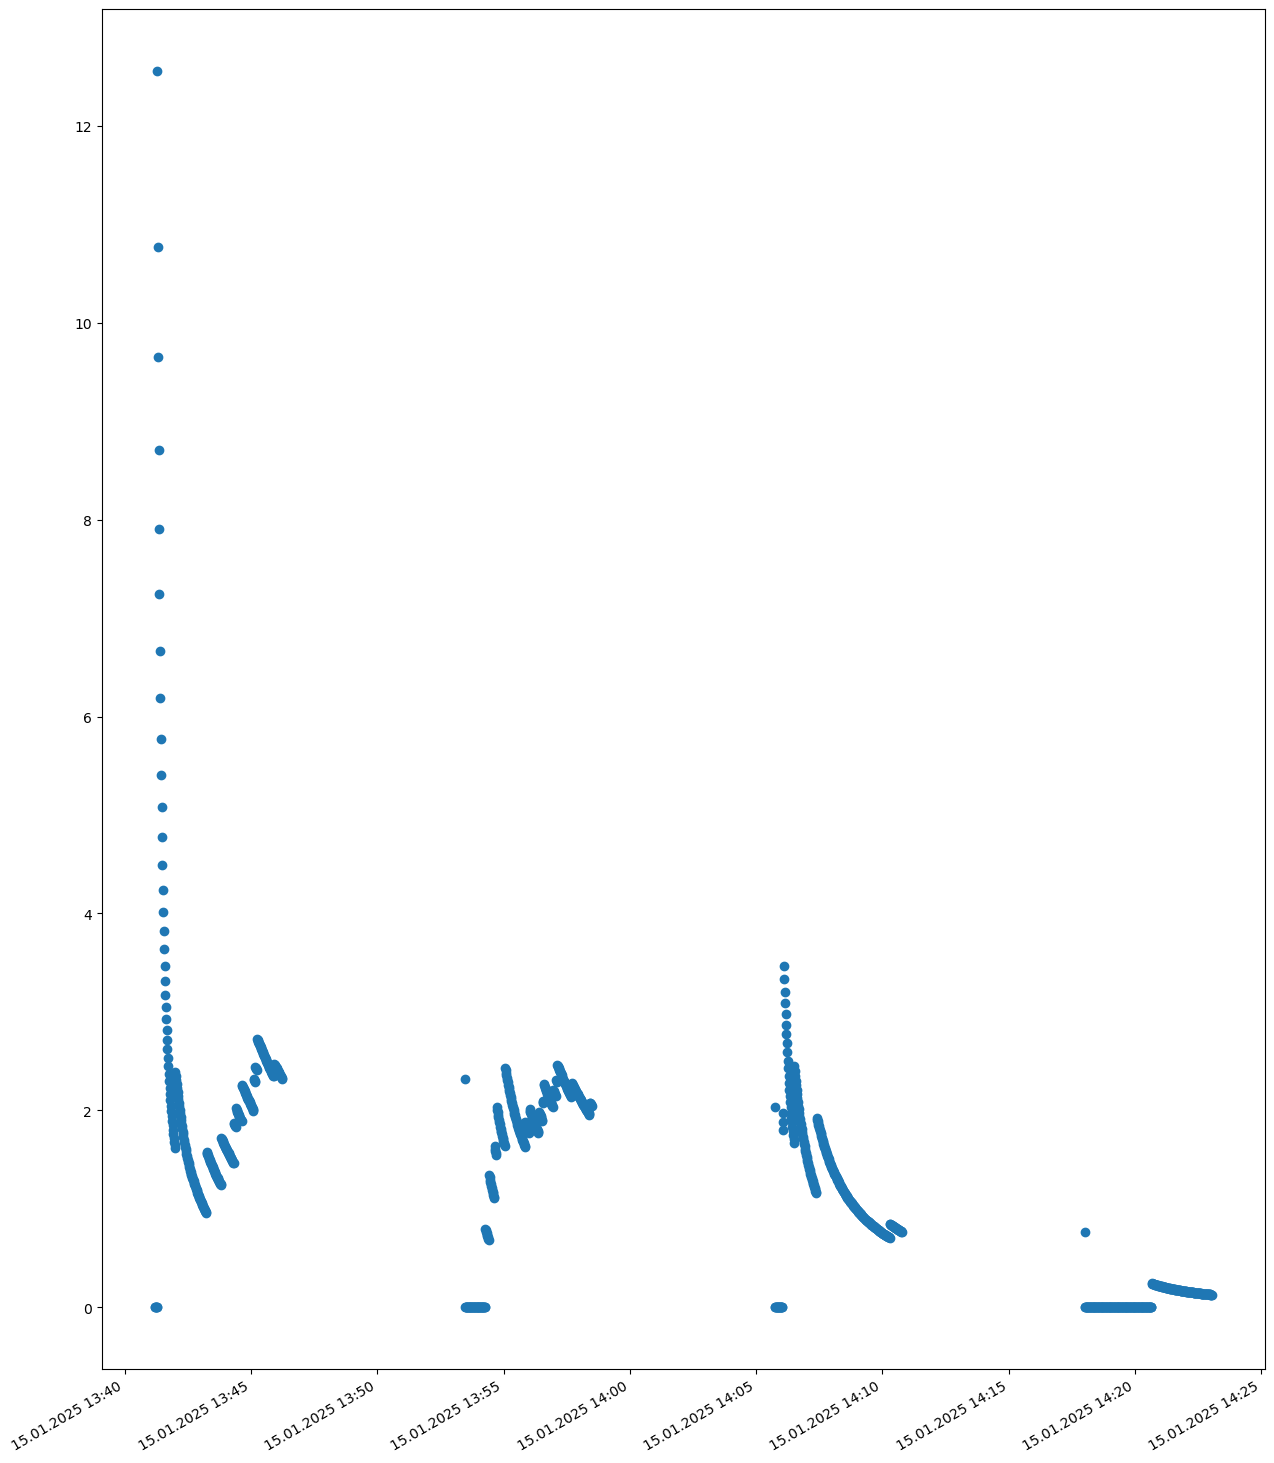

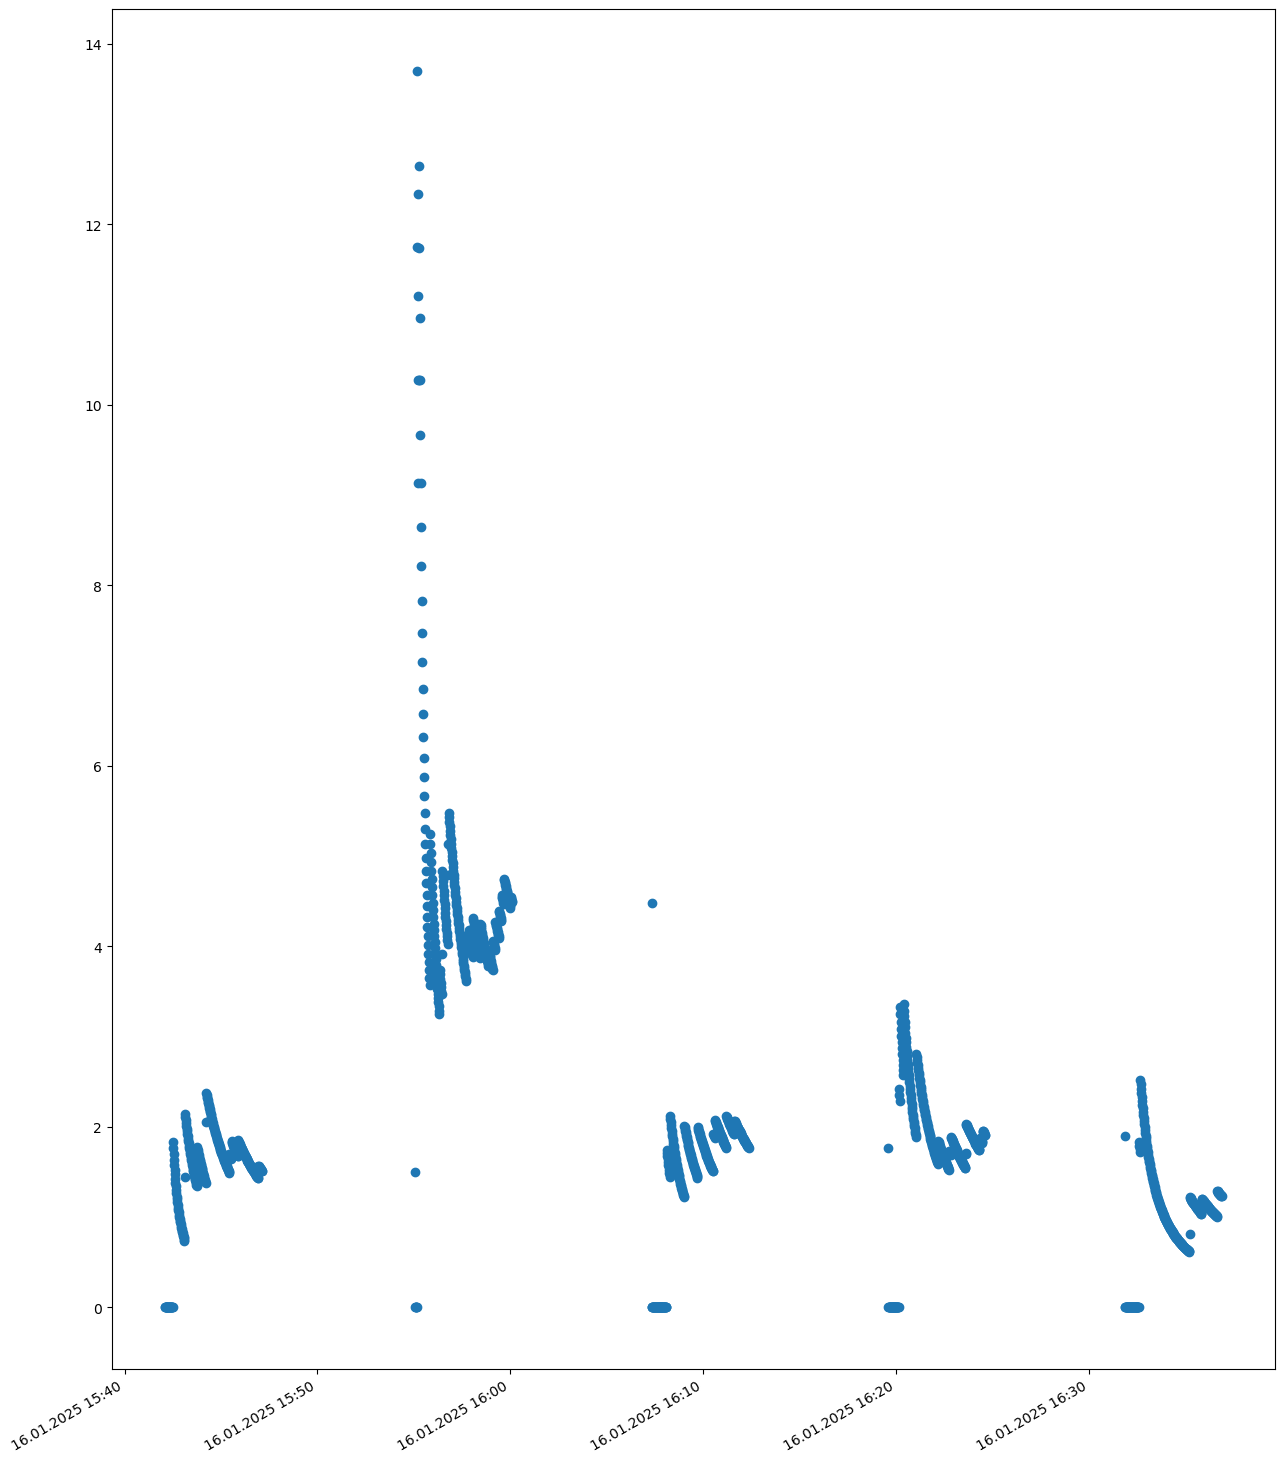

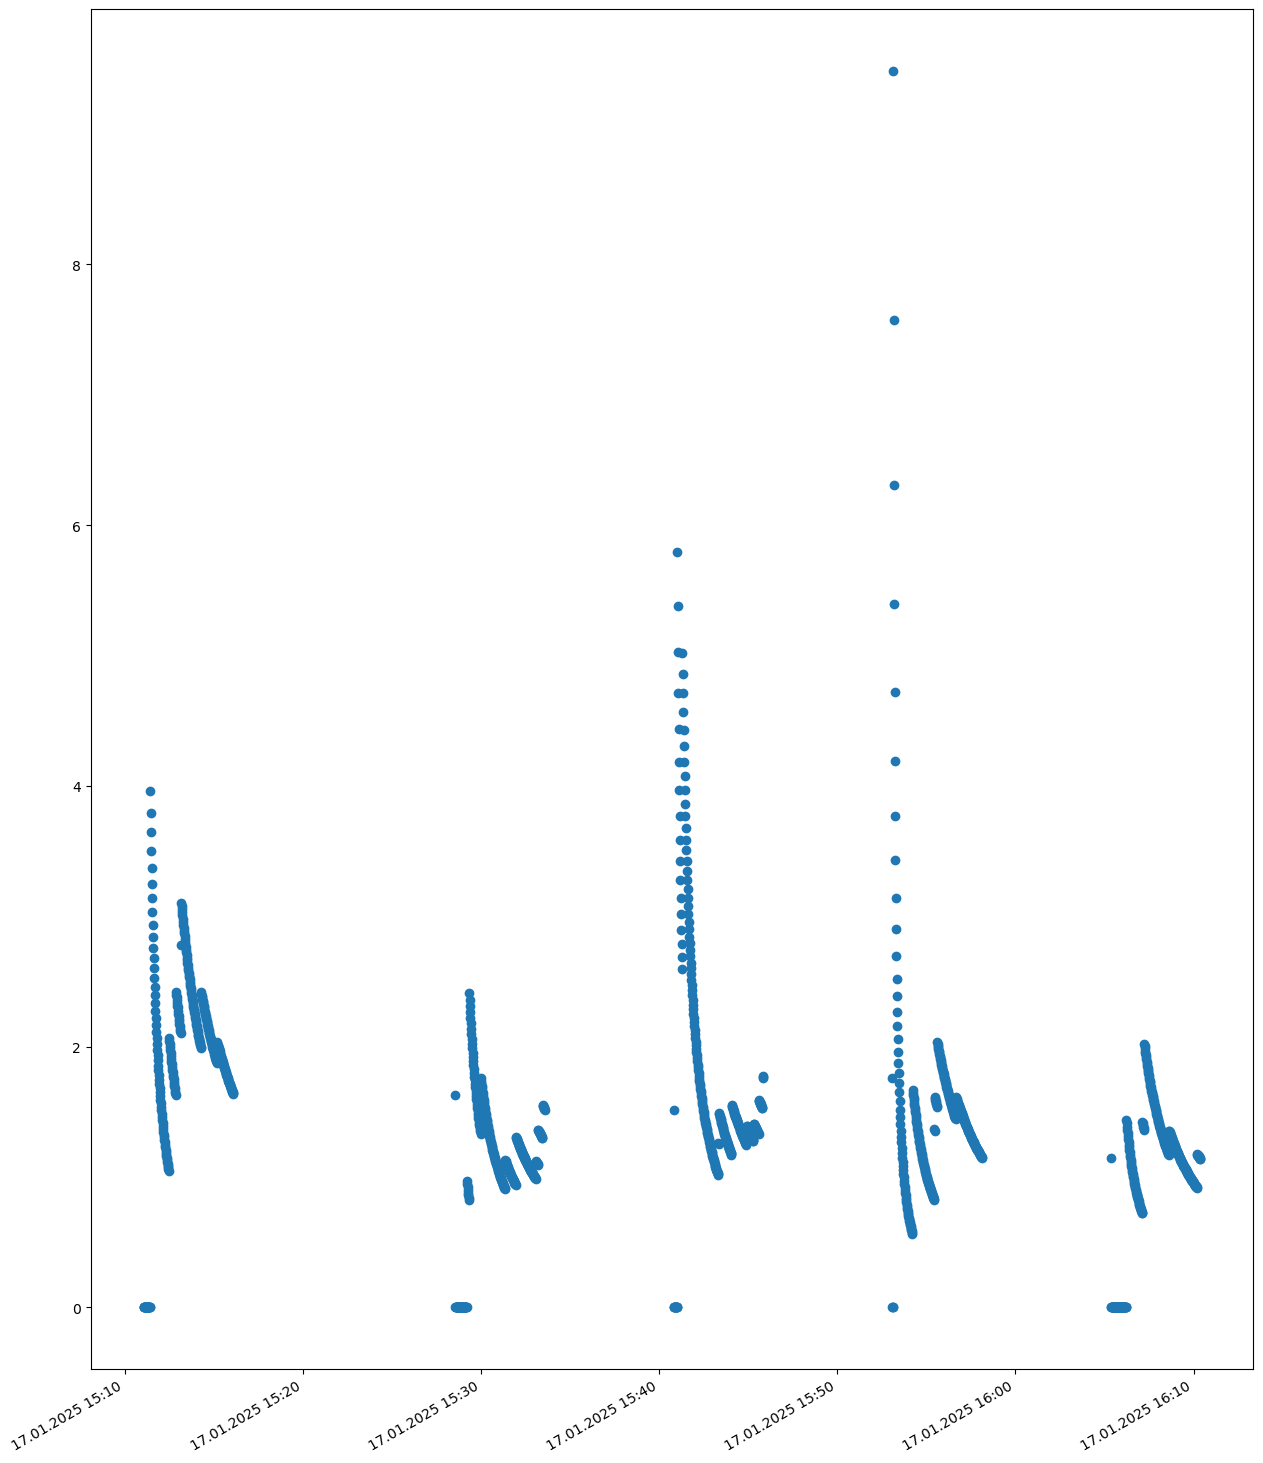

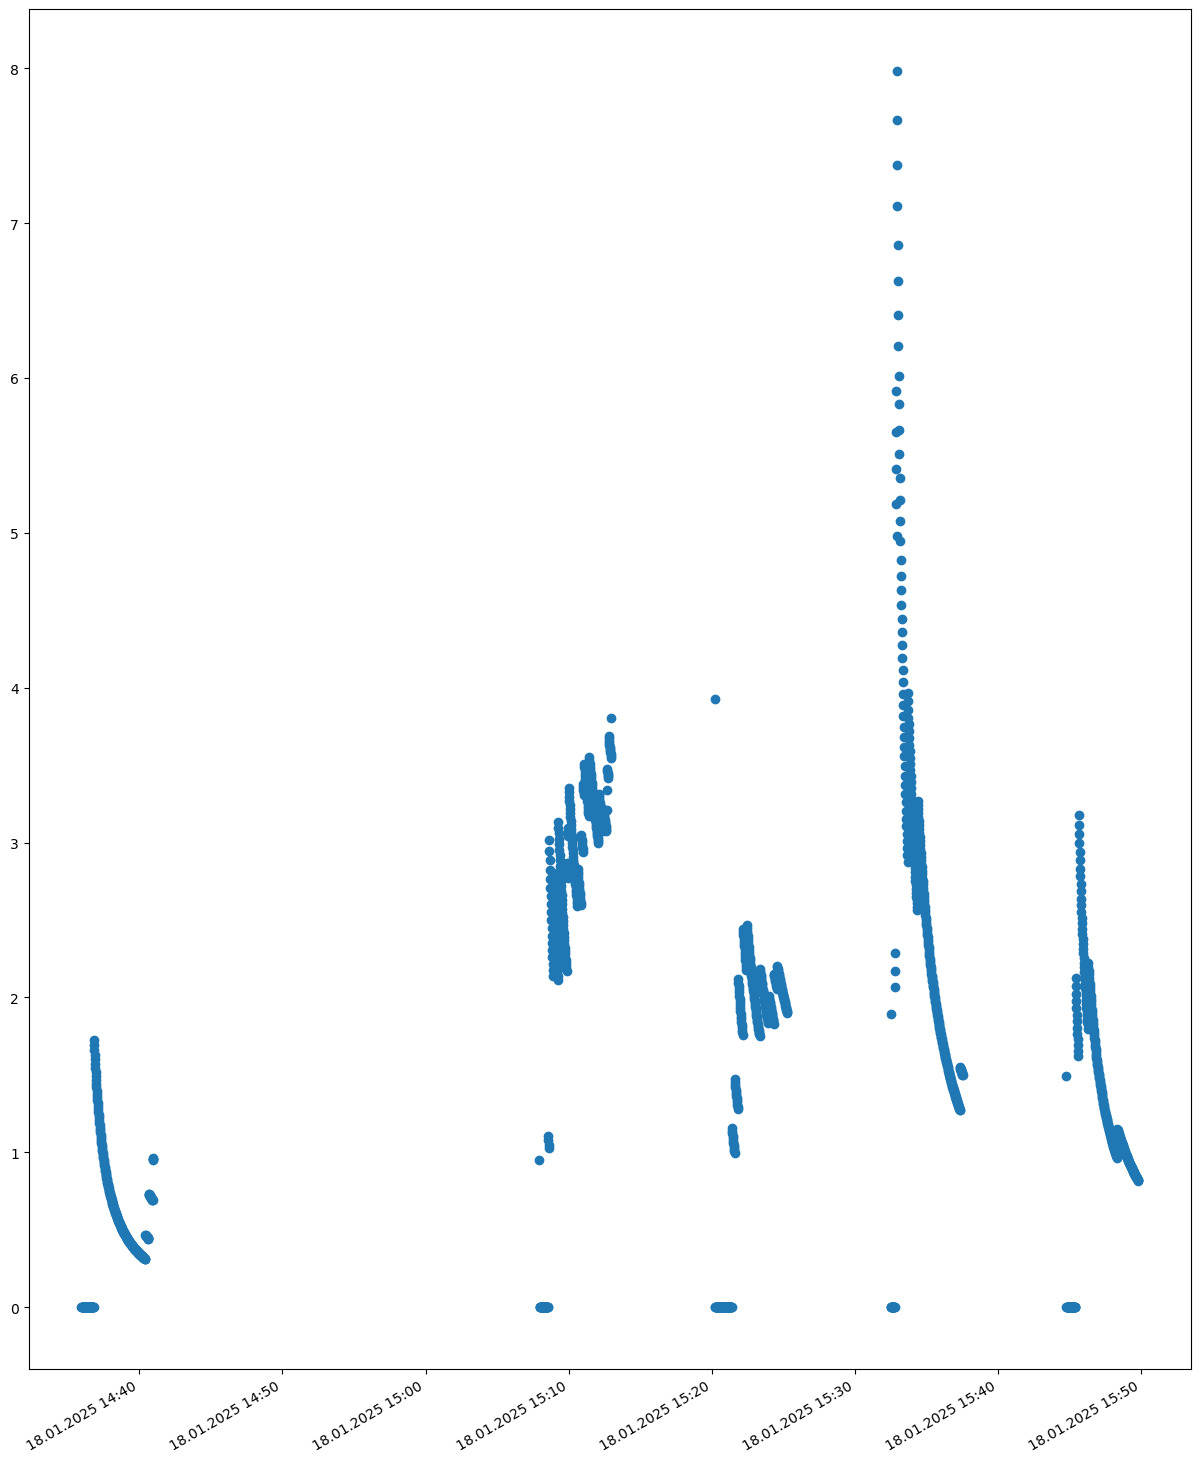

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

p = Path(r"D:\Coding\Data\Lanzhou_cfdc")
print(len(list(p.glob("data_202501*.csv"))))
for i, file in enumerate(p.glob("data_202501*.csv")):
    if i > 17:
        break
    data = pd.read_csv(file).dropna(subset=['Lamina Average T [C]'])

    base_date = pd.to_datetime(file.stem.split('_')[1][0:8])
    dt = base_date + pd.to_timedelta(data['Time'], unit='s')

    x = dt
    bac_toggle = data['Background INP avg [#/L] Toggle']
    #sam_toggle = data['Sample INP avg [#/L] Toggle']
    y_bac_15 = data['Background INP avg [#/L]'][bac_toggle==True][data['Lamina T Set [C]']==-15.0].reindex(x.index, fill_value=np.nan) #后期改为其他温度
    #y_sam_15 = data['Sample INP avg [#/L]'][sam_toggle==True][data['Lamina T Set [C]']==-15.0].reindex(x.index, fill_value=np.nan) #后期改为其他温度

    fig = plt.figure(figsize=(15, 20))
    ax = fig.add_subplot(111)
    
    ax.scatter(x, y_bac_15)

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m.%Y %H:%M"))
    plt.gcf().autofmt_xdate()# 自动旋转日期标记
    


### 发现的问题

1. 第8个和第17个图什么都没有

    是因为没测量-15摄氏度下的INP浓度还是因为当天没有数据? 需要看看.

    这两天的文件名分别是'D:\Coding\Data\Lanzhou_cfdc\data_20250108T090416.csv', 'D:\Coding\Data\Lanzhou_cfdc\data_20250116T223521.csv'.

* 发现'D:\Coding\Data\Lanzhou_cfdc\data_20250108T090416.csv'(也就是2025.01.08当天), 只测量了 -30degC 下的INP浓度.

* 发现'D:\Coding\Data\Lanzhou_cfdc\data_20250116T223521.csv'没有数据, 由于前面已经有2025.01.16的数据, 所以这个空文件应当删除.

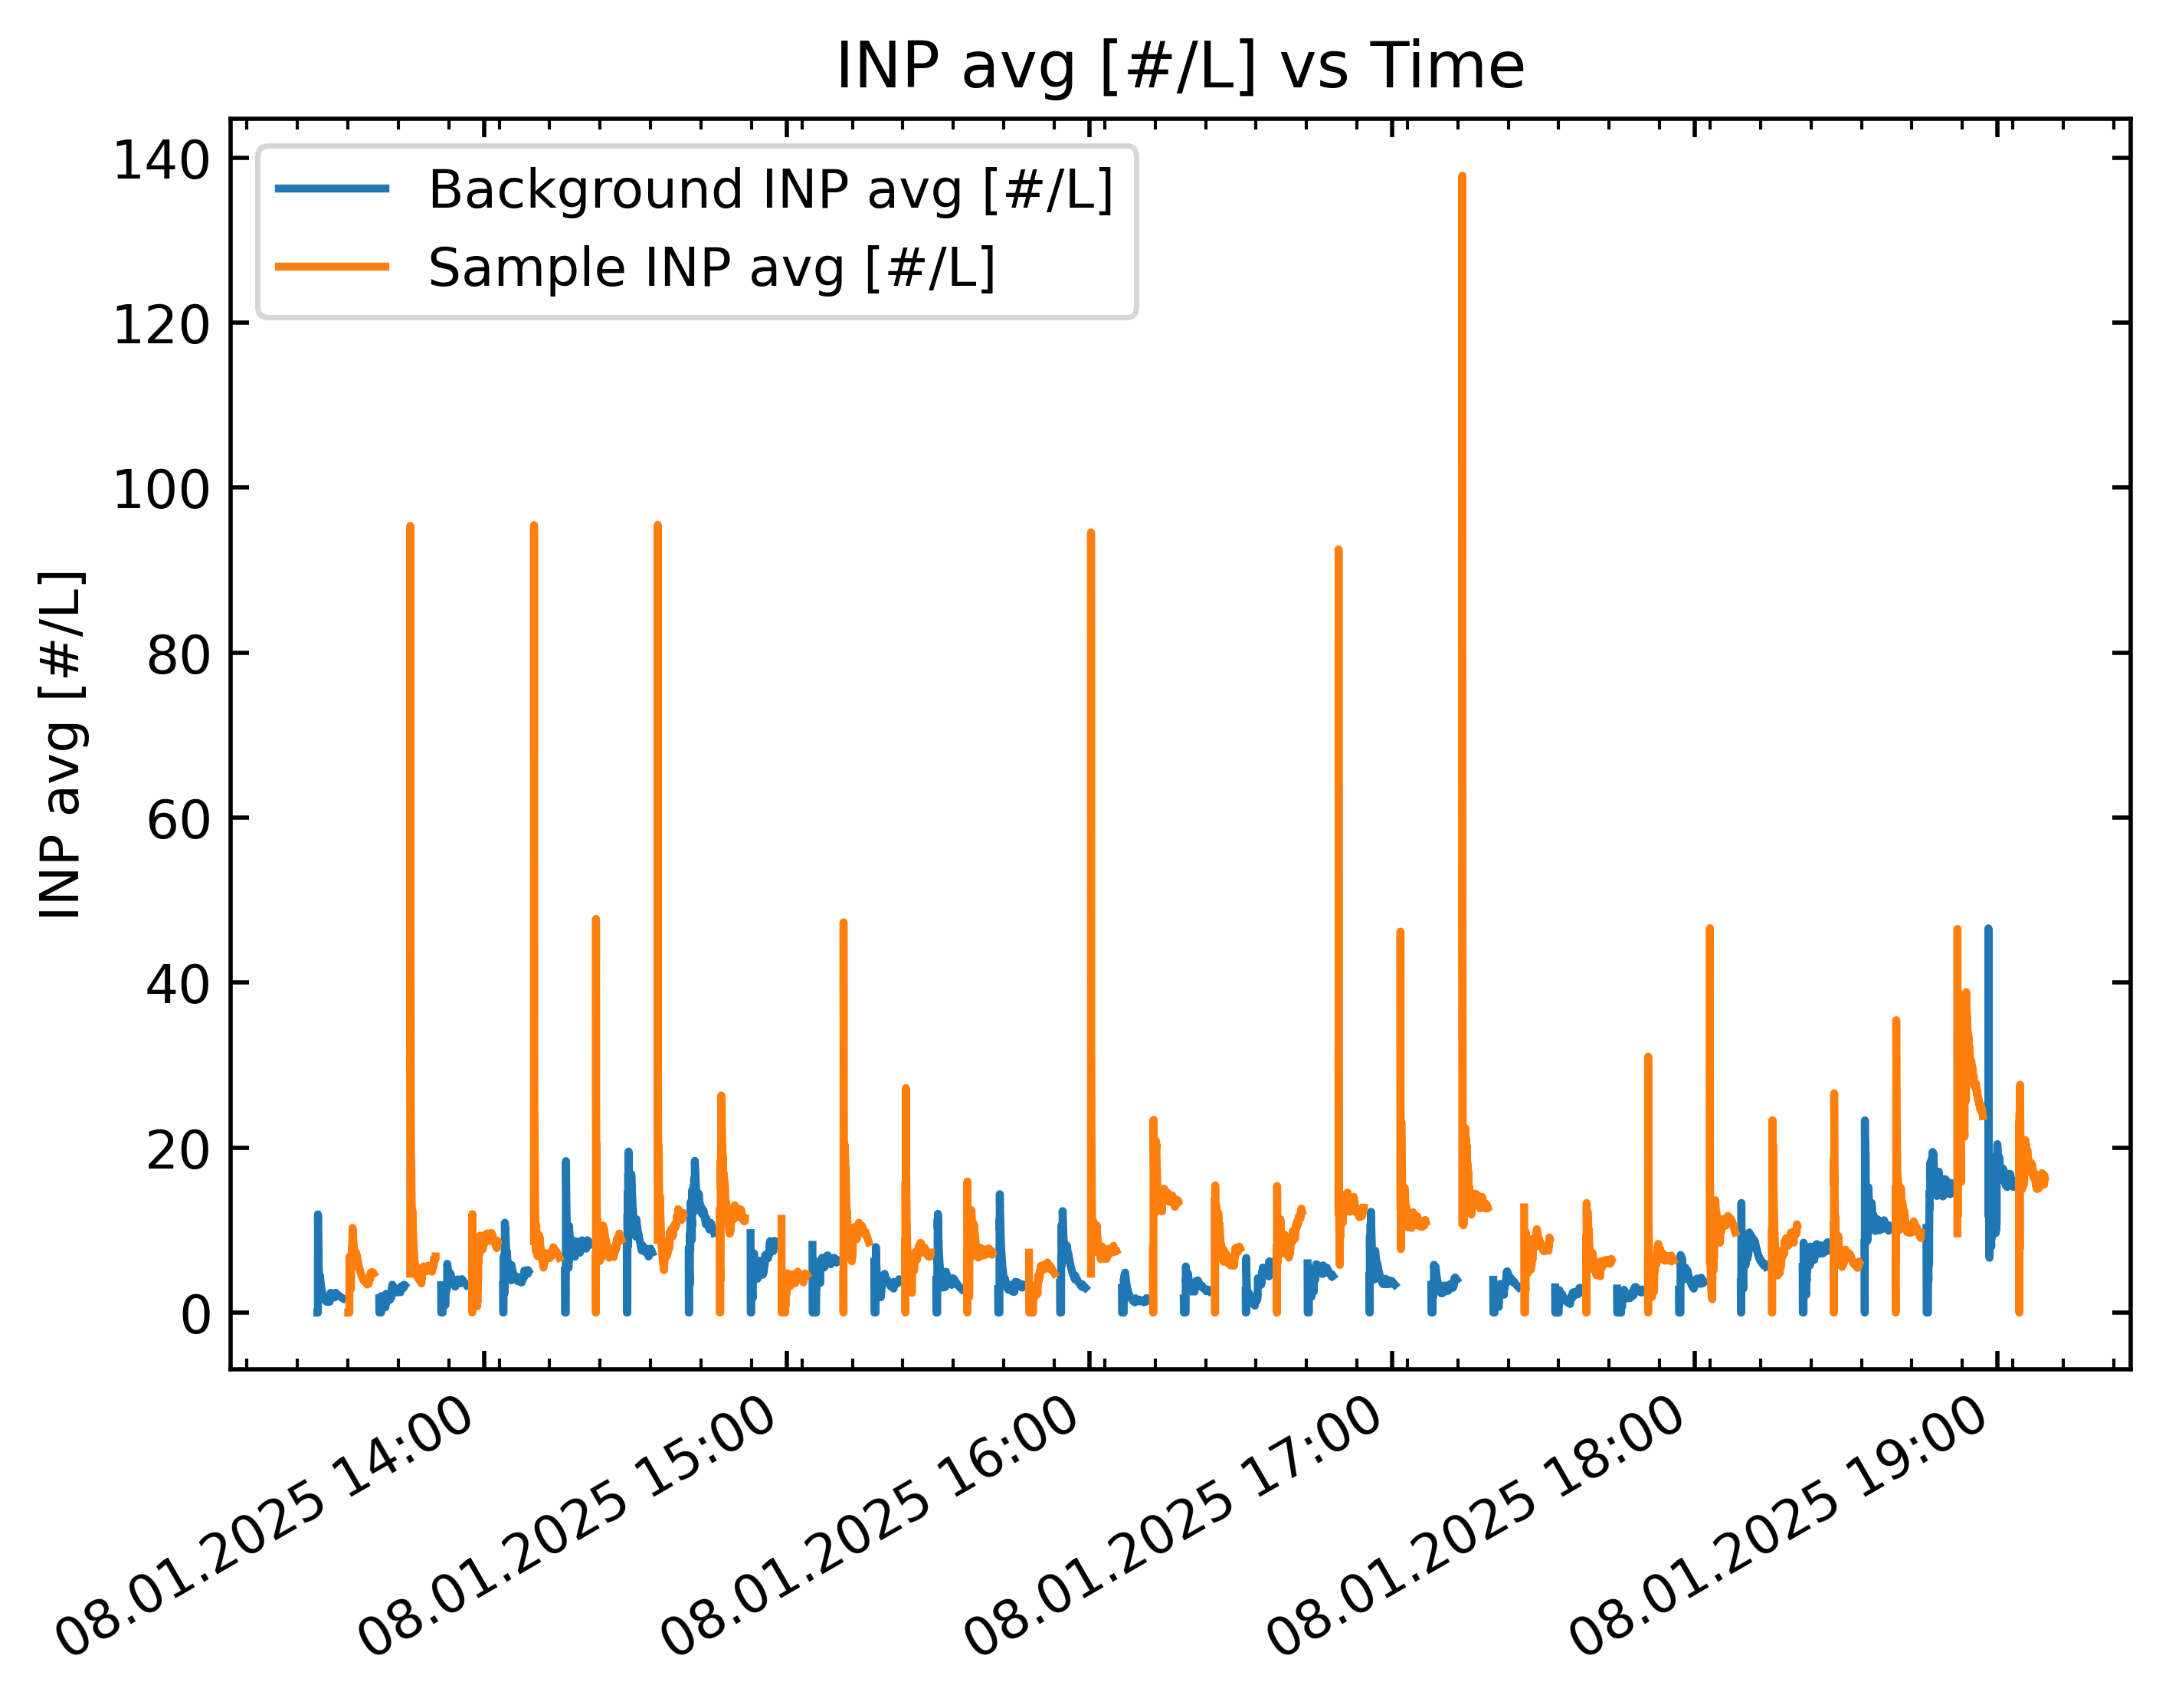

In [7]:
# 画0108这一天INP浓度的时间序列

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

#一天数据集处理
data = pd.read_csv(r"D:\Coding\Data\Lanzhou_cfdc\data_20250108T090416.csv")
data = data.dropna(subset=['Lamina Average T [C]'])

#根据文件名确定当天日期
base_date = pd.to_datetime("2025-01-08")
dt = base_date + pd.to_timedelta(data['Time'], unit='s')

x = dt
#diff = data['Lamina Average T [C]'] - data['Lamina T Set [C]']
background_toggle = data['Background INP avg [#/L] Toggle']
sample_toggle = data['Sample INP avg [#/L] Toggle']
y1 = data['Background INP avg [#/L]'][background_toggle==True][data['Lamina T Set [C]']==-30.0].reindex(x.index, fill_value=np.nan)
y2 = data['Sample INP avg [#/L]'][sample_toggle==True][data['Lamina T Set [C]']==-30.0].reindex(x.index, fill_value=np.nan)

fig = plt.figure(dpi=500)
ax = fig.add_subplot(111)

ax.plot(x, y1, label='Background INP avg [#/L]')
ax.plot(x, y2, label='Sample INP avg [#/L]')

ax.xaxis.set_major_locator(mdates.HourLocator(interval=1)) # 每小时一个主刻度
ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=10)) # 每10分钟一个次刻度
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m.%Y %H:%M"))
plt.gcf().autofmt_xdate()# 自动旋转日期标记
ax.set_ylabel('INP avg [#/L]')
ax.tick_params(which='both', top=True, bottom=True, left=True, right=True, direction='in')
ax.set_title('INP avg [#/L] vs Time')
ax.legend()


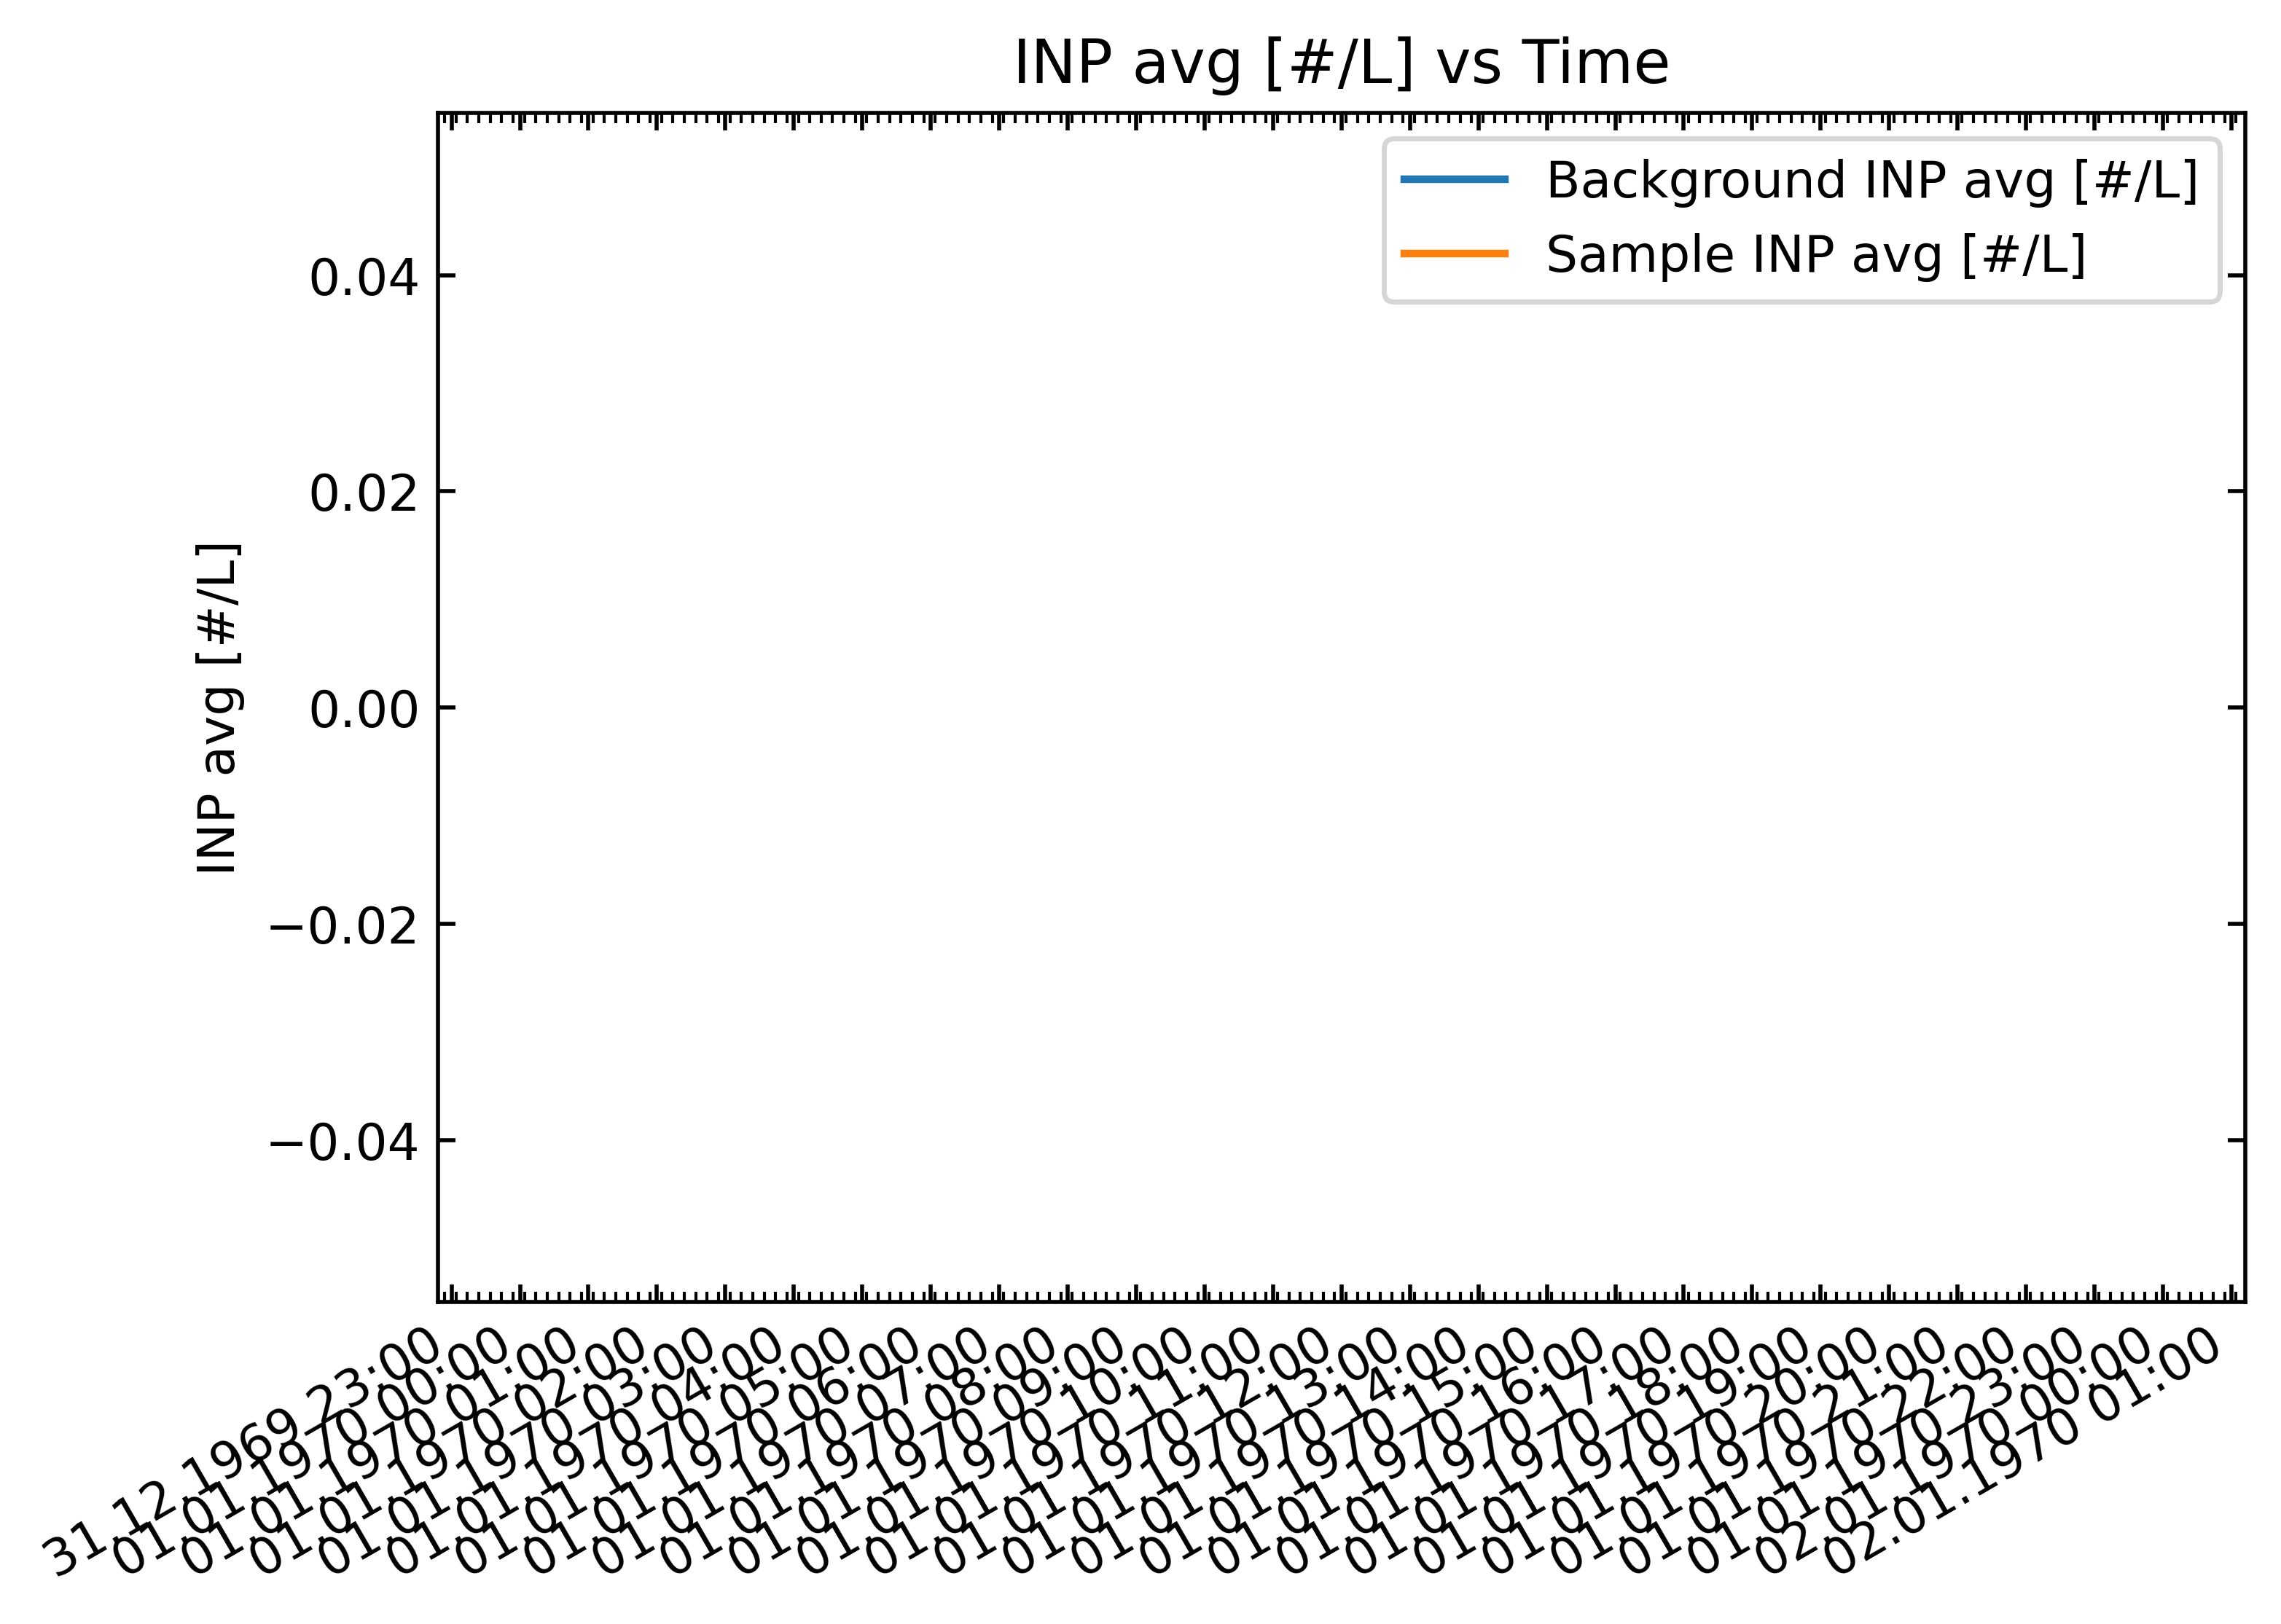

In [8]:
# 画0116这一天INP浓度的时间序列(重复文件)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

#一天数据集处理
data = pd.read_csv(r"D:\Coding\Data\Lanzhou_cfdc\data_20250116T223521.csv")
data = data.dropna(subset=['Lamina Average T [C]'])

#根据文件名确定当天日期
base_date = pd.to_datetime("2025-01-16")
dt = base_date + pd.to_timedelta(data['Time'], unit='s')

x = dt
diff = data['Lamina Average T [C]'] - data['Lamina T Set [C]']
background_toggle = data['Background INP avg [#/L] Toggle']
sample_toggle = data['Sample INP avg [#/L] Toggle']
y1 = data['Background INP avg [#/L]'][background_toggle==True][abs(diff) <= 0.6].reindex(x.index, fill_value=np.nan)
y2 = data['Sample INP avg [#/L]'][sample_toggle==True][abs(diff) <= 0.6].reindex(x.index, fill_value=np.nan)

fig = plt.figure(dpi=500)
ax = fig.add_subplot(111)

ax.plot(x, y1, label='Background INP avg [#/L]')
ax.plot(x, y2, label='Sample INP avg [#/L]')

ax.xaxis.set_major_locator(mdates.HourLocator(interval=1)) # 每小时一个主刻度
ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=10)) # 每10分钟一个次刻度
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m.%Y %H:%M"))
plt.gcf().autofmt_xdate()# 自动旋转日期标记
ax.set_ylabel('INP avg [#/L]')
ax.tick_params(which='both', top=True, bottom=True, left=True, right=True, direction='in')
ax.set_title('INP avg [#/L] vs Time')
ax.legend()


36


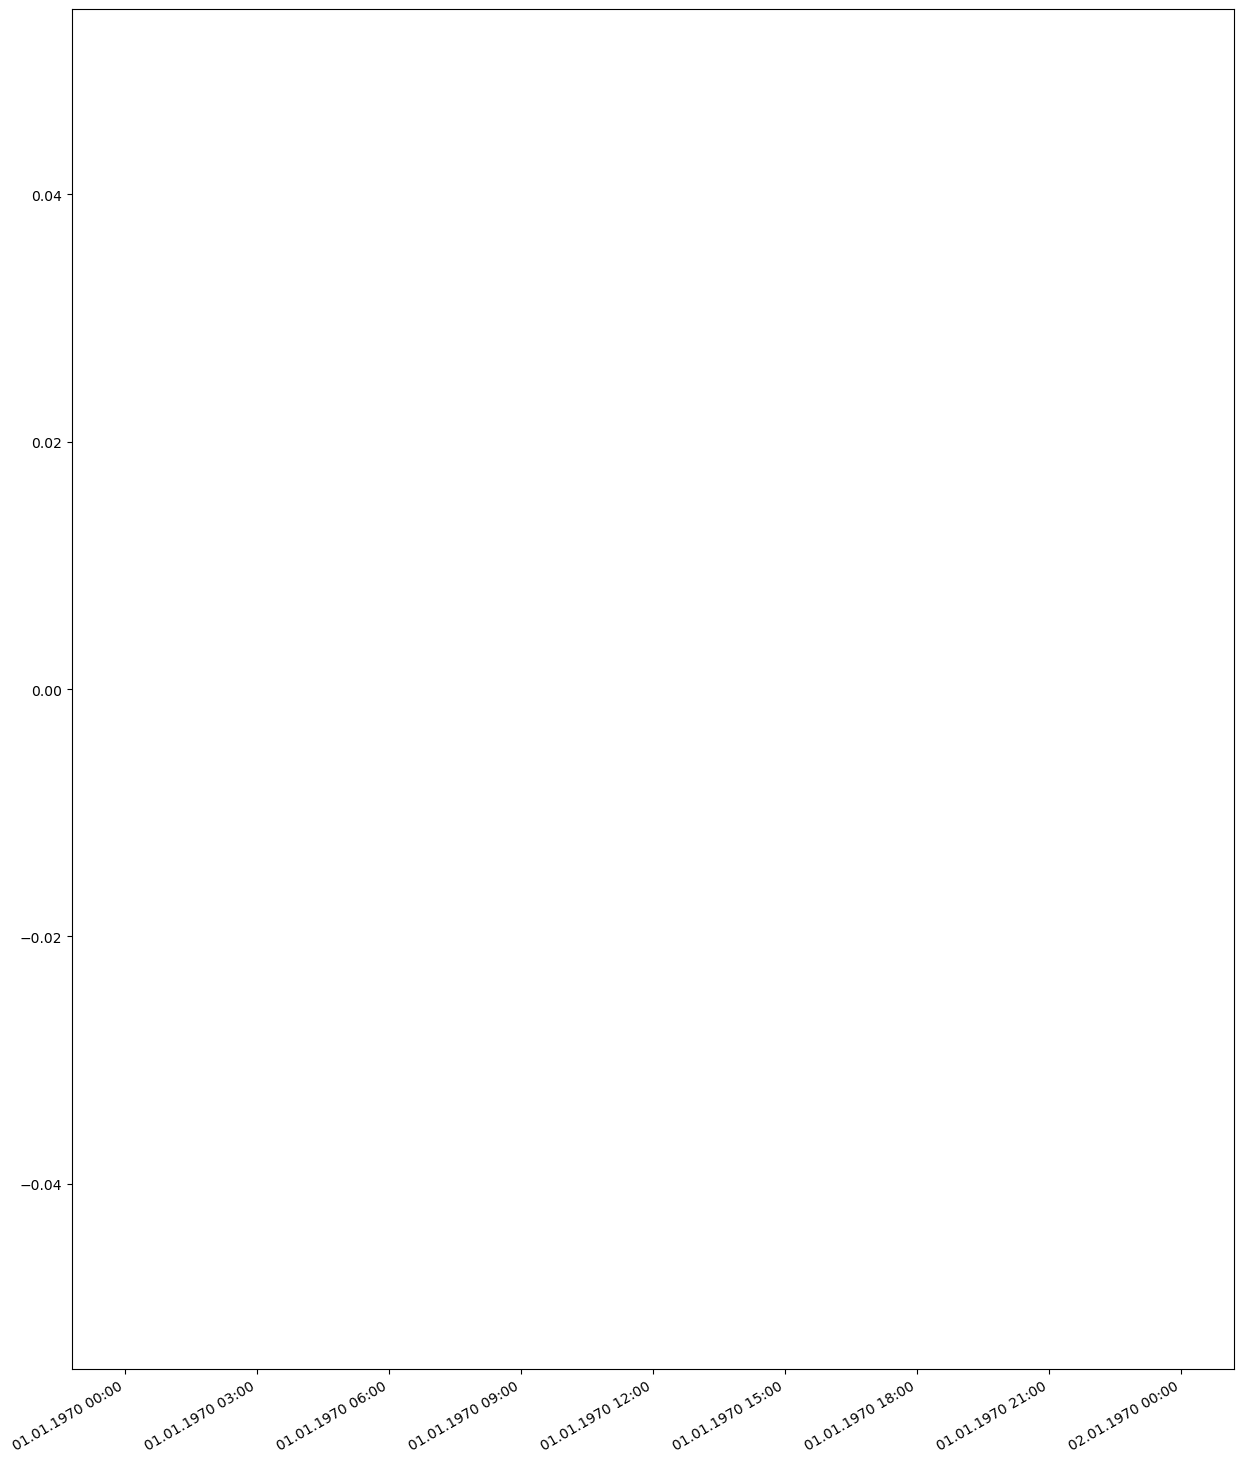

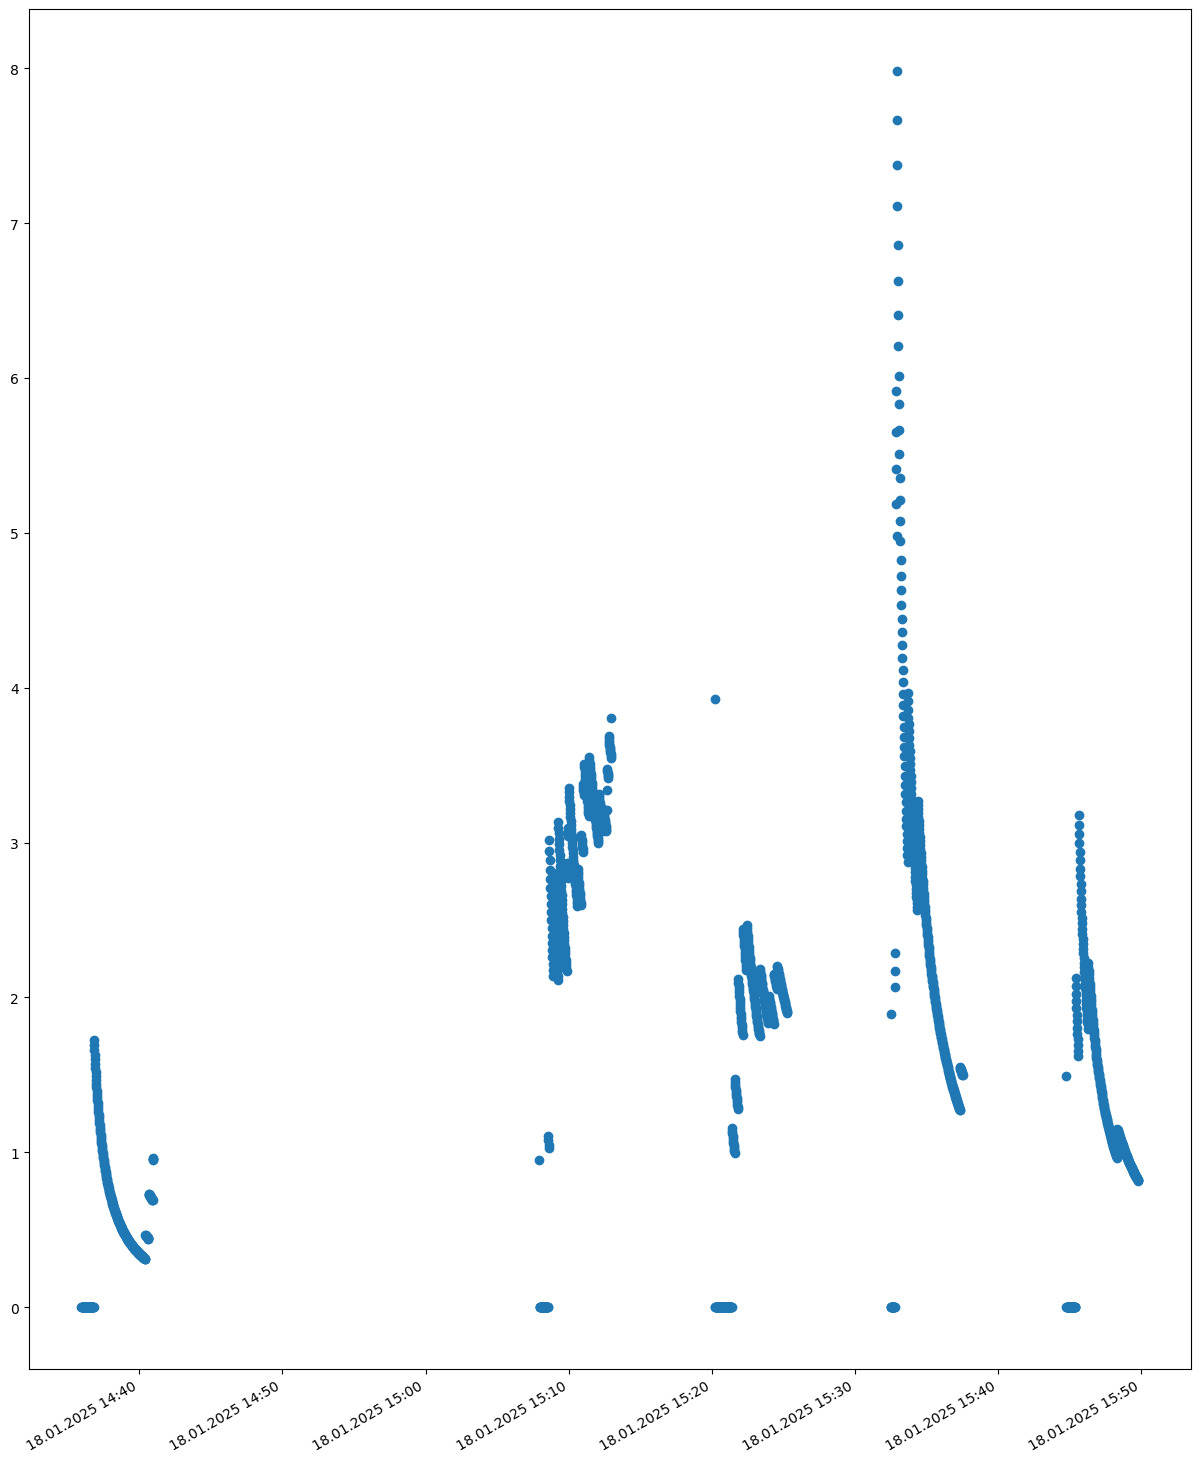

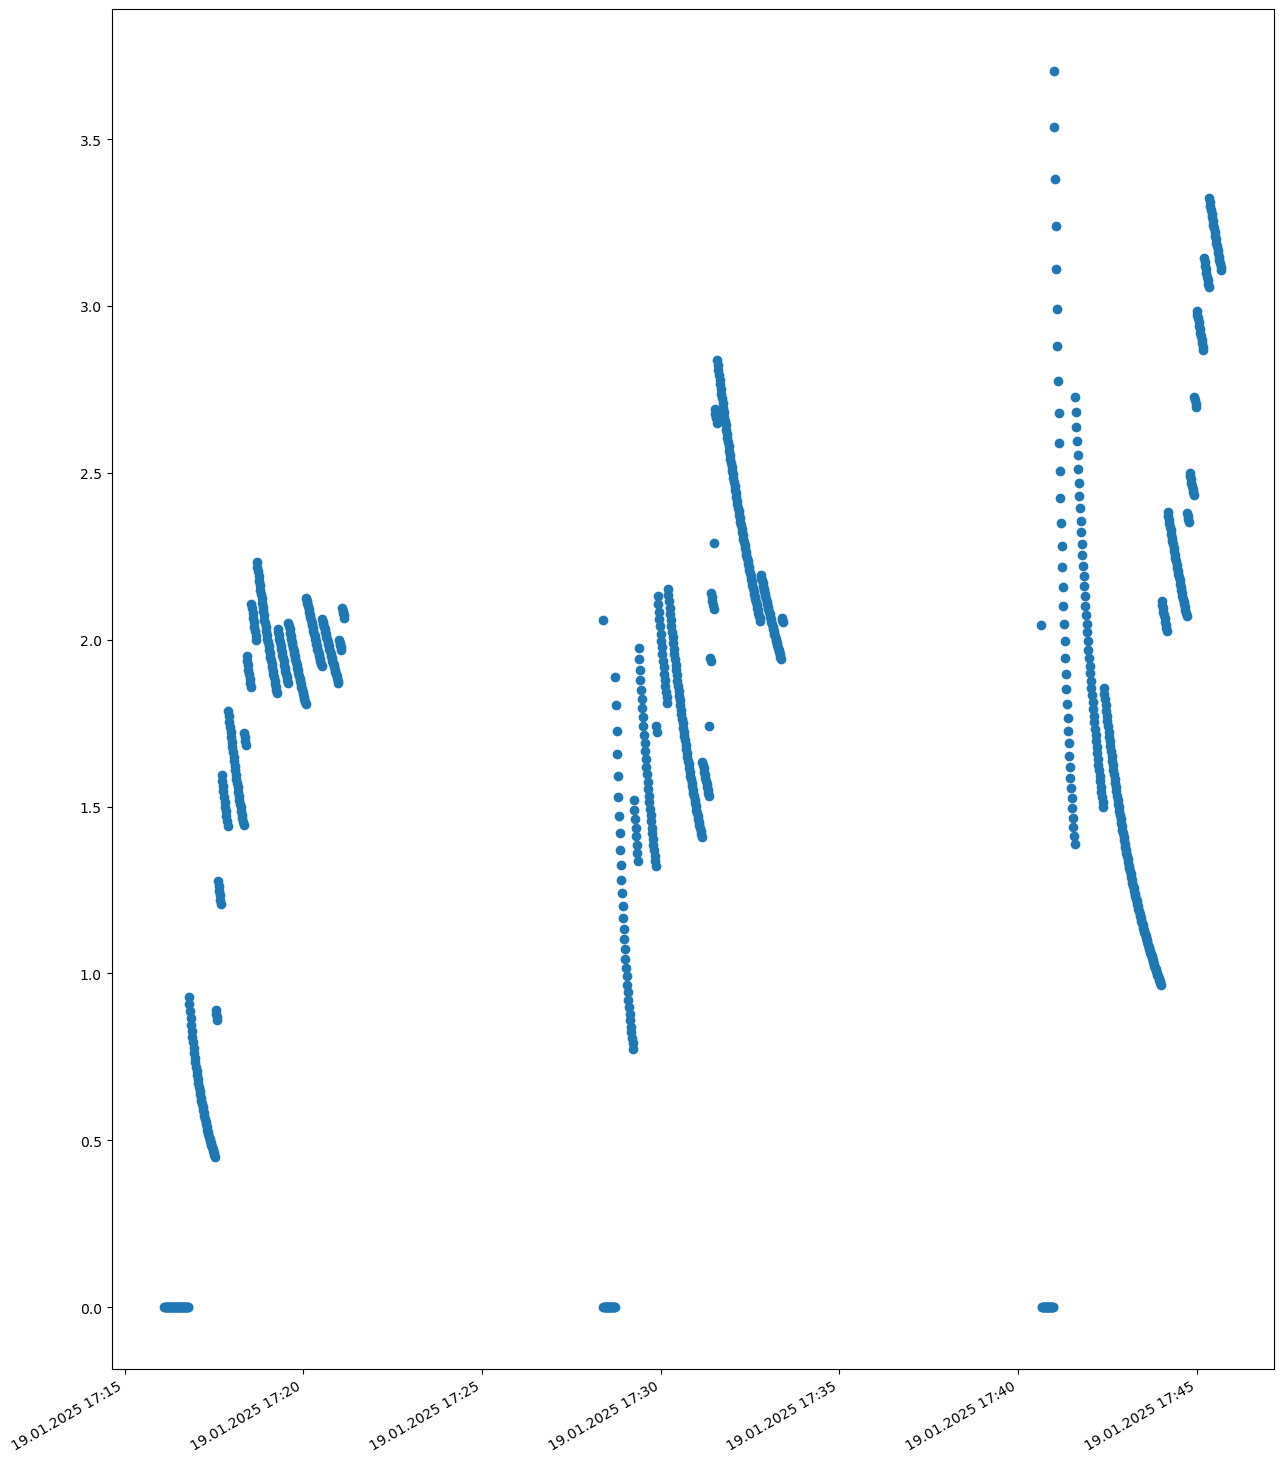

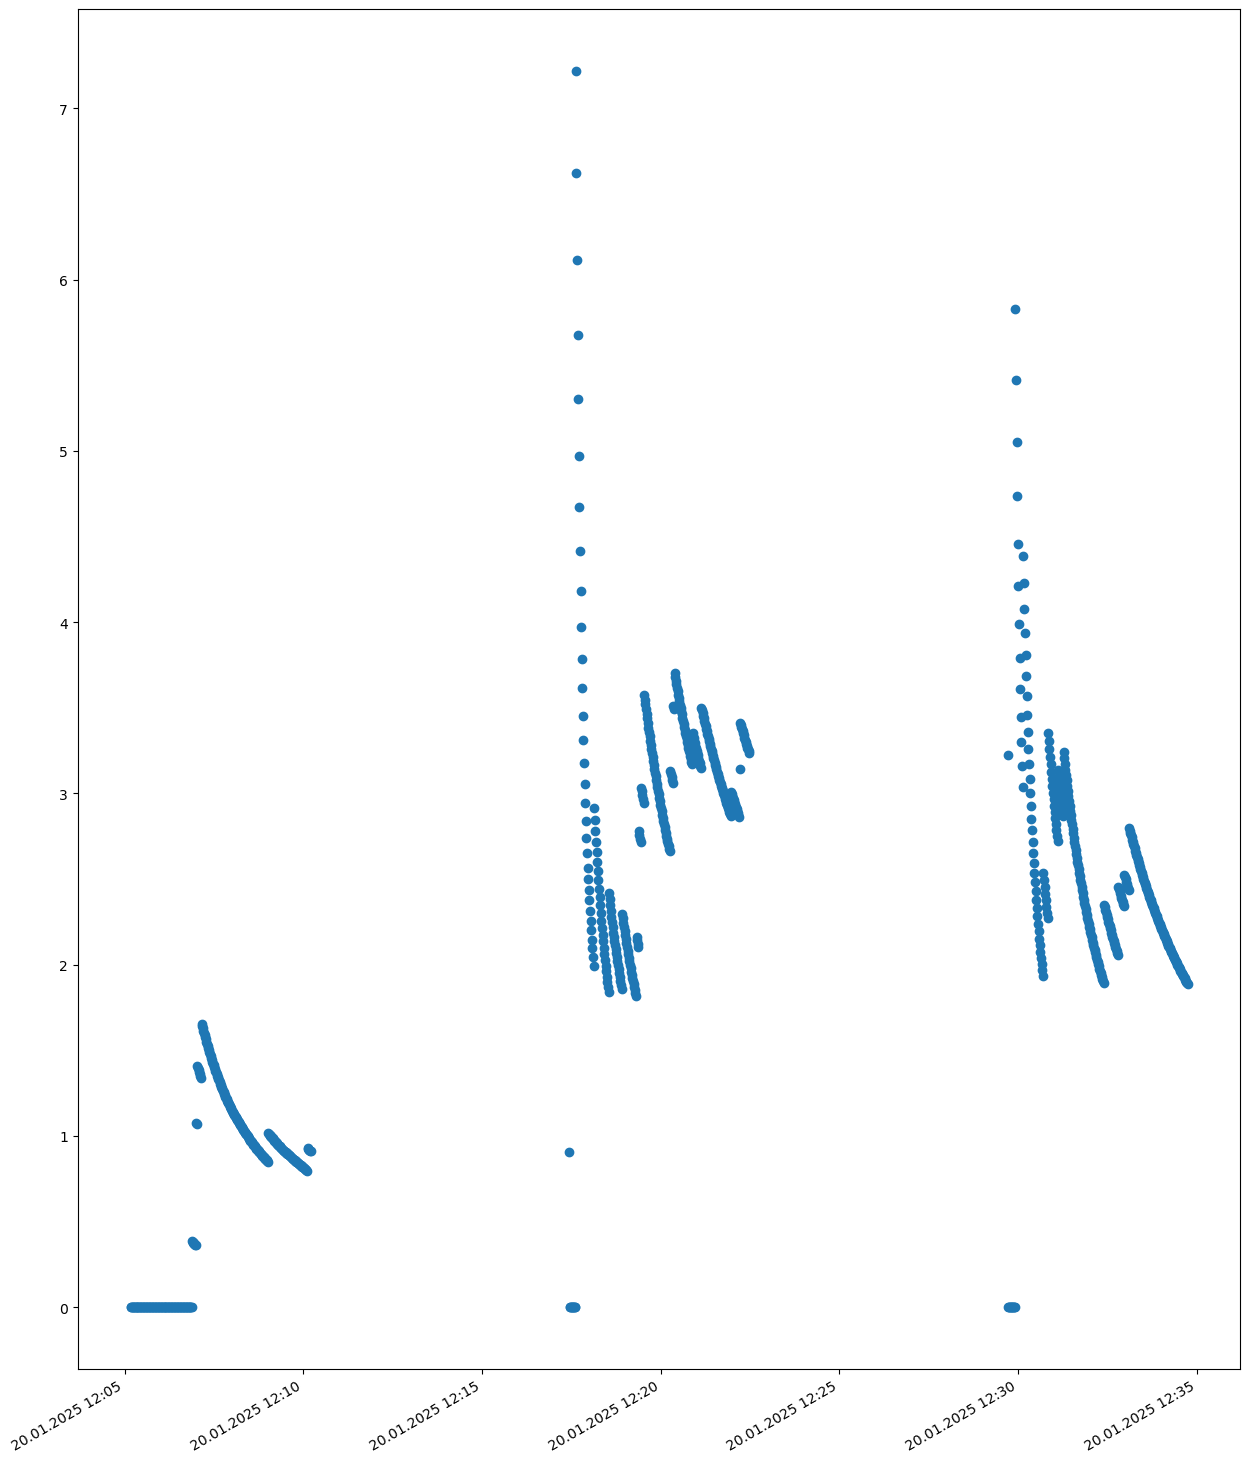

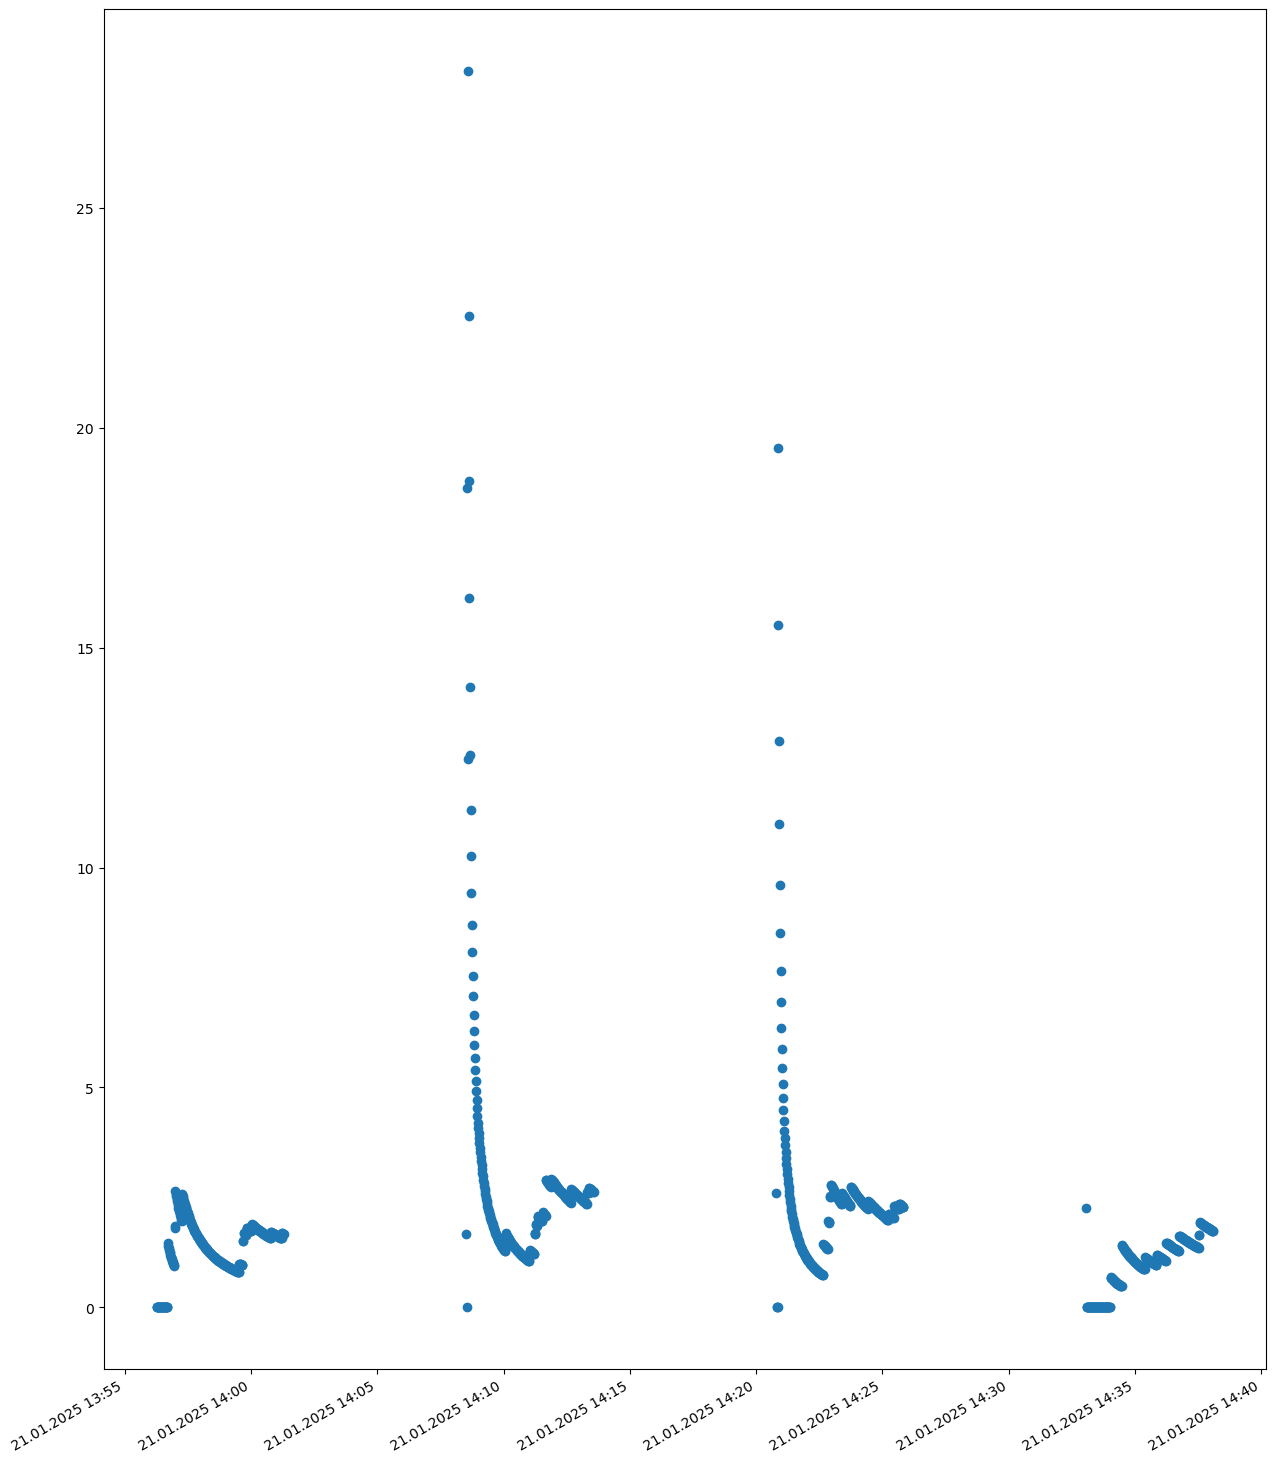

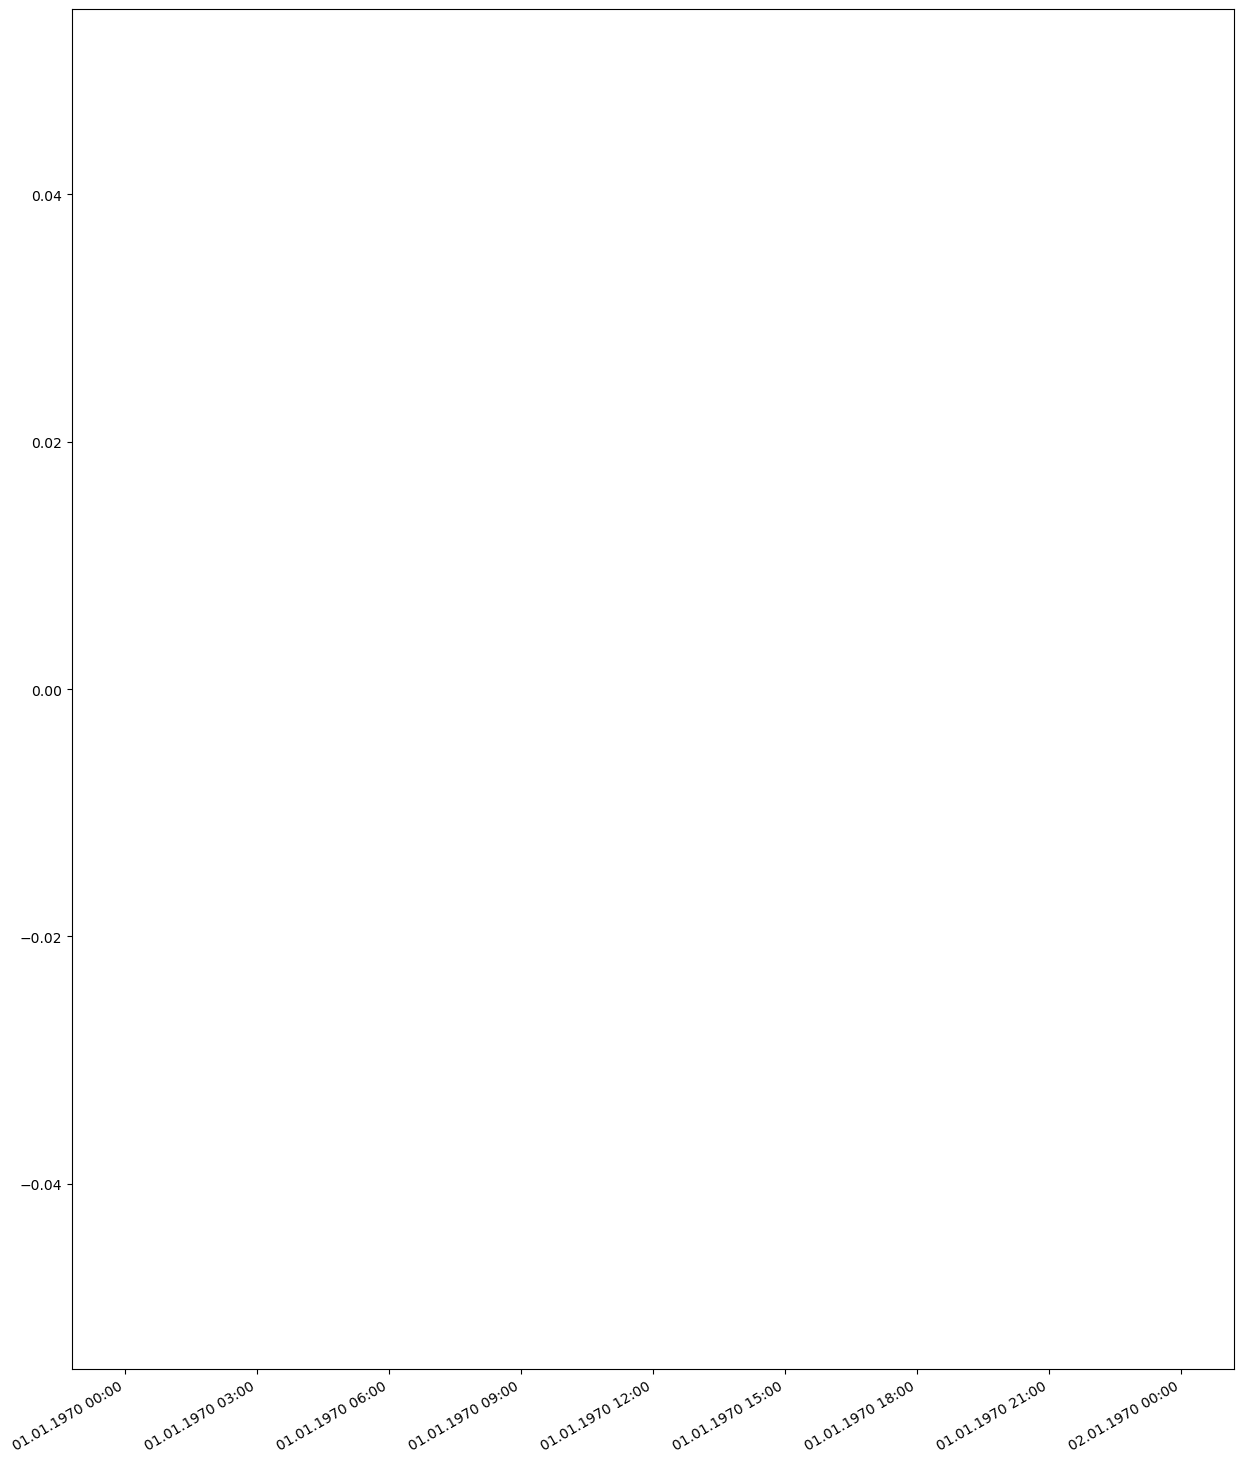

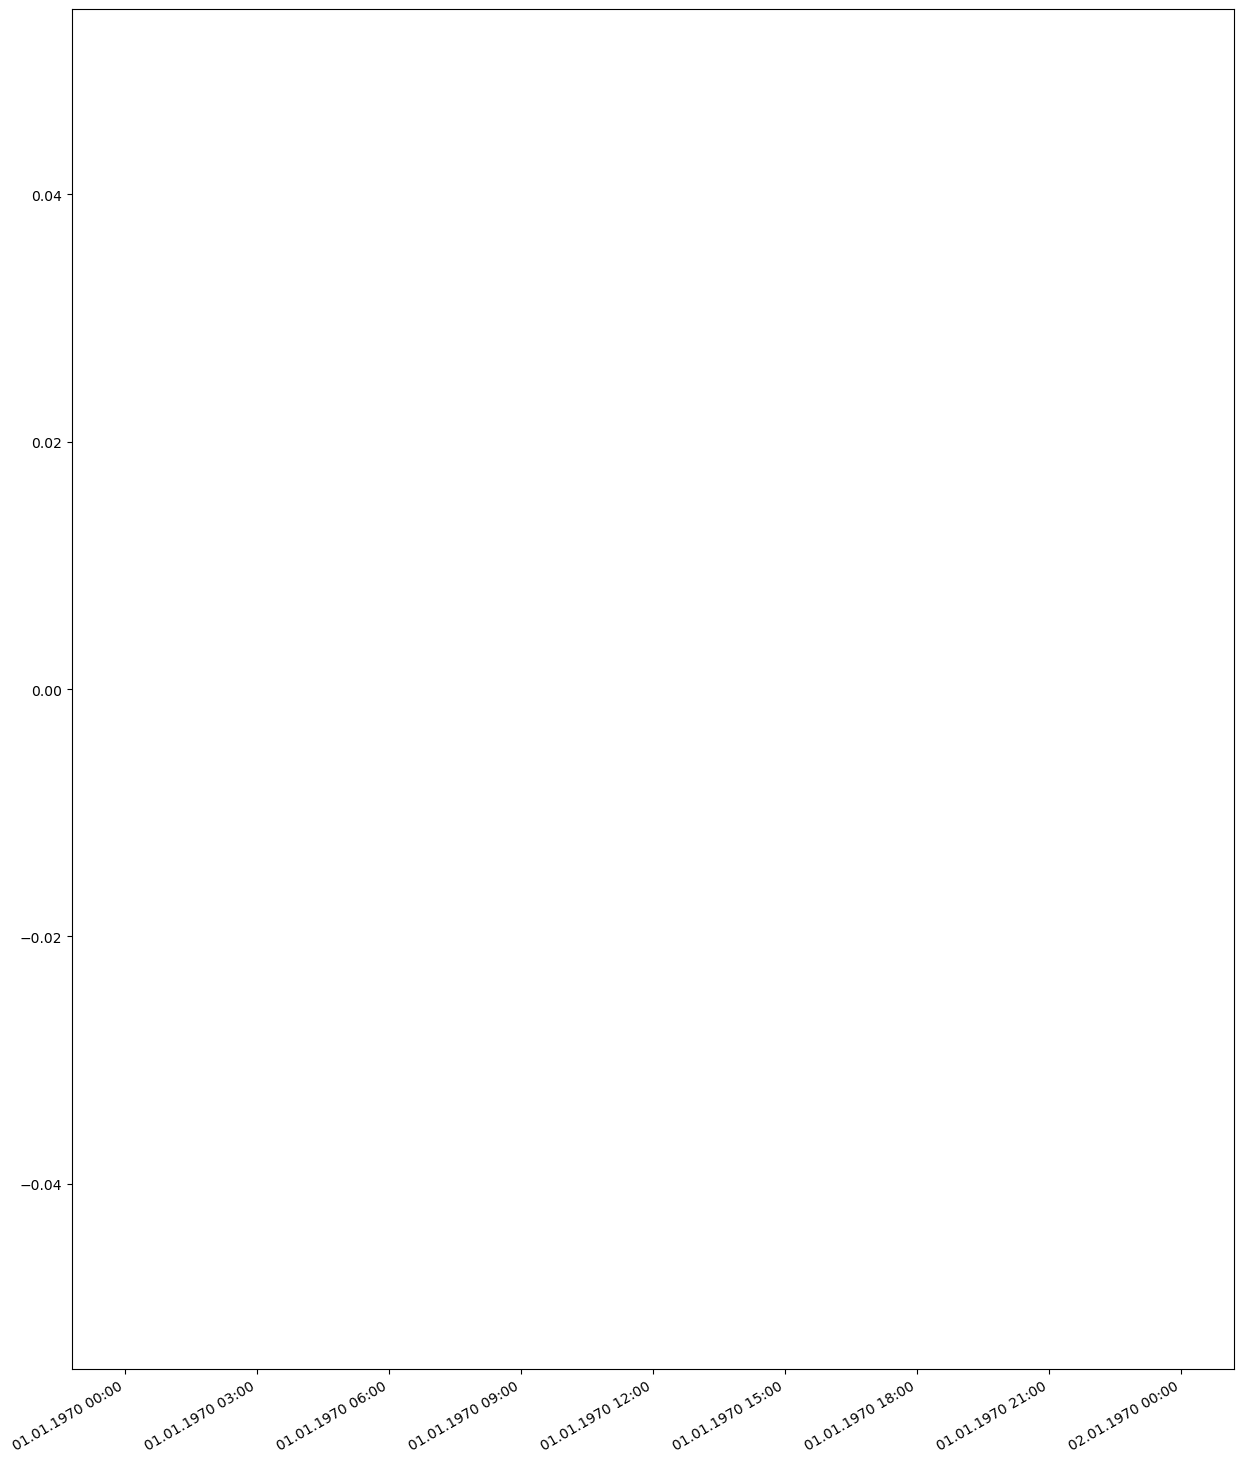

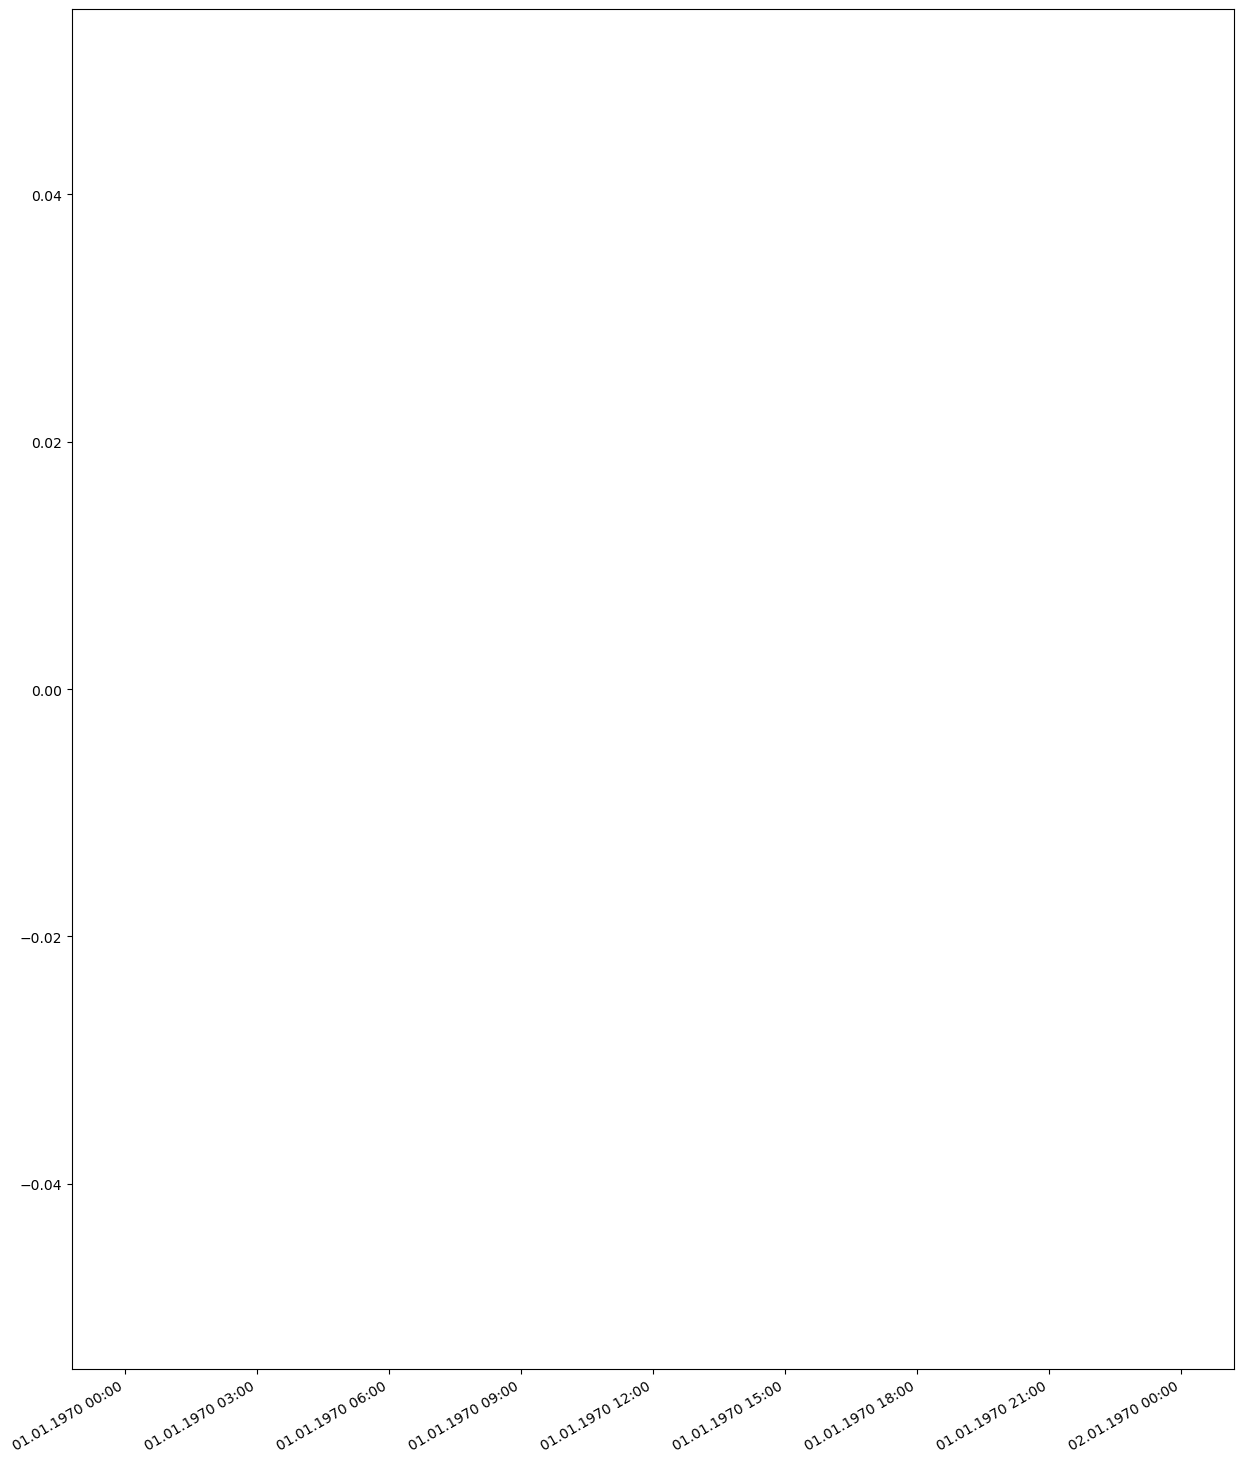

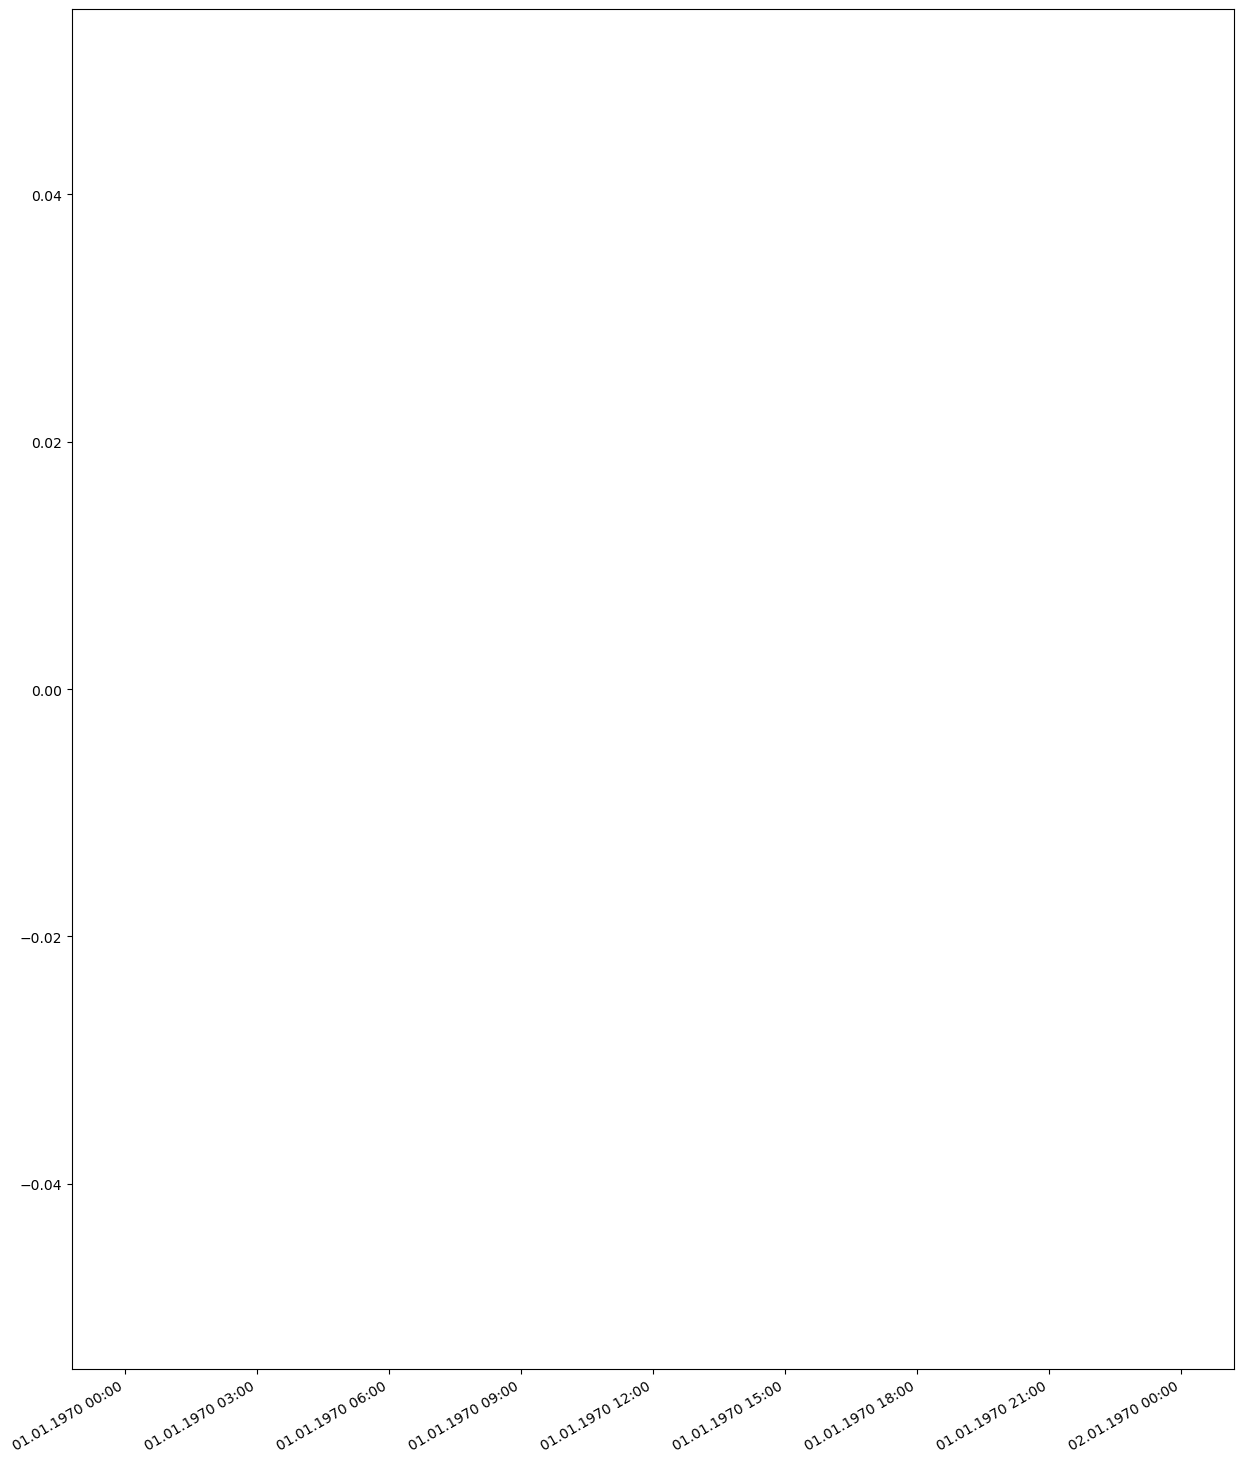

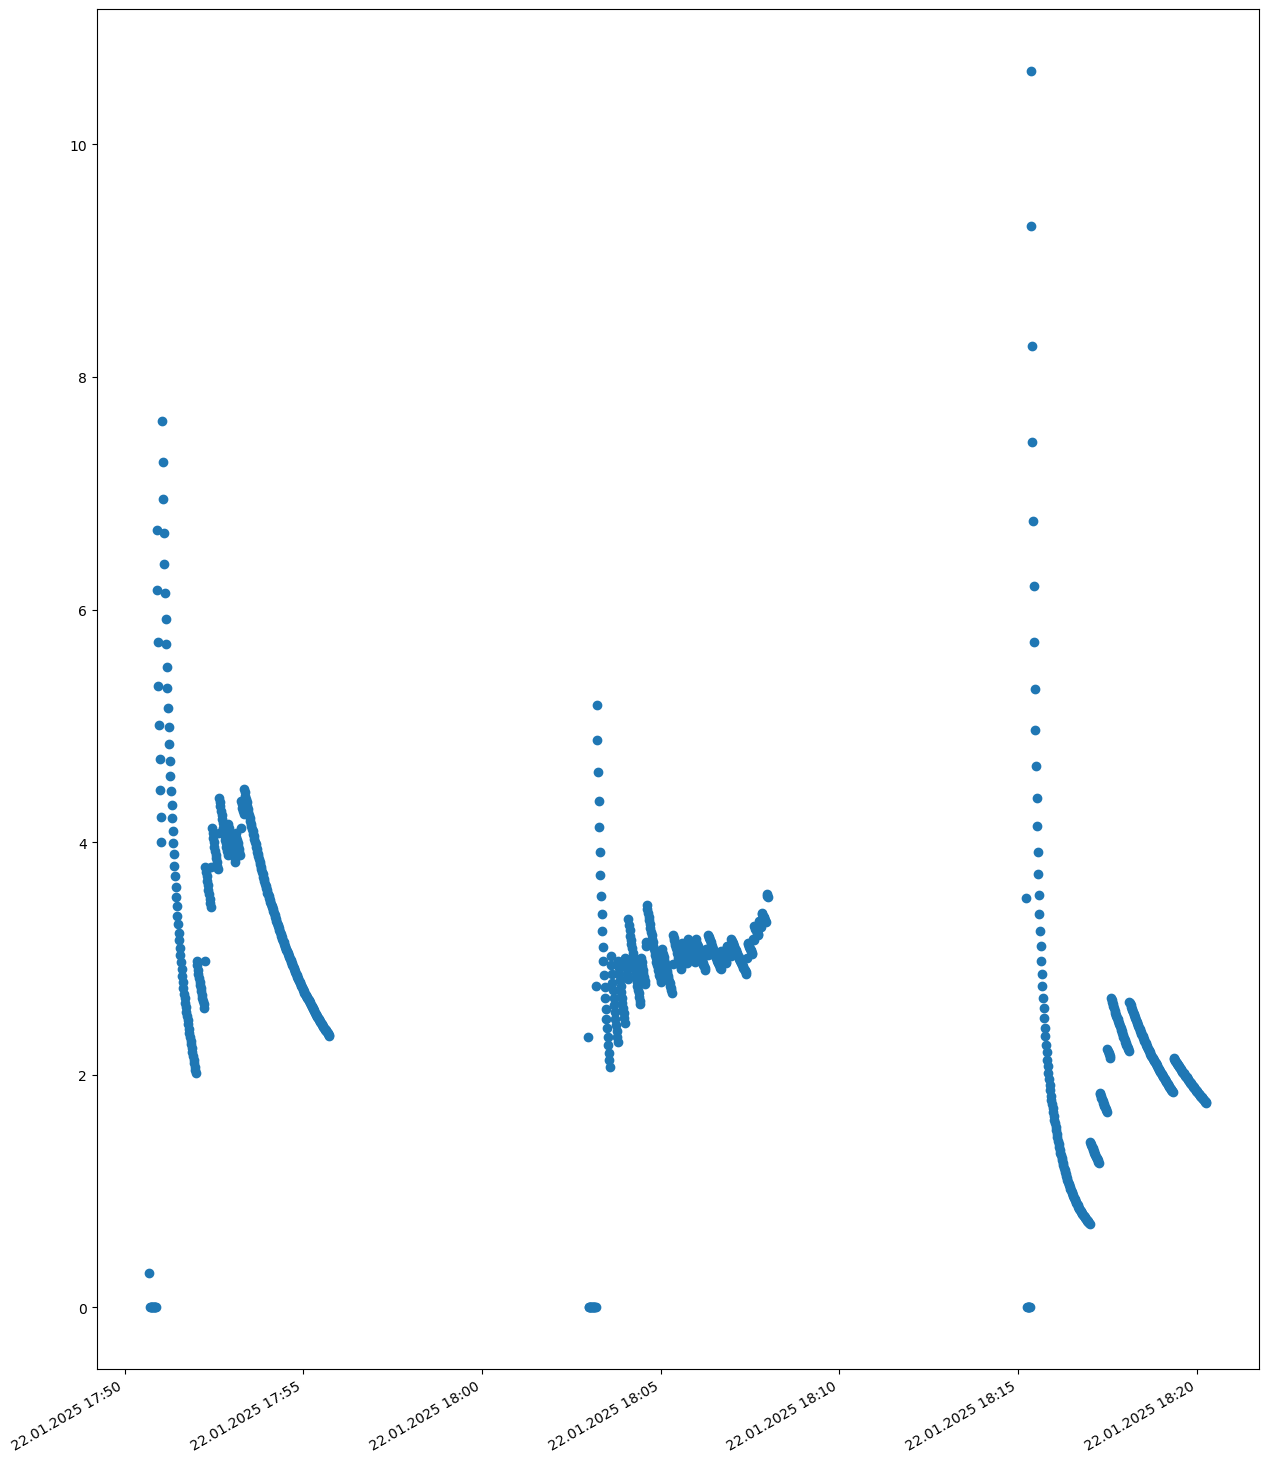

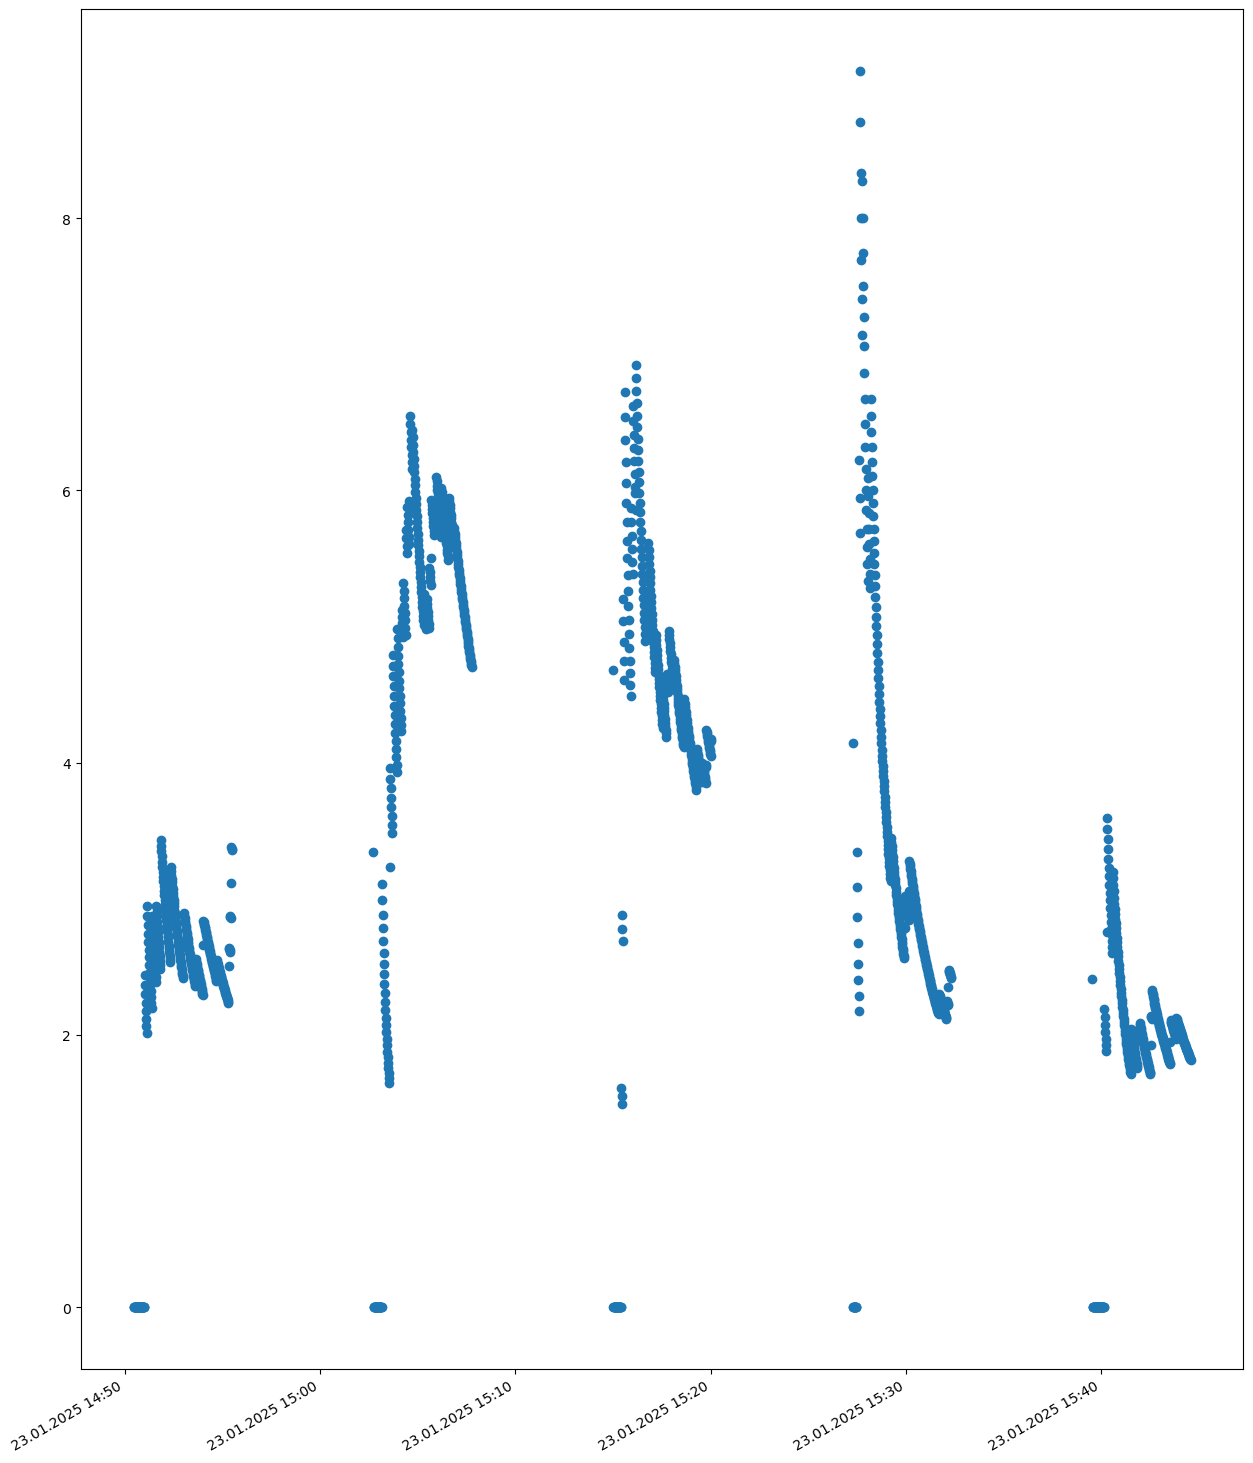

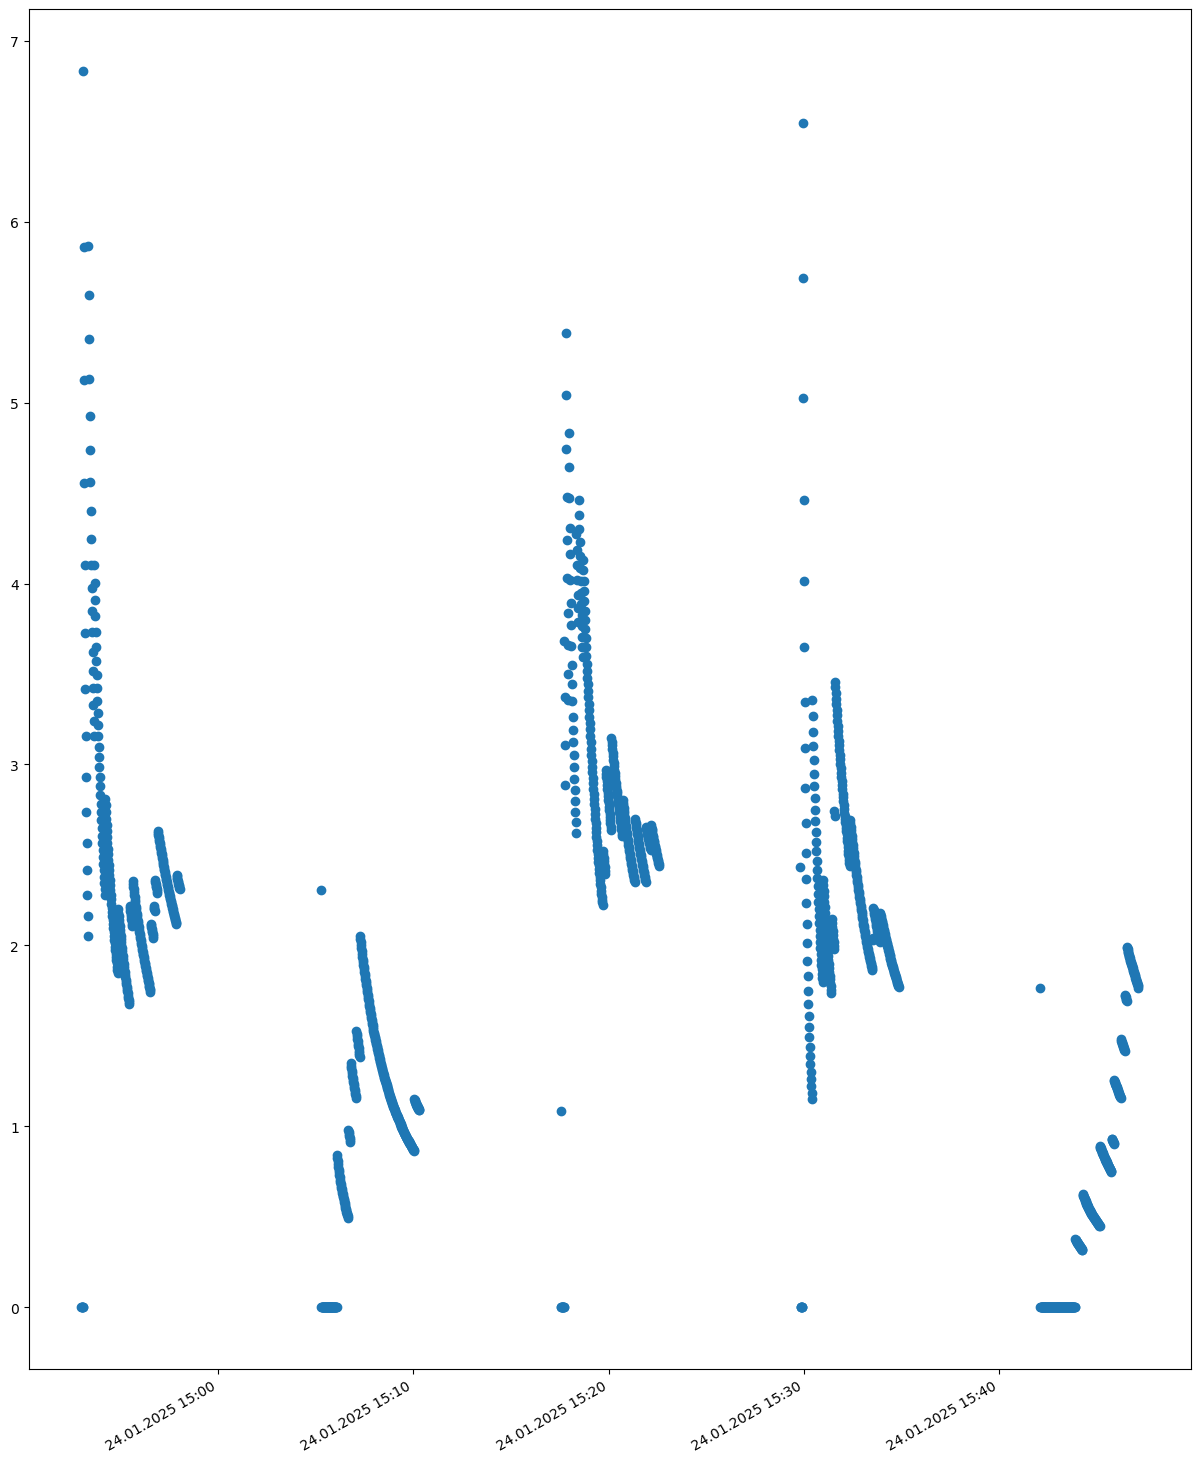

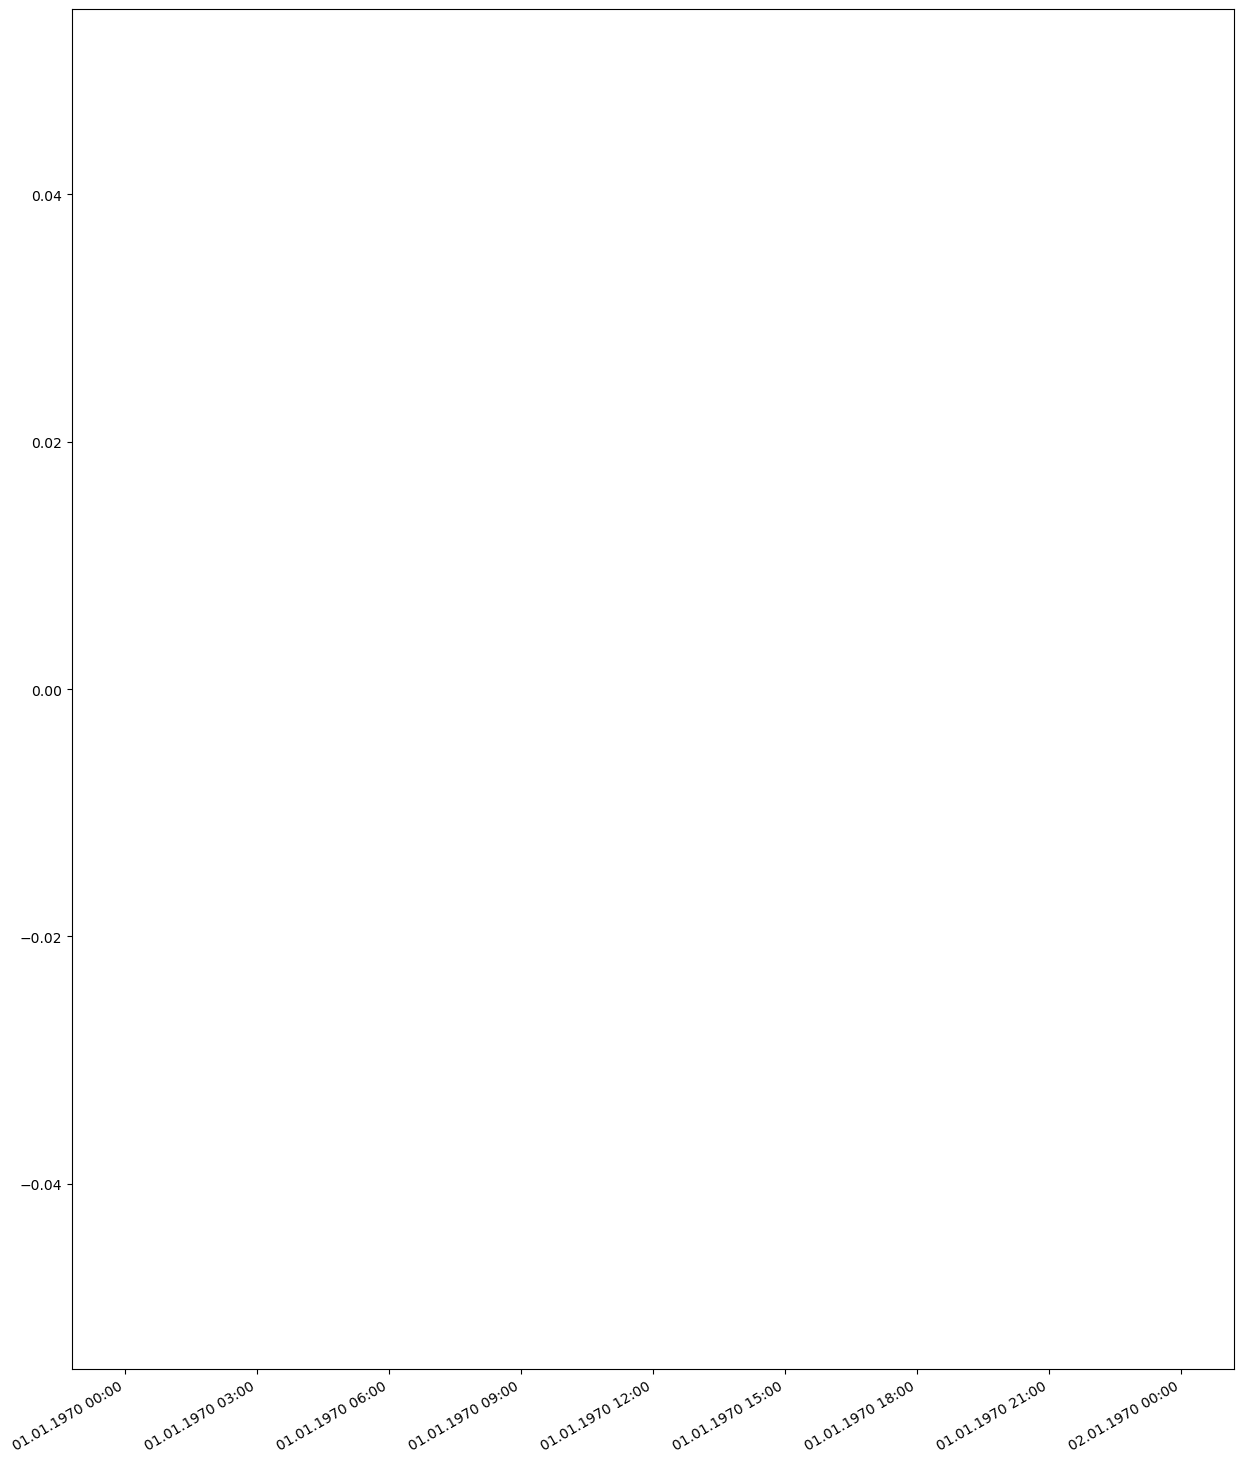

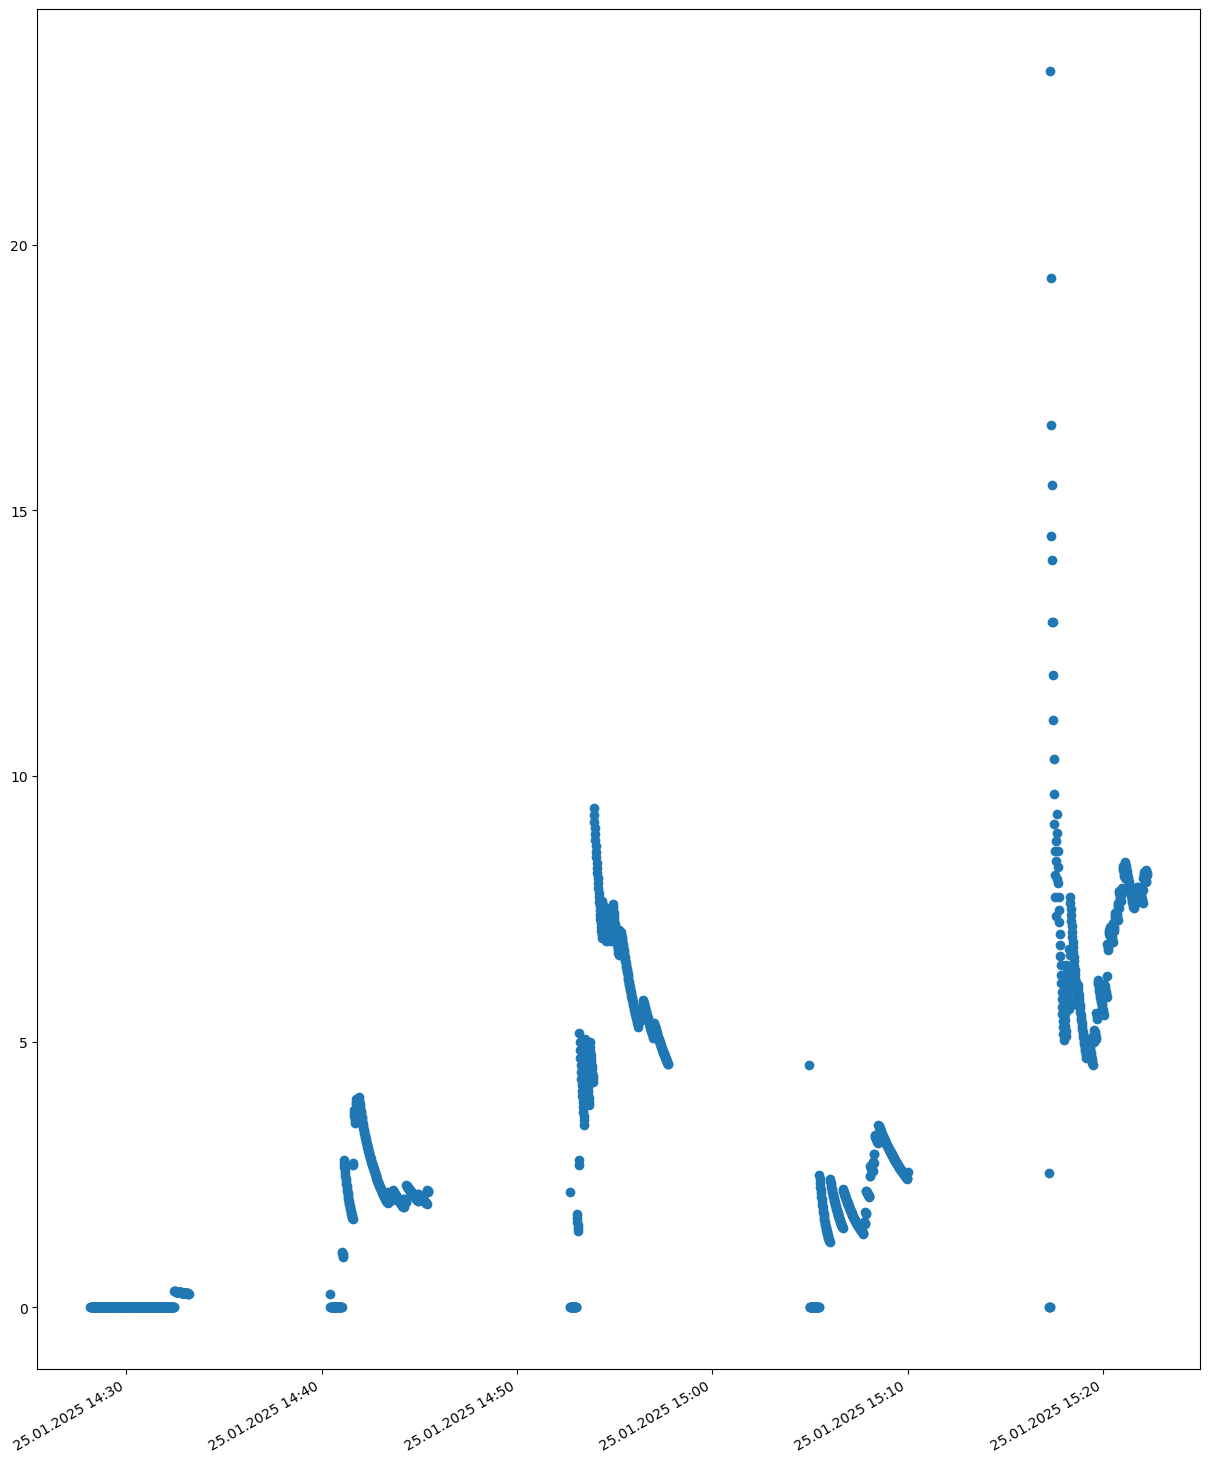

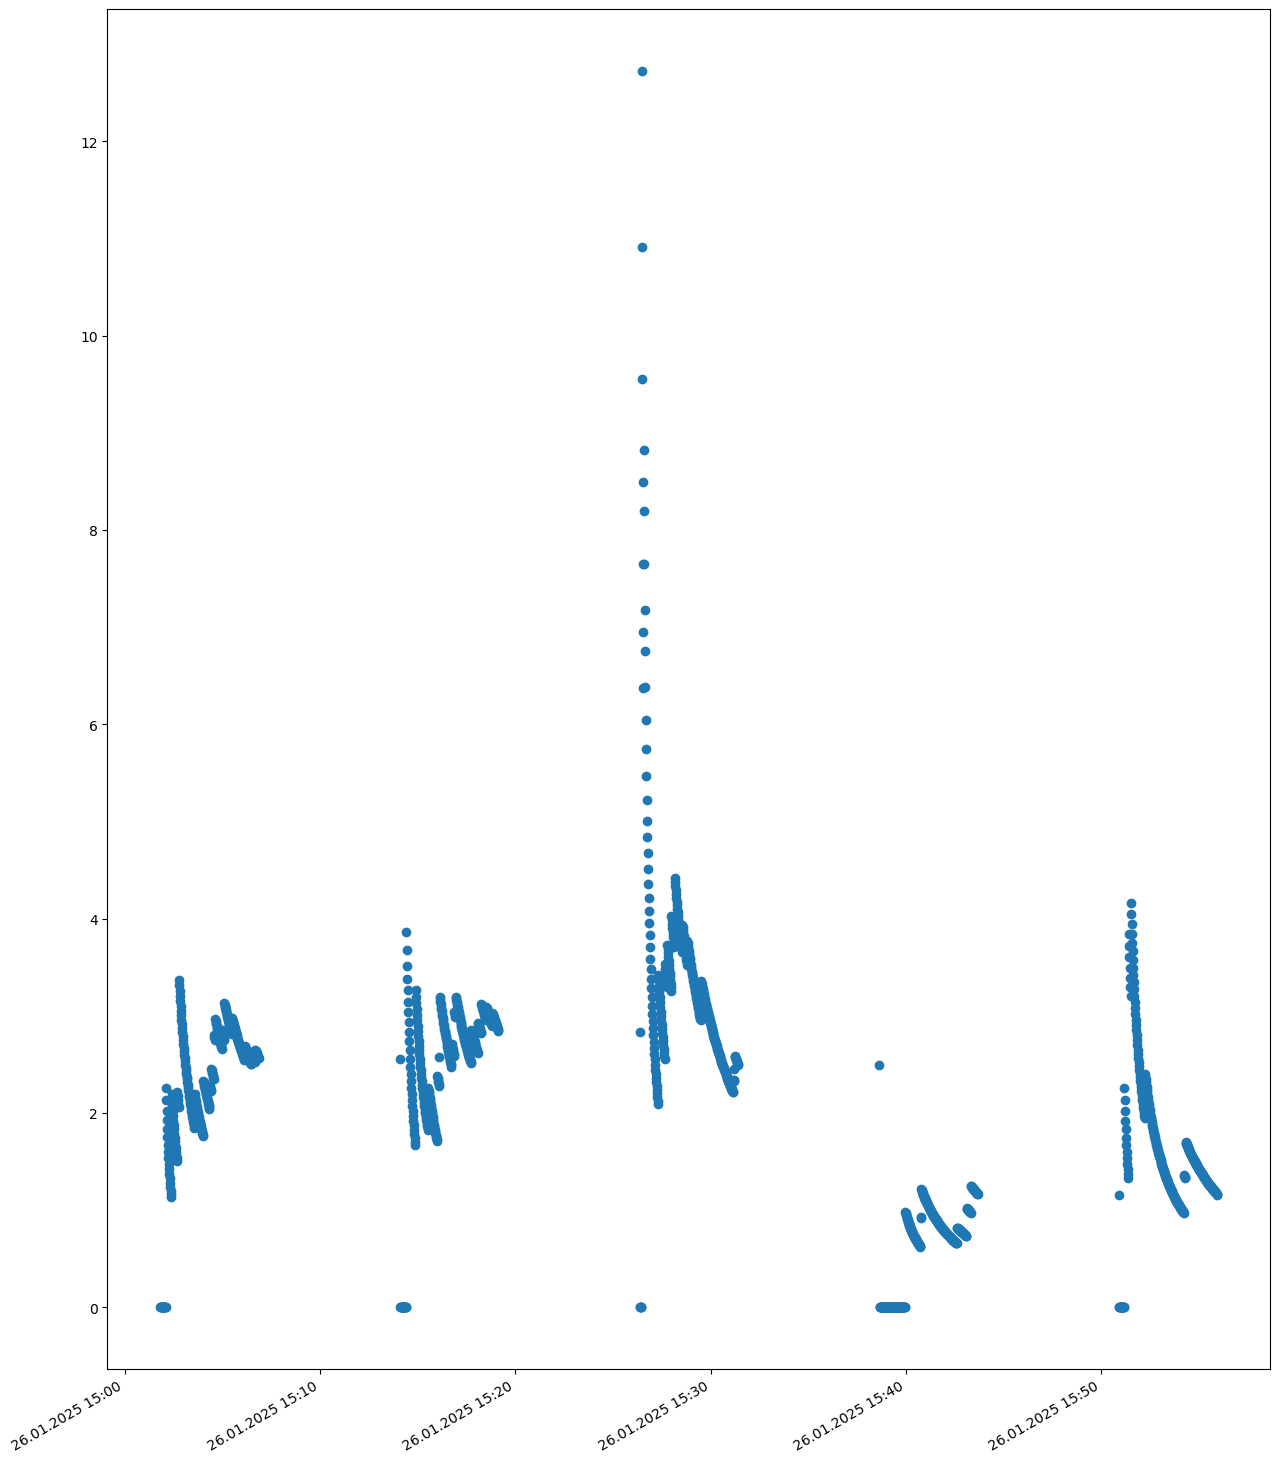

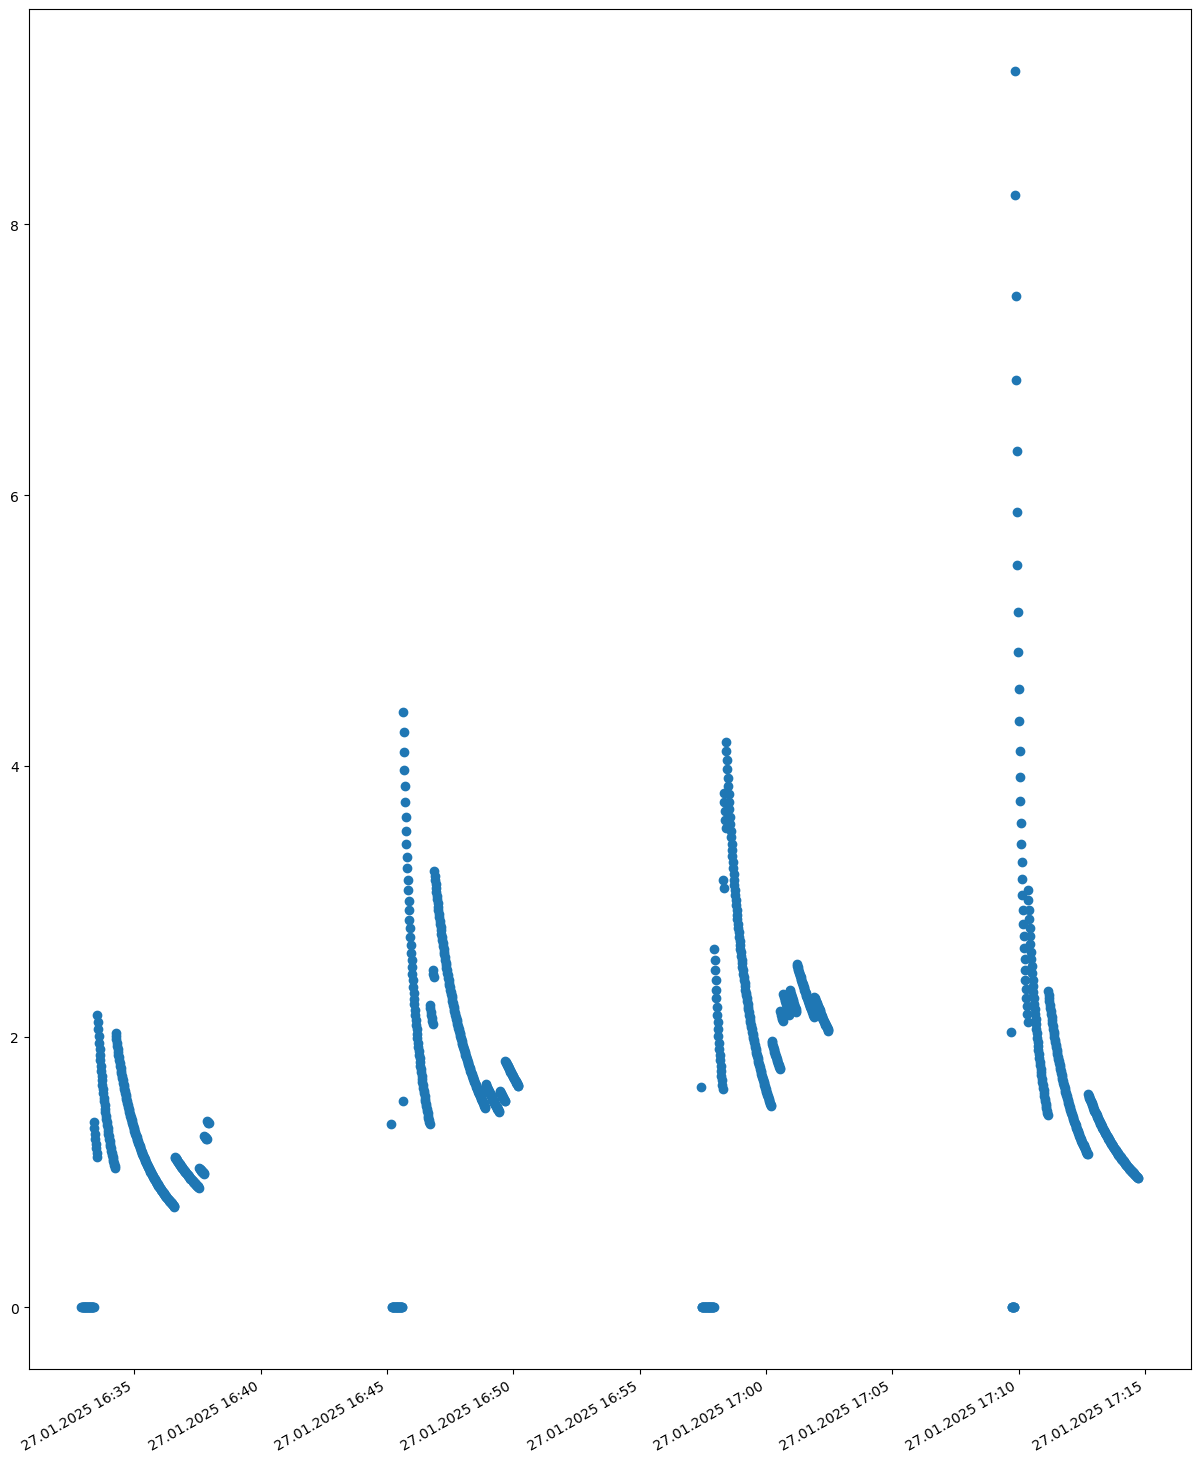

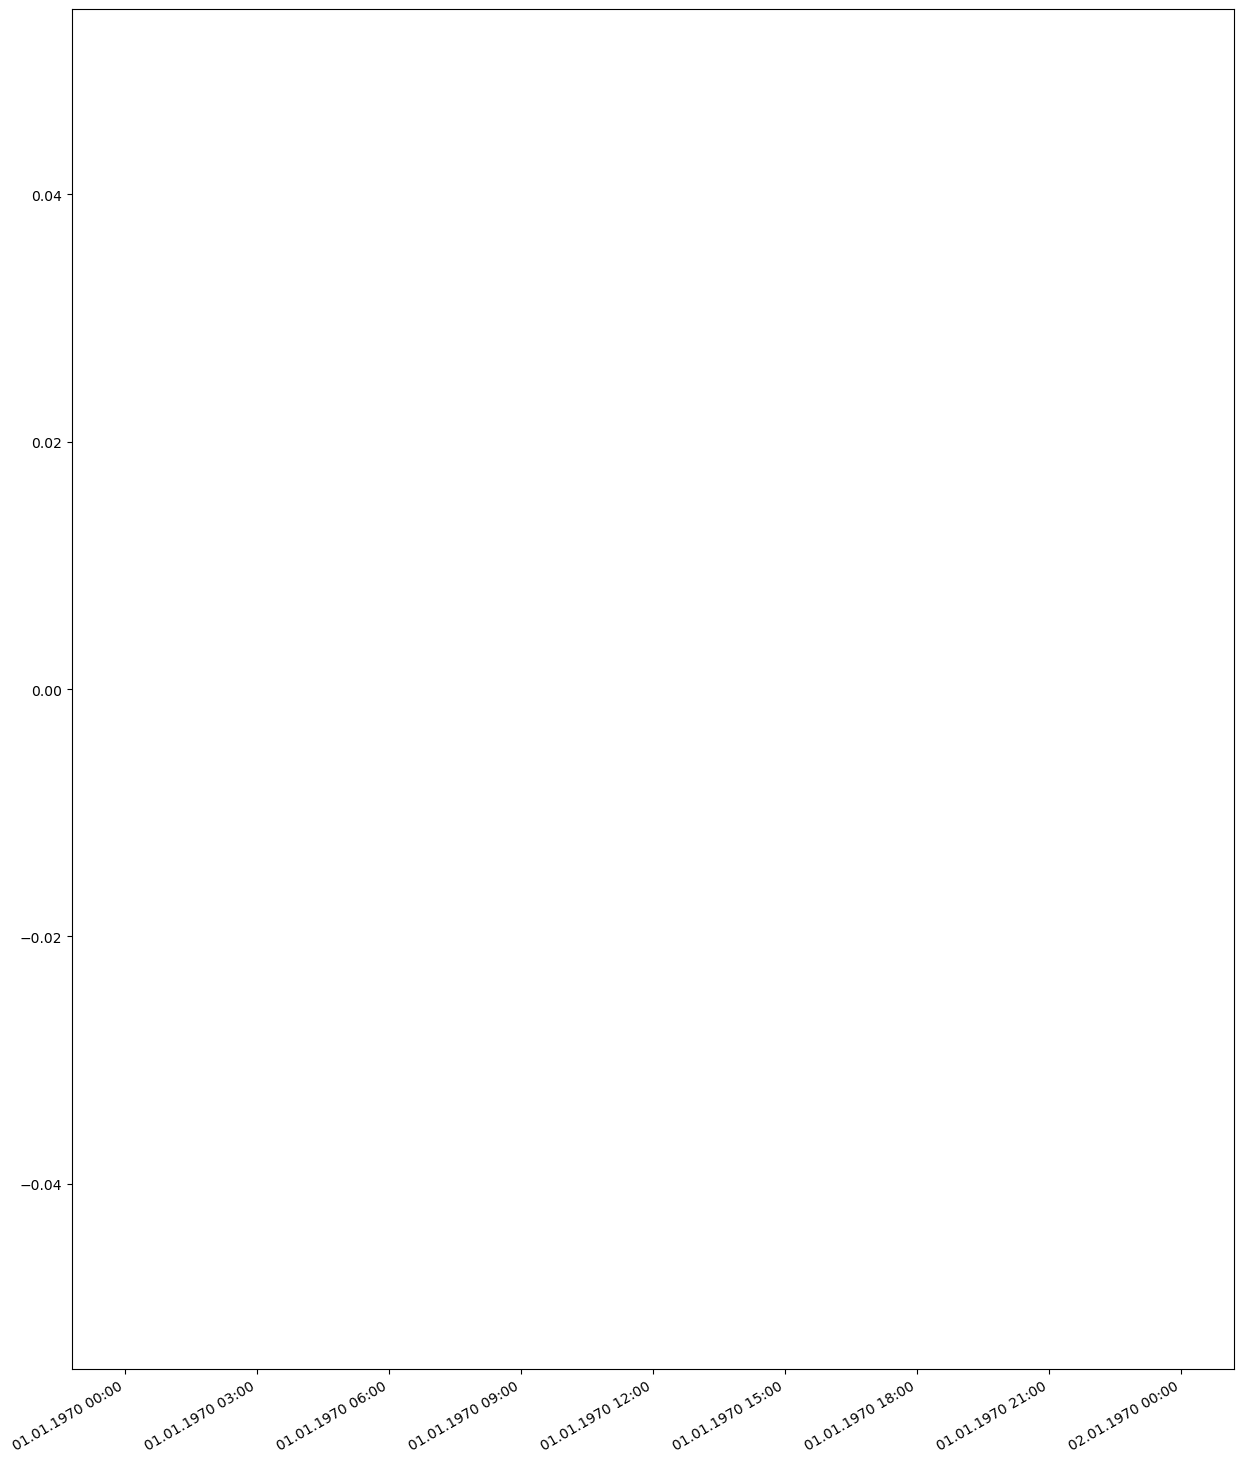

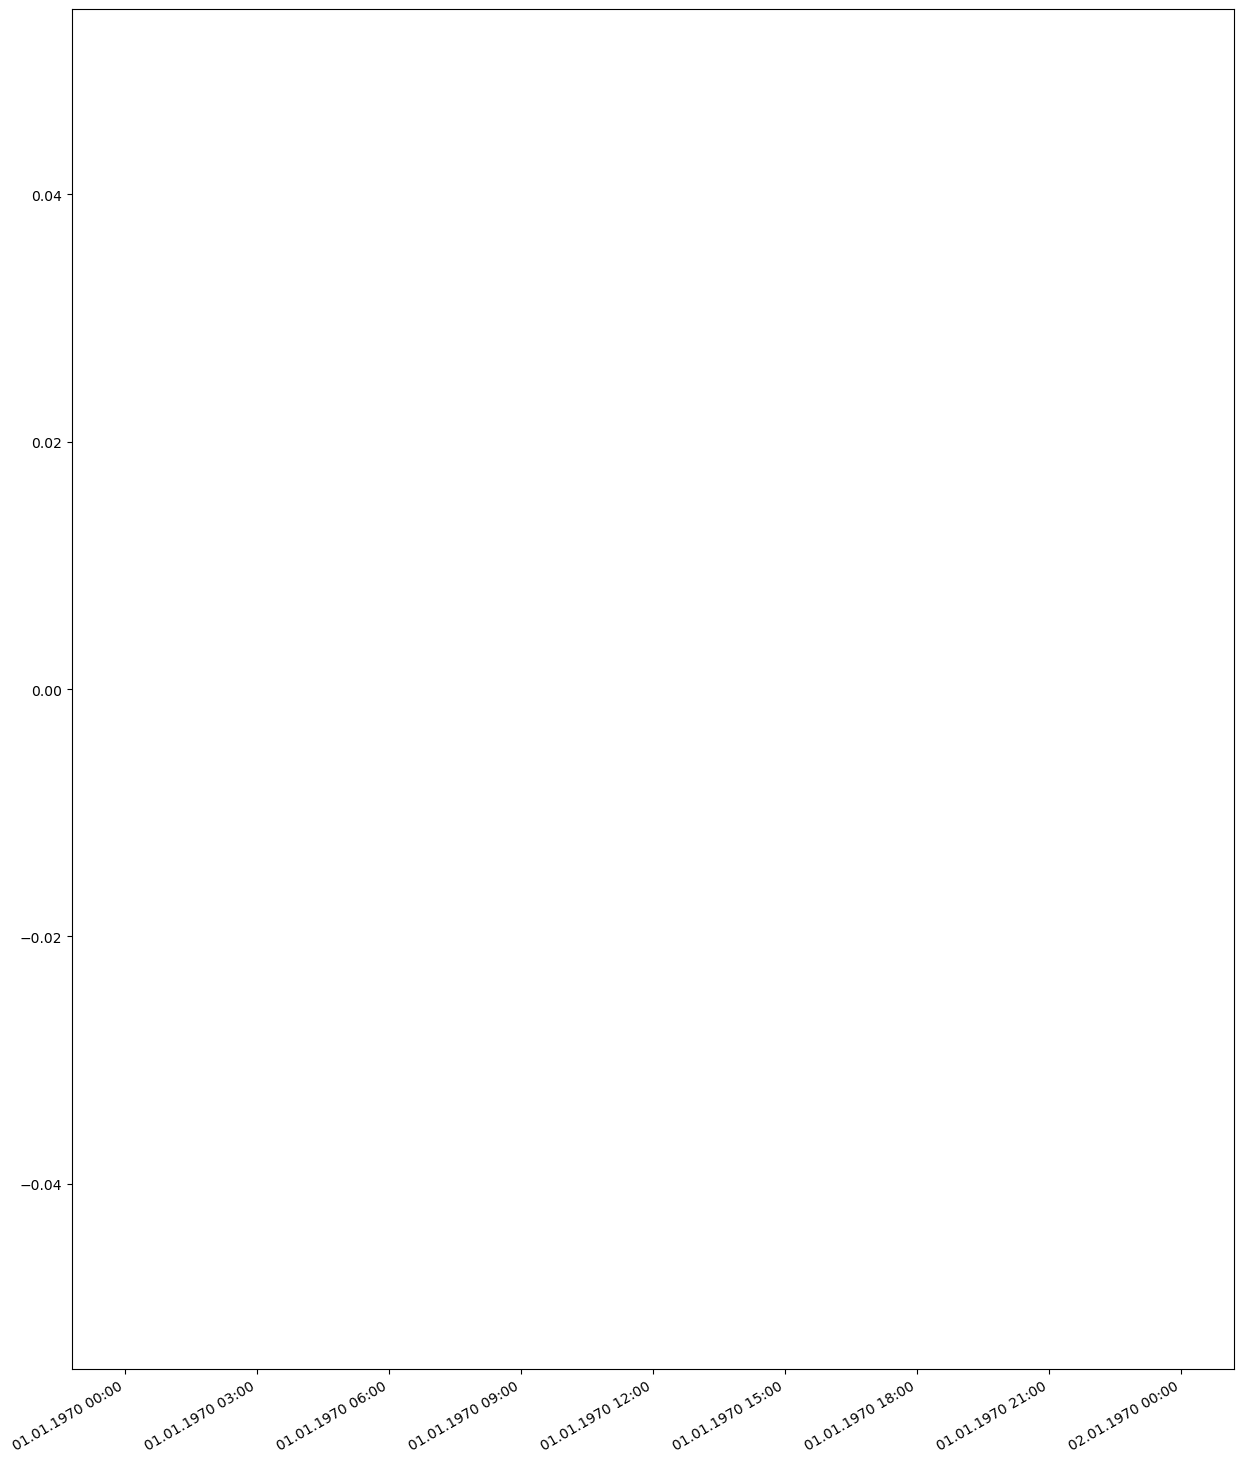

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

p = Path(r"D:\Coding\Data\Lanzhou_cfdc")
print(len(list(p.glob("data_202501*.csv"))))
for i, file in enumerate(p.glob("data_202501*.csv")):
    if i < 18:
        continue
    data = pd.read_csv(file).dropna(subset=['Lamina Average T [C]'])

    base_date = pd.to_datetime(file.stem.split('_')[1][0:8])
    dt = base_date + pd.to_timedelta(data['Time'], unit='s')

    x = dt
    bac_toggle = data['Background INP avg [#/L] Toggle']
    #sam_toggle = data['Sample INP avg [#/L] Toggle']
    y_bac_15 = data['Background INP avg [#/L]'][bac_toggle==True][data['Lamina T Set [C]']==-15.0].reindex(x.index, fill_value=np.nan) #后期改为其他温度
    #y_sam_15 = data['Sample INP avg [#/L]'][sam_toggle==True][data['Lamina T Set [C]']==-15.0].reindex(x.index, fill_value=np.nan) #后期改为其他温度

    fig = plt.figure(figsize=(15, 20))
    ax = fig.add_subplot(111)
    
    ax.scatter(x, y_bac_15)

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m.%Y %H:%M"))
    plt.gcf().autofmt_xdate()# 自动旋转日期标记

### 问题

发现第1.6.7.8.9.13.17.18张图都没有数据

    "D:\Coding\Data\Lanzhou_cfdc\data_20250117T215725.csv"
    "D:\Coding\Data\Lanzhou_cfdc\data_20250122T102430.csv"
    "D:\Coding\Data\Lanzhou_cfdc\data_20250122T123138.csv"
    "D:\Coding\Data\Lanzhou_cfdc\data_20250122T144757.csv"
    "D:\Coding\Data\Lanzhou_cfdc\data_20250122T145106.csv"
    "D:\Coding\Data\Lanzhou_cfdc\data_20250124T230134.csv"
    "D:\Coding\Data\Lanzhou_cfdc\data_20250128T112425.csv"
    "D:\Coding\Data\Lanzhou_cfdc\data_20250129T104239.csv"

1. 空数据应当删除

6. 空
7. 空
8. 空
9. 空

13. 空. 但奇怪的是, 气泵开着, INP计数器('Sample INP avg [#/L]'和'Background INP avg [#/L]'这两个变量)一直为0,
鉴于前面已有2025.01.24的数据, 因此删除这个, 保留另一个.

17. 空. 气泵一直关着的.
18. 同上

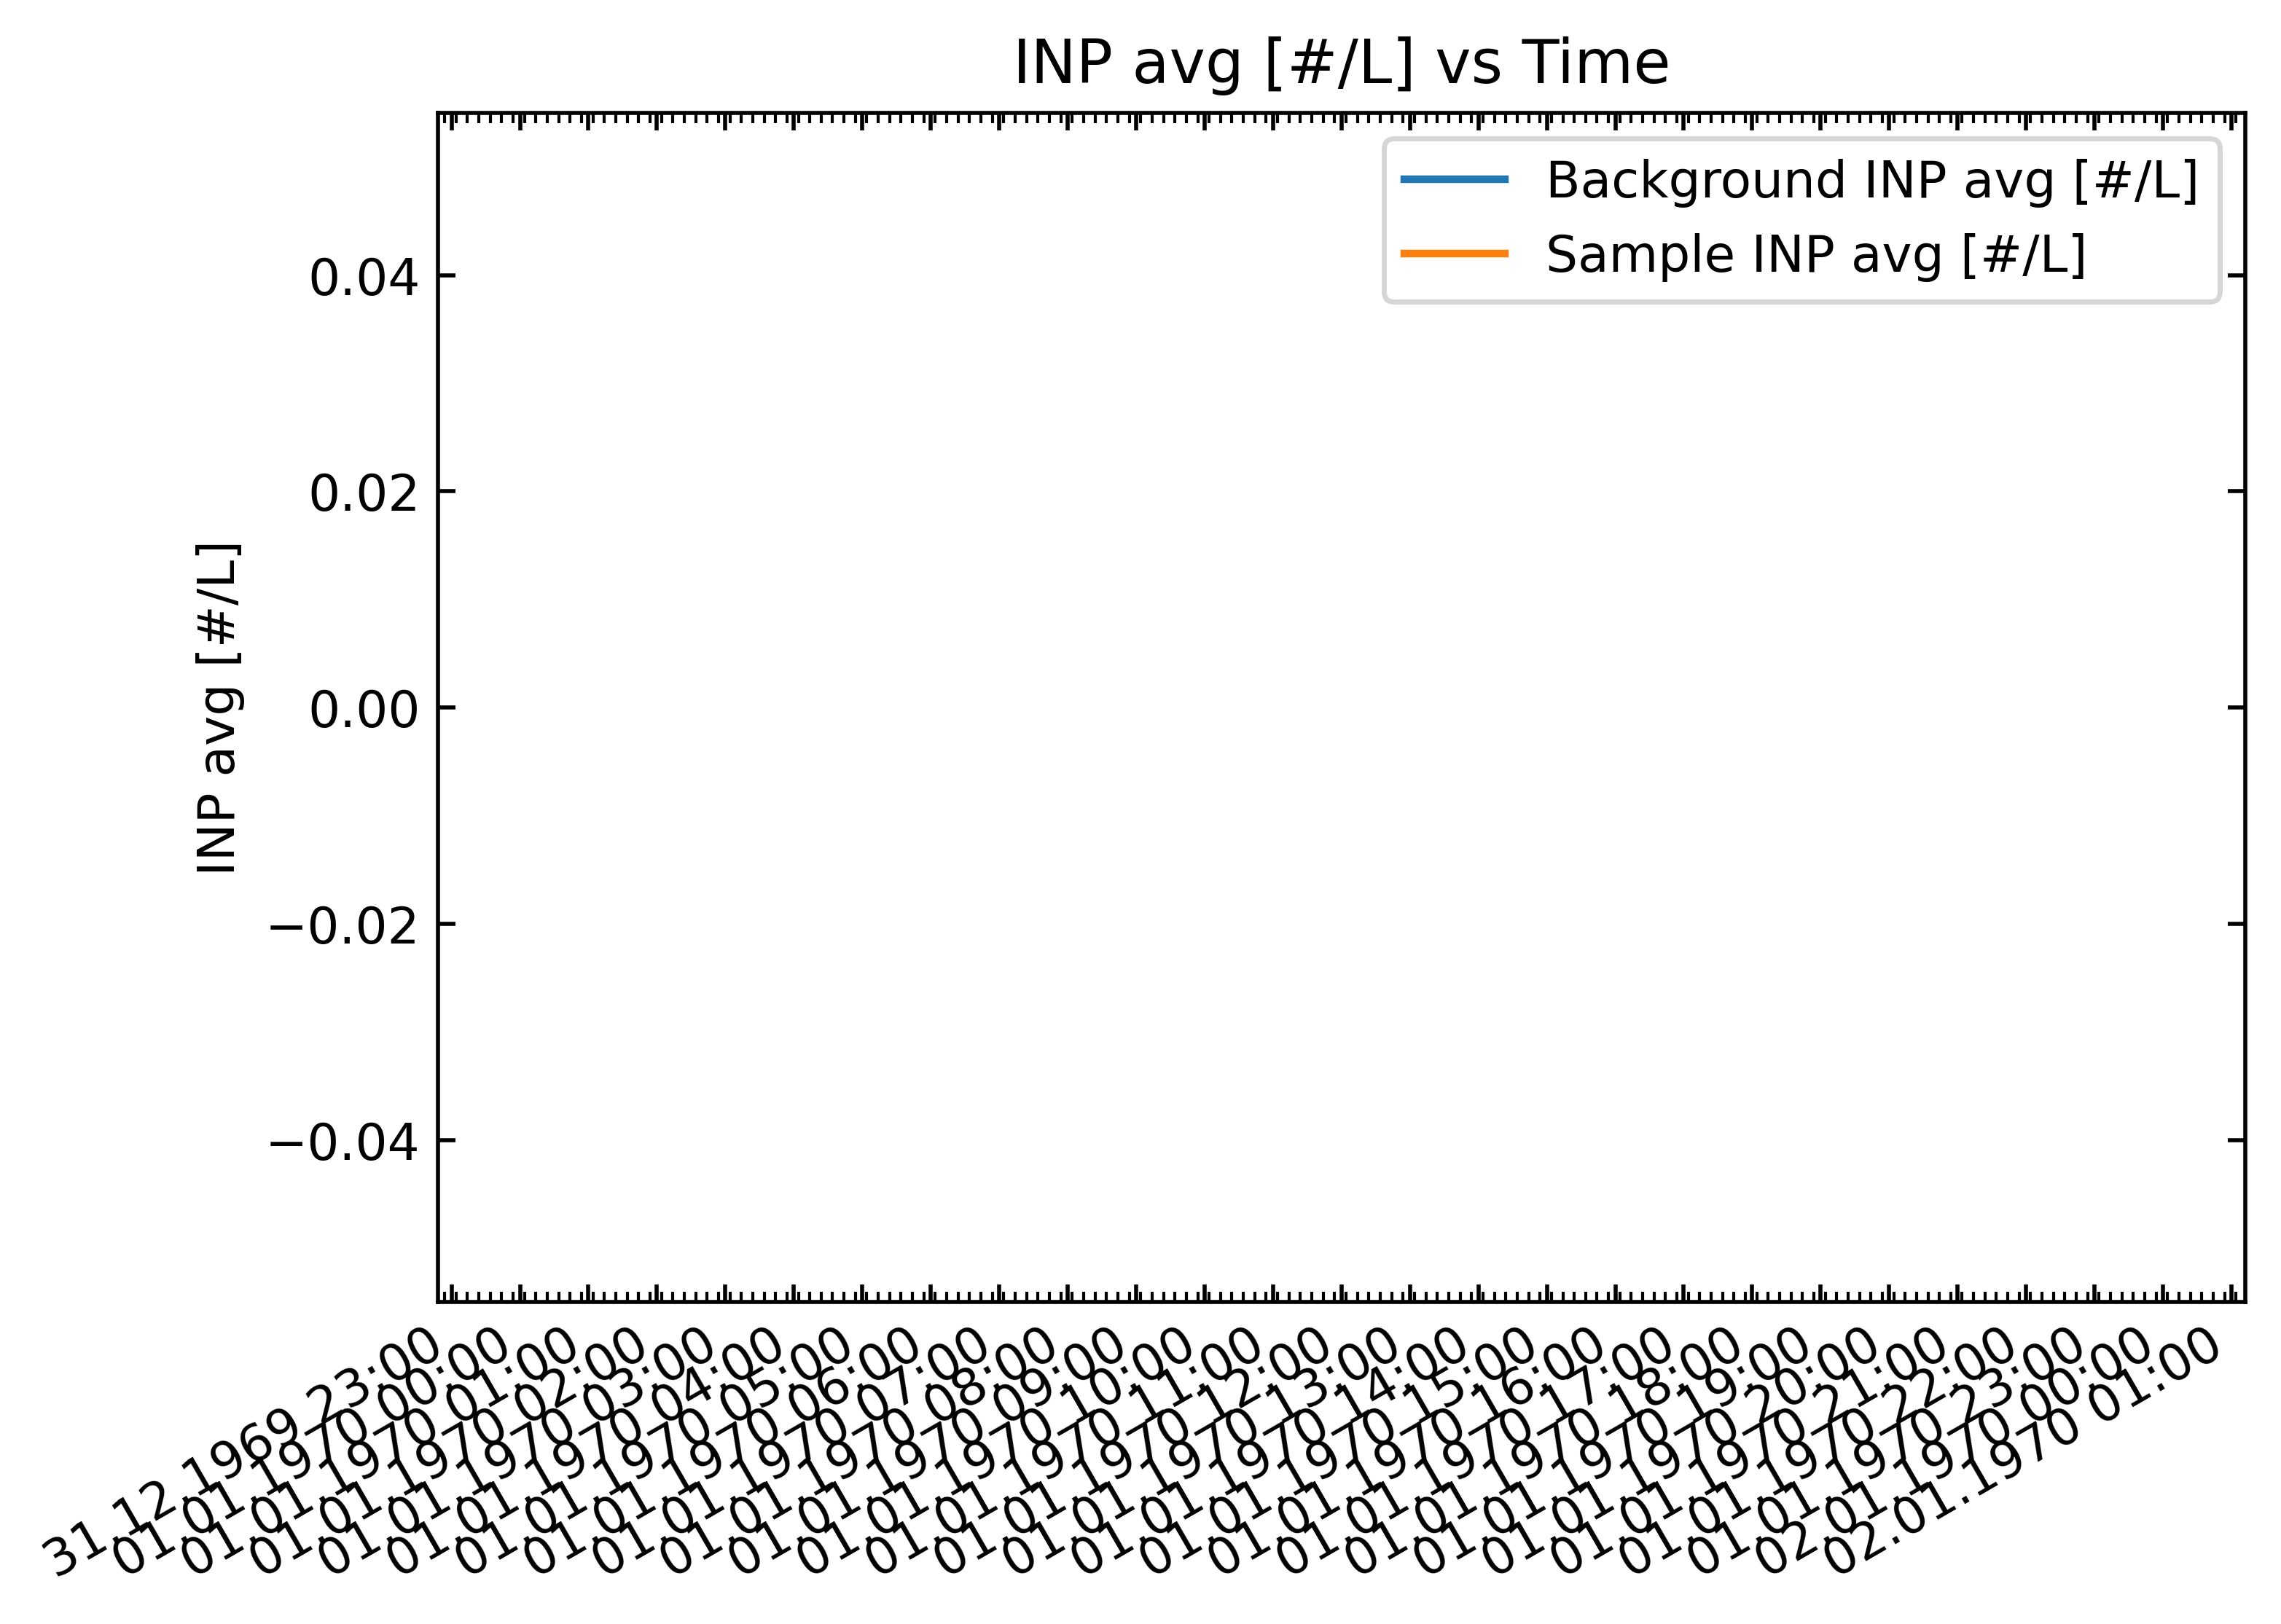

In [27]:
# 整合画出一天INP浓度的时间序列

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

#一天数据集处理
data = pd.read_csv(r"D:\Coding\Data\Lanzhou_cfdc\empty_data\data_20250129T104239.csv")
data = data.dropna(subset=['Lamina Average T [C]'])

#根据文件名确定当天日期
base_date = pd.to_datetime("2025-01-29")

dt = base_date + pd.to_timedelta(data['Time'], unit='s')

x = dt
diff = data['Lamina Average T [C]'] - data['Lamina T Set [C]']
background_toggle = data['Background INP avg [#/L] Toggle']
sample_toggle = data['Sample INP avg [#/L] Toggle']
y1 = data['Background INP avg [#/L]'][background_toggle==True][abs(diff) <= 0.6].reindex(x.index, fill_value=np.nan)
y2 = data['Sample INP avg [#/L]'][sample_toggle==True][abs(diff) <= 0.6].reindex(x.index, fill_value=np.nan)

fig = plt.figure(dpi=500)
ax = fig.add_subplot(111)

ax.plot(x, y1, label='Background INP avg [#/L]')
ax.plot(x, y2, label='Sample INP avg [#/L]')

ax.xaxis.set_major_locator(mdates.HourLocator(interval=1)) # 每小时一个主刻度
ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=10)) # 每10分钟一个次刻度
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m.%Y %H:%M"))
plt.gcf().autofmt_xdate()# 自动旋转日期标记
ax.set_ylabel('INP avg [#/L]')
ax.tick_params(which='both', top=True, bottom=True, left=True, right=True, direction='in')
ax.set_title('INP avg [#/L] vs Time')
ax.legend()

## 总结

2025.01 数据已全部整理完成, 删除了空文件和重复文件.